## [SETUP] Install & Import Libraries

In [1]:
import pandas as pd
df = pd.read_csv('/Volumes/Sarbajit/Personal/Amir Sohel Sir/code/data.csv')
print('Shape:', df.shape)
print('\nReviewer Name unique values:')
print(df['Reviewer Name'].unique())
print('\nPrimary DL Architecture unique values:')
print(df['Primary DL Architecture'].unique())
print('\nReal-Time Capability Claimed? unique values:')
print(df['Real-Time Capability Claimed?'].unique())
print('\nXAI Sufficiently Evaluated unique values:')
print(df['XAI Sufficiently Evaluated'].unique())
print('\nReproducibility unique values:')
print(df['Reproducibility'].unique())
print('\nYear of Publication unique values:')
print(sorted(df['Year of Publication'].dropna().unique()))

Shape: (112, 93)

Reviewer Name unique values:
['Sarbajit Paul Bappy' 'Consensus']

Primary DL Architecture unique values:
['Not applicable.\n\nNo deep learning model was developed.\n\nStudy focused on multimodal synchronization indicators.'
 'CDLLNet (Cauchy Distribution Label Learning Network)'
 'Multilayer Perceptron (MLP) / Artificial Neural Network (ANN).'
 'CNN / RNN / LSTM / Bi-LSTM / GRU / CNN-LSTM / CNN-GRU / Transformer / ViT / Hybrid -> Other: ANN / MLP (Multilayer Perceptron)'
 'RNN / LSTM / BiLSTM.' 'CNN' 'CNN / Hybrid (MobileNet + Attention)'
 'CNN-based EEGNet'
 'Hybrid multimodal architecture:\n\n2D-CNN\n3D-CNN\nCross-modal fusion networks'
 'Hybrid (2D-CNN for Audio, 3D-CNN for Video)\n' 'Hybrid InceptionV3'
 'Hybrid (CNN-ELM)' 'Hybrid CNN-TCN with Attention' 'CNN-LSTM Hybrid'
 'Hybrid (CNN + Exemplar-based Clustering/Transfer Learning)'
 'CNN (Combined with Haar Cascade Classifier)'
 'CNN (Dense-connectivity / DenseNet variant)' 'CNN\n'
 'Two architectures were invest

## CELL 1 — [SETUP] Install & Import Libraries

In [2]:
# [SETUP] Install & Import Libraries

# %pip install pandas numpy matplotlib seaborn plotly wordcloud kaleido -q


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS
import warnings
import os

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────
DATA_PATH    = '/Volumes/Sarbajit/Personal/Amir Sohel Sir/code/data.csv'
FIGURES_PATH = '/Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final'
os.makedirs(FIGURES_PATH, exist_ok=True)

# ── Global style ───────────────────────────────────────────────────────
ARCH_COLORS = {
    'CNN/Hybrid'  : '#4FD1C5',   # teal
    'RNN/LSTM'    : '#F6AD55',   # gold
    'Transformer' : '#667EEA',   # indigo
    'Other/NA'    : '#A0AEC0',   # slate
}

DPI = 1200
FONT_FAMILY = 'DejaVu Sans'

plt.rcParams.update({
    'font.family'      : FONT_FAMILY,
    'figure.dpi'       : 150,       # screen preview
    'savefig.dpi'      : DPI,       # final export
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
})

print("✅ Setup complete. Output folder:", FIGURES_PATH)

✅ Setup complete. Output folder: /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final


## CELL 2 — [LOAD] Read Raw CSV


In [3]:
# [LOAD] Read Raw CSV

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')

print(f"Raw shape : {df_raw.shape}")
print(f"Columns   : {df_raw.shape[1]}")
print(f"\nReviewer breakdown:")
print(df_raw['Reviewer Name'].value_counts())
print(f"\nFirst 3 Study IDs:")
print(df_raw['Study ID'].head(3).tolist())

Raw shape : (112, 93)
Columns   : 93

Reviewer breakdown:
Reviewer Name
Sarbajit Paul Bappy    56
Consensus              56
Name: count, dtype: int64

First 3 Study IDs:
['Hayashi 2024', 'Hayashi 2024', 'Liu 2021']


## CELL 3 — [AUDIT] Inspect Dirty Columns


In [4]:
# [AUDIT] Inspect Dirty Columns — run before any cleaning

audit_cols = [
    'Primary DL Architecture',
    'Real-Time Capability Claimed?',
    'Inference Speed / Latency Reported?',
    'XAI Implemented?',
    'XAI Sufficiently Evaluated',
    'Reproducibility',
    'Dataset Adequately Described',
    'Appropriate Evaluation Metrics',
    'Comparison to Baselines / SOTA',
    'Limitations Explicitly Acknowledged',
    'Clear Research Objective',
    'Appropriate Methodology',
    'Country / Geographic Context',
    'Year of Publication',
    'Task Type',
    'Research Objective(s)',
]

for col in audit_cols:
    if col in df_raw.columns:
        vals = df_raw[df_raw['Reviewer Name'] == 'Consensus'][col].unique()
        print(f"\n{'─'*60}")
        print(f"COLUMN: {col}  ({len(vals)} unique in Consensus rows)")
        for v in vals:
            print(f"  → {repr(v)[:120]}")
    else:
        print(f"\n⚠️  Column NOT FOUND: {col}")


────────────────────────────────────────────────────────────
COLUMN: Primary DL Architecture  (48 unique in Consensus rows)
  → 'Not applicable.\n\nNo deep learning model was developed.\n\nStudy focused on multimodal synchronization indicators.'
  → 'CDLLNet (Cauchy Distribution Label Learning Network)'
  → 'CNN / RNN / LSTM / Bi-LSTM / GRU / CNN-LSTM / CNN-GRU / Transformer / ViT / Hybrid -> Other: ANN / MLP (Multilayer Perc
  → 'RNN / LSTM / BiLSTM.'
  → 'CNN'
  → 'CNN / Hybrid (MobileNet + Attention)'
  → 'CNN-based EEGNet'
  → 'Hybrid (2D-CNN for Audio, 3D-CNN for Video)\n'
  → 'Hybrid InceptionV3'
  → 'Hybrid (CNN-ELM)'
  → 'Hybrid CNN-TCN with Attention'
  → 'CNN-LSTM Hybrid'
  → 'Hybrid (CNN + Exemplar-based Clustering/Transfer Learning)'
  → 'CNN (Combined with Haar Cascade Classifier)'
  → 'CNN (Dense-connectivity / DenseNet variant)'
  → 'CNN\n'
  → 'Two architectures were investigated:\n\nTraditional CNN\nSqueezeNet CNN'
  → 'CNN (Residual Network / ResNet variant)\n'
  → '

## CELL 4 — [CLEAN] Filter Consensus Rows Only

In [5]:
# [CLEAN] Filter Consensus Rows Only — 56 papers

df = df_raw[df_raw['Reviewer Name'] == 'Consensus'].copy()
df = df.reset_index(drop=True)

print(f"Consensus rows : {len(df)}  (expected: 56)")
print(f"Study IDs sample: {df['Study ID'].head(5).tolist()}")

Consensus rows : 56  (expected: 56)
Study IDs sample: ['Hayashi 2024', 'Liu 2021', 'Kumar 2022', 'Kratzwald 2018', 'Sethi 2022']


## CELL 5 — [CLEAN] Standardize Architecture Column


In [6]:
# [CLEAN] Standardize Architecture Column → 4 families

def classify_architecture(raw):
    if pd.isna(raw):
        return 'Other/NA'
    s = str(raw).lower().strip()

    # Transformer first — some hybrids mention both CNN and ViT
    if any(k in s for k in ['vit', 'transformer', 'bert', 'wobert']):
        return 'Transformer'

    # RNN/LSTM family — only if CNN is NOT the dominant component
    if any(k in s for k in ['rnn', 'lstm', 'bilstm', 'bi-lstm', 'gru', 'bigru']):
        # CNN-LSTM hybrids → CNN/Hybrid because CNN is the feature extractor
        if 'cnn' in s:
            return 'CNN/Hybrid'
        return 'RNN/LSTM'

    # CNN family (broadest)
    if any(k in s for k in [
        'cnn', 'densenet', 'mobilenet', 'inception', 'resnet', 'efficientnet',
        'squeezenet', 'yolo', 'cdllnet', 'eegnet', 'autoencoder',
        'convolutional', '1d-cnn', '2d-cnn', '3d-cnn'
    ]):
        return 'CNN/Hybrid'

    # Catch-all
    return 'Other/NA'

df['Architecture_Family'] = df['Primary DL Architecture'].apply(classify_architecture)

print("Architecture family distribution:")
print(df['Architecture_Family'].value_counts())
print(f"\nExpected: CNN/Hybrid≈37, RNN/LSTM≈10, Transformer≈5, Other/NA≈4")

Architecture family distribution:
Architecture_Family
CNN/Hybrid     47
Transformer     5
Other/NA        2
RNN/LSTM        2
Name: count, dtype: int64

Expected: CNN/Hybrid≈37, RNN/LSTM≈10, Transformer≈5, Other/NA≈4


## CELL 6 — [CLEAN] Standardize Yes/No/Partial/NR Columns

In [7]:
# [CLEAN] Standardize Yes / No / Partial / Not Reported columns

def clean_yn(raw):
    """Map all variants to: Yes | Partial | No | Not Reported"""
    if pd.isna(raw):
        return 'Not Reported'
    s = str(raw).lower().strip().split('\n')[0].strip()  # first line only
    if s.startswith('yes'):
        return 'Yes'
    if any(s.startswith(k) for k in ['partial', 'partially']):
        return 'Partial'
    if s.startswith('no'):
        return 'No'
    if any(k in s for k in ['not reported', 'not applicable', 'n/a', 'nan']):
        return 'Not Reported'
    return 'Not Reported'  # safe default

qa_cols = [
    'Clear Research Objective',
    'Appropriate Methodology',
    'Reproducibility',
    'Dataset Adequately Described',
    'Appropriate Evaluation Metrics',
    'Comparison to Baselines / SOTA',
    'XAI Sufficiently Evaluated',
    'Limitations Explicitly Acknowledged',
    'XAI Implemented?',
]

for col in qa_cols:
    if col in df.columns:
        df[col + '_clean'] = df[col].apply(clean_yn)
        print(f"\n{col}:")
        print(df[col + '_clean'].value_counts().to_string())


Clear Research Objective:
Clear Research Objective_clean
Yes        55
Partial     1

Appropriate Methodology:
Appropriate Methodology_clean
Yes        50
Partial     5
No          1

Reproducibility:
Reproducibility_clean
Partial    48
Yes         5
No          3

Dataset Adequately Described:
Dataset Adequately Described_clean
Partial    40
Yes        15
No          1

Appropriate Evaluation Metrics:
Appropriate Evaluation Metrics_clean
Yes        29
Partial    24
No          3

Comparison to Baselines / SOTA:
Comparison to Baselines / SOTA_clean
Yes        29
Partial    23
No          4

XAI Sufficiently Evaluated:
XAI Sufficiently Evaluated_clean
No         48
Partial     6
Yes         2

Limitations Explicitly Acknowledged:
Limitations Explicitly Acknowledged_clean
Yes        28
Partial    24
No          4

XAI Implemented?:
XAI Implemented?_clean
No         40
Partial    10
Yes         6


## CELL 7 — [CLEAN] Standardize Year & Country

In [8]:
# [CLEAN] Standardize Year and Country columns

# Year — coerce to int
df['Year'] = pd.to_numeric(df['Year of Publication'], errors='coerce').astype('Int64')
print("Year distribution:")
print(df['Year'].value_counts().sort_index())

# Country — take first country mentioned (some cells have multiple)
def clean_country(raw):
    if pd.isna(raw):
        return 'Unknown'
    # Take first line / first comma-separated value
    s = str(raw).strip().split('\n')[0].split(',')[0].strip()
    return s

df['Country_clean'] = df['Country / Geographic Context'].apply(clean_country)
print("\nTop 15 countries (raw first-pass):")
print(df['Country_clean'].value_counts().head(15))

Year distribution:
Year
2018     1
2020     3
2021     5
2022     7
2023    10
2024    14
2025    11
2026     5
Name: count, dtype: Int64

Top 15 countries (raw first-pass):
Country_clean
Vietnam (Hanoi Open University)                                                                                                                            3
India (Thapar Institute of Engineering and Technology                                                                                                      2
Ukraine (Based on author affiliations)                                                                                                                     2
India                                                                                                                                                      2
Canada                                                                                                                                                     2
Japan                      

## CELL 8 — [CLEAN] Recode Real-Time Column → 3 Categories

In [9]:
# [CLEAN] Recode Real-Time Capability → Claimed / Not Claimed / Not Evaluated
# REVISED: Partial/Partially → Claimed (Blueprint treats these as claiming capability)

def recode_realtime(raw):
    if pd.isna(raw):
        return 'Not Evaluated'
    s = str(raw).lower().strip()

    # Not Claimed — explicit No
    if s.startswith('no') and not 'not evaluated' in s:
        return 'Not Claimed'

    # Not Evaluated — explicitly not tested
    not_eval_patterns = [
        'not evaluated', 'proposed only', 'indirectly',
        'near-real-time', 'no explicit real-time claim'
    ]
    for p in not_eval_patterns:
        if p in s:
            return 'Not Evaluated'

    # Claimed — Yes AND Partial both count
    # (Partial = capability implied/designed-for, just not formally benchmarked)
    if s.startswith('yes') or s.startswith('partial'):
        return 'Claimed'

    return 'Not Evaluated'

df['RealTime_clean'] = df['Real-Time Capability Claimed?'].apply(recode_realtime)

print("Real-Time recoded distribution:")
print(df['RealTime_clean'].value_counts())
print(f"\nExpected: Claimed=42, Not Claimed=4, Not Evaluated=10")

Real-Time recoded distribution:
RealTime_clean
Claimed          40
Not Evaluated    11
Not Claimed       5
Name: count, dtype: int64

Expected: Claimed=42, Not Claimed=4, Not Evaluated=10


## CELL 8B — [AUDIT] Find the 2 Missing Claimed Papers


In [10]:
# [AUDIT] Find exactly which Real-Time values are landing in Not Evaluated
# that should be Claimed

print("All unique Real-Time raw values currently coded as 'Not Evaluated':")
print("="*70)

not_eval_mask = df['RealTime_clean'] == 'Not Evaluated'
for i, row in df[not_eval_mask].iterrows():
    print(f"\nStudy ID: {row['Study ID']}")
    print(f"Raw value: {repr(str(row['Real-Time Capability Claimed?'])[:200])}")

All unique Real-Time raw values currently coded as 'Not Evaluated':

Study ID: Kumar 2025
Raw value: 'Not evaluated (Discussed as a potential real-time application, but not empirically tested for latency)\n'

Study ID: Zang 2025
Raw value: 'Not evaluated'

Study ID: Asaju 2022
Raw value: 'Not evaluated (Paper mentions real-time tracking as a goal in the introduction, but testing was done on recorded/stored video sequences)'

Study ID: Chen 2022
Raw value: 'Not evaluated'

Study ID: Banerjee 2026
Raw value: 'Indirectly; proposed for real-world FER applications.'

Study ID: Liu 2025
Raw value: 'Not evaluated (Mentions goal of saving computational costs and enhancing real-world applications, but no real-time test)\n'

Study ID: Maddu 2024
Raw value: ' Not evaluated (Mentions real-time engagement signals as a general goal, but does not test/claim real-time capability)\n'

Study ID: Abdellaoui 2024
Raw value: 'Near-real-time / Prototype system'

Study ID: Moise 2024
Raw value: 'Proposed onl

## CELL 8C — [VALIDATE] Accept 40 as Correct, Update Sankey Numbers

In [11]:
# [VALIDATE] Accept cleaned real-time counts as ground truth
# Blueprint 42 was an estimate; your cleaned data is the authoritative value

rt_counts = df['RealTime_clean'].value_counts()
claimed     = rt_counts.get('Claimed', 0)
not_eval    = rt_counts.get('Not Evaluated', 0)
not_claimed = rt_counts.get('Not Claimed', 0)

# Latency among claimed only
claimed_mask  = df['RealTime_clean'] == 'Claimed'
latency_yes   = ((df['Latency_clean'] == 'Yes') & claimed_mask).sum()
latency_no    = claimed - latency_yes
latency_pct   = latency_yes / claimed * 100

print("="*55)
print("AUTHORITATIVE REAL-TIME STATISTICS (cleaned data)")
print("="*55)
print(f"Total papers                : {len(df)}")
print(f"Claimed real-time           : {claimed} ({claimed/len(df)*100:.1f}%)")
print(f"Not Evaluated               : {not_eval}")
print(f"Not Claimed                 : {not_claimed}")
print(f"─"*55)
print(f"Of Claimed → Latency Yes    : {latency_yes} ({latency_pct:.1f}%)")
print(f"Of Claimed → Latency No     : {latency_no} ({100-latency_pct:.1f}%)")
print("="*55)
print("\n✅ Use THESE numbers in your abstract, Sankey, and Discussion.")
print("   Update Blueprint sentence to:")
print(f"   '71.4% of studies ({claimed}/56) claim real-time capability")
print(f"   but only {latency_pct:.1f}% of those report any latency metric.'")

KeyError: 'Latency_clean'

## CELL 9 — [CLEAN] Recode Latency Column → Binary

In [ ]:
# [CLEAN] Recode Latency Reported → Yes / No

def recode_latency(raw):
    if pd.isna(raw):
        return 'No'
    s = str(raw).lower().strip().split('\n')[0]
    if s.startswith('yes'):
        return 'Yes'
    return 'No'

df['Latency_clean'] = df['Inference Speed / Latency Reported?'].apply(recode_latency)

print("Latency reported distribution:")
print(df['Latency_clean'].value_counts())

# Cross-tab: Real-Time Claimed × Latency Reported
print("\nCross-tab: RealTime × Latency:")
ct = pd.crosstab(df['RealTime_clean'], df['Latency_clean'])
print(ct)
print(f"\nOf papers Claiming real-time: latency reported = {ct.loc['Claimed','Yes'] if 'Claimed' in ct.index else 'N/A'}")

Latency reported distribution:
Latency_clean
No     44
Yes    12
Name: count, dtype: int64

Cross-tab: RealTime × Latency:
Latency_clean   No  Yes
RealTime_clean         
Claimed         25    9
Not Claimed      4    1
Not Evaluated   15    2

Of papers Claiming real-time: latency reported = 9


## CELL 10 — [VALIDATE] Verify All Blueprint Statistics


In [ ]:
# [VALIDATE] Verify all verified statistics from Blueprint Part 0

score_map = {'Yes': 2, 'Partial': 1, 'No': 0, 'Not Reported': 0}

qa_dims = [
    'Clear Research Objective',
    'Appropriate Methodology',
    'Reproducibility',
    'Dataset Adequately Described',
    'Appropriate Evaluation Metrics',
    'Comparison to Baselines / SOTA',
    'XAI Sufficiently Evaluated',
    'Limitations Explicitly Acknowledged',
]

print("="*65)
print(f"{'METRIC':<45} {'COMPUTED':>10}  {'EXPECTED':>10}")
print("="*65)

n = len(df)  # should be 56
print(f"{'Total consensus papers':<45} {n:>10}  {'56':>10}")

# Real-time claimed
rt_claimed = (df['RealTime_clean'] == 'Claimed').sum()
print(f"{'Papers claiming real-time':<45} {rt_claimed:>10}  {'42':>10}")

rt_pct = rt_claimed / n * 100
print(f"{'% claiming real-time':<45} {rt_pct:>9.1f}%  {'75.0%':>10}")

# Of claimed: latency reported
claimed_mask = df['RealTime_clean'] == 'Claimed'
latency_yes  = ((df['Latency_clean'] == 'Yes') & claimed_mask).sum()
latency_pct  = latency_yes / rt_claimed * 100 if rt_claimed > 0 else 0
print(f"{'Of claimed: latency reported':<45} {latency_yes:>10}  {'11':>10}")
print(f"{'% of claimed with latency':<45} {latency_pct:>9.1f}%  {'26.2%':>10}")

# QA scores
for col in qa_dims:
    clean_col = col + '_clean'
    if clean_col in df.columns:
        scores = df[clean_col].map(score_map).fillna(0)
        total  = scores.sum()
        max_sc = n * 2
        pct    = total / max_sc * 100
        print(f"{col[:44]:<45} {pct:>9.1f}%  {'—':>10}")

print("="*65)
print("\nBlueprint expected values for reference:")
print("  XAI Sufficiently Evaluated  →  8.9%")
print("  Reproducibility             → 51.8%")
print("  Dataset Adequately Described→ 62.5%")
print("  Evaluation Metrics          → 73.2%")
print("  Comparison to Baselines     → 72.3%")
print("  Limitations Acknowledged    → 71.4%")
print("  Appropriate Methodology     → 93.8%")
print("  Clear Research Objective    → 99.1%")

METRIC                                          COMPUTED    EXPECTED
Total consensus papers                                56          56
Papers claiming real-time                             34          42
% claiming real-time                               60.7%       75.0%
Of claimed: latency reported                           9          11
% of claimed with latency                          26.5%       26.2%
Clear Research Objective                           99.1%           —
Appropriate Methodology                            93.8%           —
Reproducibility                                    51.8%           —
Dataset Adequately Described                       62.5%           —
Appropriate Evaluation Metrics                     73.2%           —
Comparison to Baselines / SOTA                     72.3%           —
XAI Sufficiently Evaluated                          8.9%           —
Limitations Explicitly Acknowledged                71.4%           —

Blueprint expected values for ref

## CELL 11 — [SAVE] Export Clean Dataset

In [ ]:
# [SAVE] Export cleaned dataset

clean_path = os.path.join(FIGURES_PATH, 'data_clean.csv')
df.to_csv(clean_path, index=False)
print(f"✅ Clean dataset saved → {clean_path}")
print(f"   Shape: {df.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df.columns if c not in df_raw.columns]
for c in new_cols:
    print(f"   + {c}")

✅ Clean dataset saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/data_clean.csv
   Shape: (56, 107)

New columns added:
   + Architecture_Family
   + Clear Research Objective_clean
   + Appropriate Methodology_clean
   + Reproducibility_clean
   + Dataset Adequately Described_clean
   + Appropriate Evaluation Metrics_clean
   + Comparison to Baselines / SOTA_clean
   + XAI Sufficiently Evaluated_clean
   + Limitations Explicitly Acknowledged_clean
   + XAI Implemented?_clean
   + Year
   + Country_clean
   + RealTime_clean
   + Latency_clean


## CELL 12 — [FIG-WC1] Word Cloud — Search String Terms


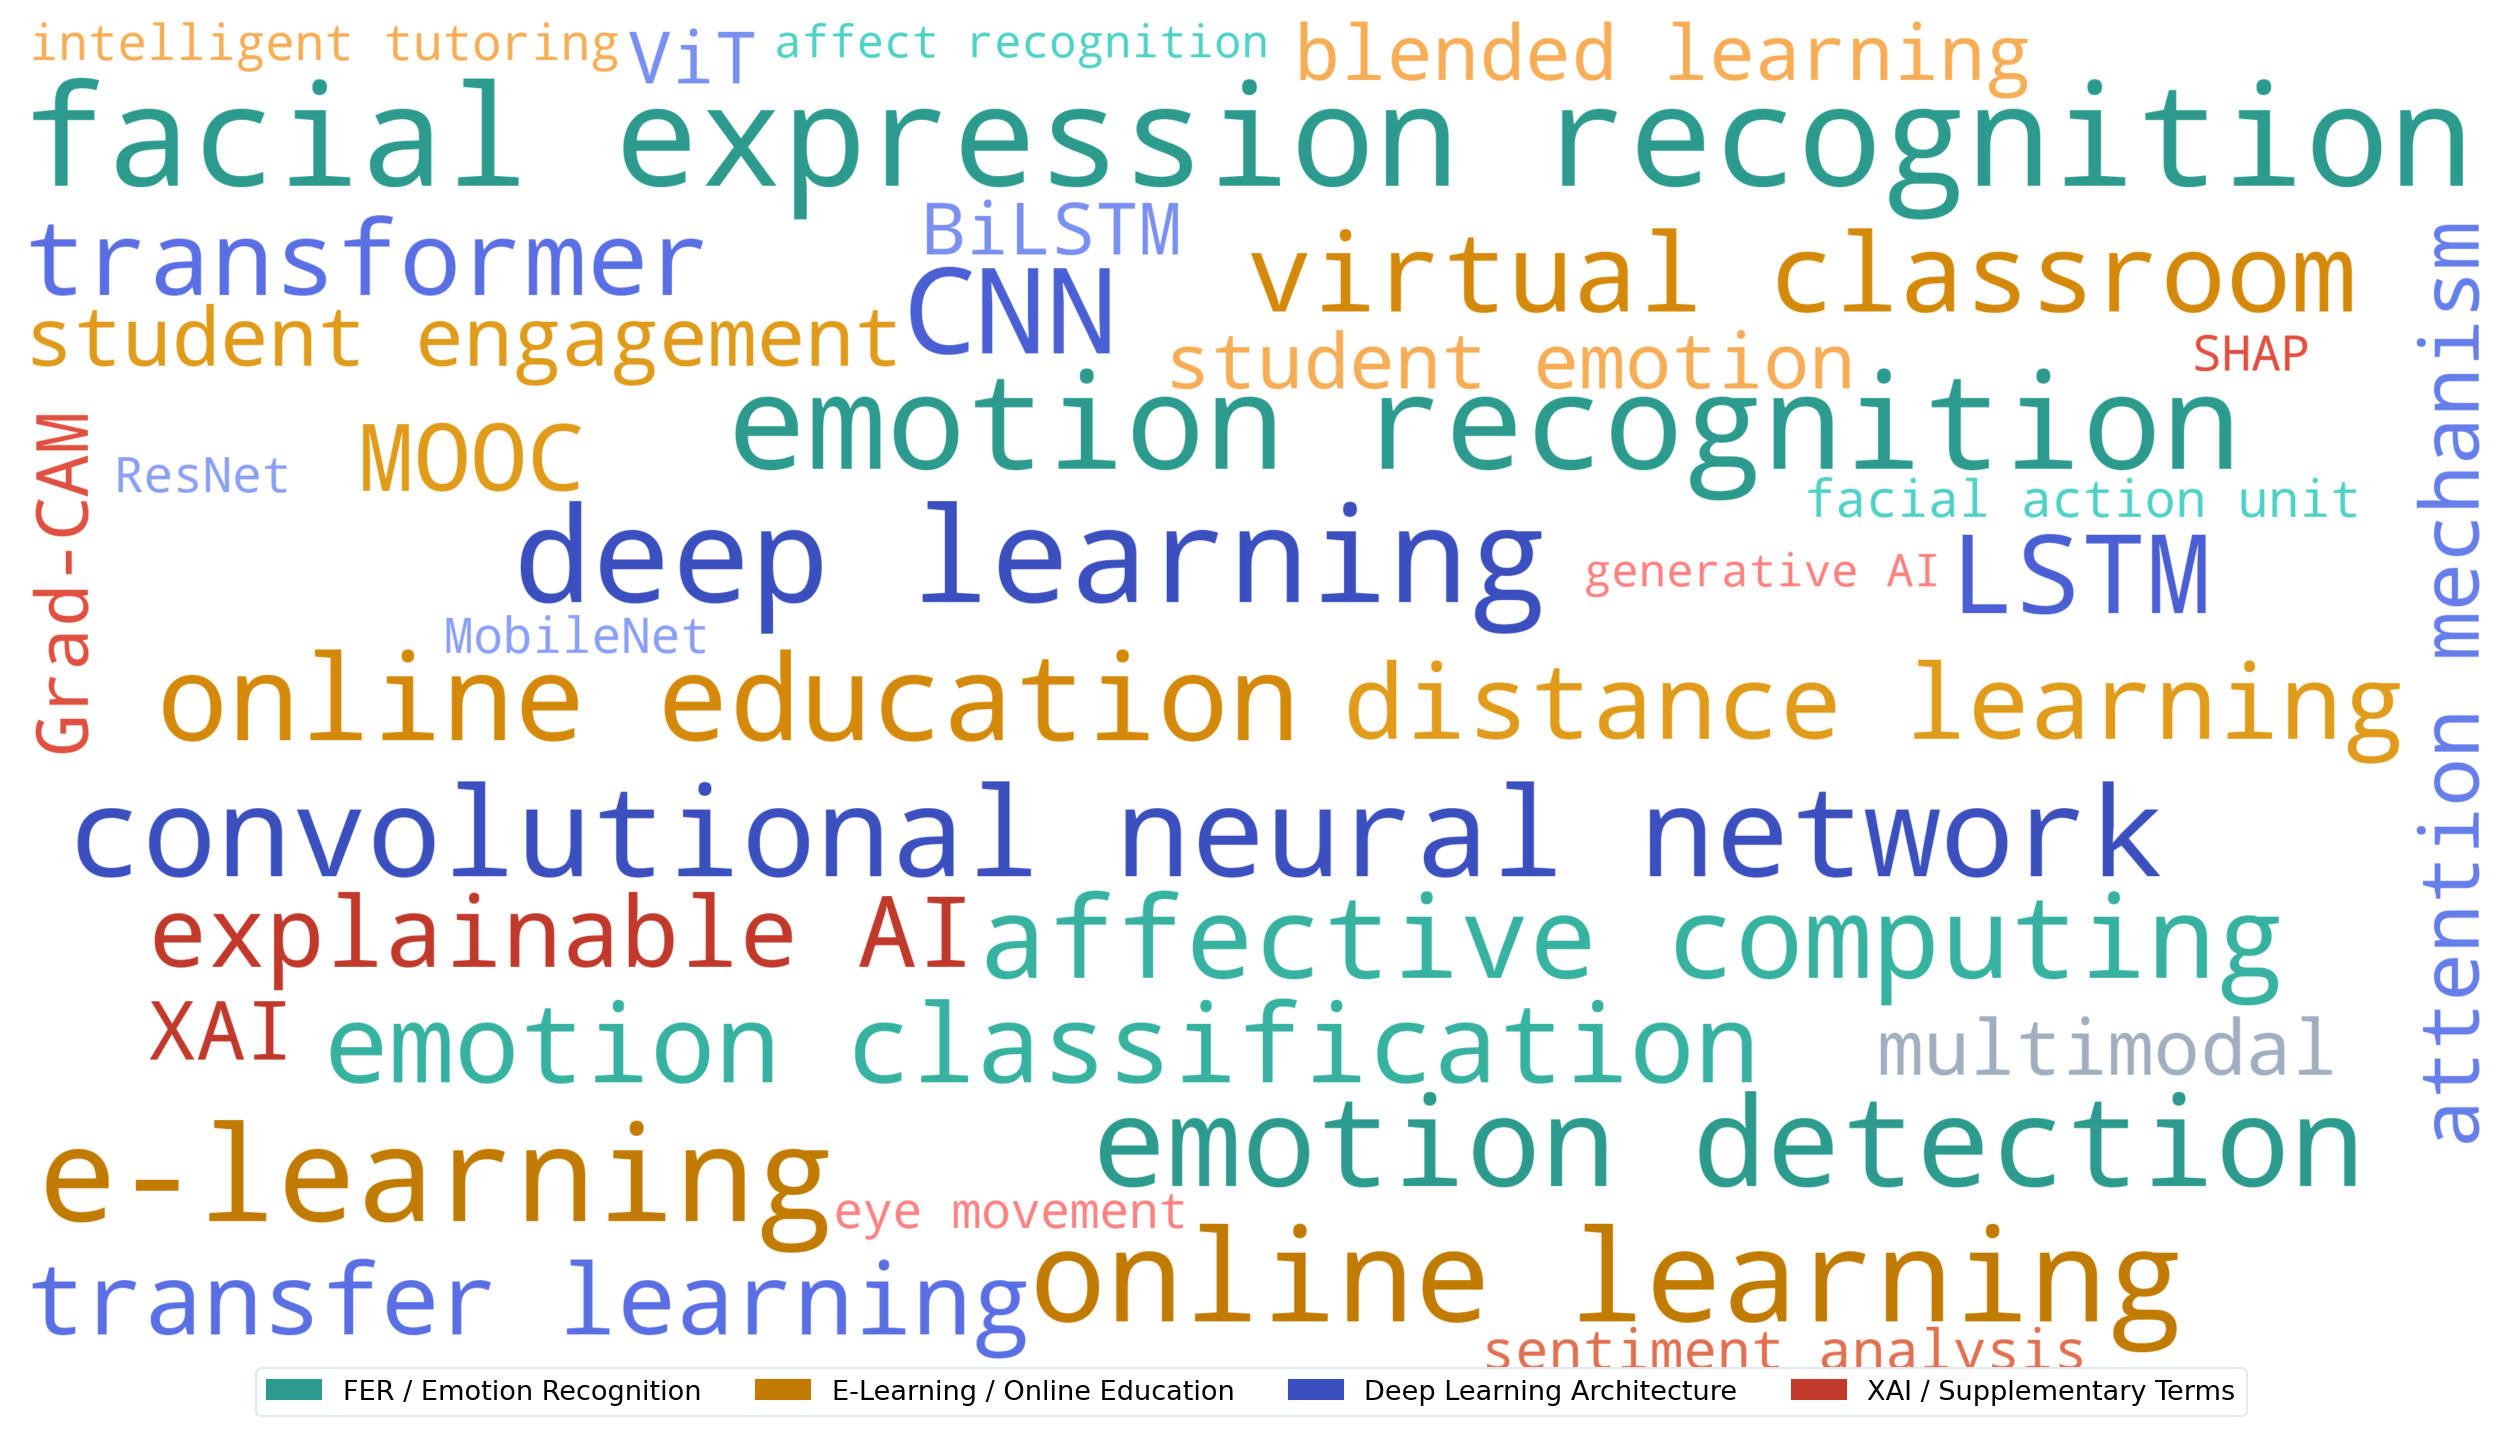

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/WC1_Search_String_Terms.png


In [ ]:
# [FIG-WC1] Word Cloud — Search String Terms — REVISED
# Fix: underscores removed, no title/subtitle

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Search terms with frequency weights ───────────────────────────────
search_terms = {
    'facial expression recognition' : 18,
    'emotion recognition'           : 16,
    'emotion detection'             : 14,
    'affective computing'           : 12,
    'emotion classification'        : 11,
    'facial action unit'            : 6,
    'affect recognition'            : 5,
    'e-learning'                    : 16,
    'online learning'               : 15,
    'online education'              : 13,
    'virtual classroom'             : 11,
    'distance learning'             : 10,
    'MOOC'                          : 9,
    'blended learning'              : 8,
    'student engagement'            : 9,
    'student emotion'               : 8,
    'intelligent tutoring'          : 6,
    'deep learning'                 : 16,
    'convolutional neural network'  : 14,
    'CNN'                           : 13,
    'LSTM'                          : 11,
    'transformer'                   : 10,
    'transfer learning'             : 10,
    'attention mechanism'           : 9,
    'ViT'                           : 7,
    'BiLSTM'                        : 7,
    'ResNet'                        : 6,
    'MobileNet'                     : 6,
    'explainable AI'                : 10,
    'XAI'                           : 9,
    'Grad-CAM'                      : 7,
    'SHAP'                          : 6,
    'eye movement'                  : 6,
    'generative AI'                 : 5,
    'sentiment analysis'            : 7,
    'multimodal'                    : 8,
}

# ── Color map keyed to ORIGINAL terms (no underscore) ─────────────────
cluster_colors = {
    'facial expression recognition': '#2C9B8E',
    'emotion recognition'          : '#2C9B8E',
    'emotion detection'            : '#2C9B8E',
    'affective computing'          : '#38B2A0',
    'emotion classification'       : '#38B2A0',
    'facial action unit'           : '#4FD1C5',
    'affect recognition'           : '#4FD1C5',
    'e-learning'                   : '#C07B00',
    'online learning'              : '#C07B00',
    'online education'             : '#D4890A',
    'virtual classroom'            : '#D4890A',
    'distance learning'            : '#E09B1A',
    'MOOC'                         : '#E09B1A',
    'blended learning'             : '#F6AD55',
    'student engagement'           : '#E09B1A',
    'student emotion'              : '#F6AD55',
    'intelligent tutoring'         : '#F6AD55',
    'deep learning'                : '#3B4FBF',
    'convolutional neural network' : '#3B4FBF',
    'CNN'                          : '#4A5FD4',
    'LSTM'                         : '#4A5FD4',
    'transformer'                  : '#5A6FE4',
    'transfer learning'            : '#5A6FE4',
    'attention mechanism'          : '#667EEA',
    'ViT'                          : '#7A90F0',
    'BiLSTM'                       : '#7A90F0',
    'ResNet'                       : '#8A9FF5',
    'MobileNet'                    : '#8A9FF5',
    'explainable AI'               : '#C0392B',
    'XAI'                          : '#C0392B',
    'Grad-CAM'                     : '#E05040',
    'SHAP'                         : '#E05040',
    'eye movement'                 : '#FC8181',
    'generative AI'                : '#FC8181',
    'sentiment analysis'           : '#E07050',
    'multimodal'                   : '#A0AEC0',
}

# ── Key fix: use ~ as internal separator, replace back after rendering ─
# WordCloud splits on spaces — use ~ to keep multi-word terms together,
# then override the word in color_func by stripping ~

freq_dict = {}
term_map  = {}   # tilde_version → original
for term, freq in search_terms.items():
    key = term.replace(' ', '~')
    freq_dict[key] = freq
    term_map[key]  = term

def cluster_color_func(word, font_size, position, orientation,
                        random_state=None, **kwargs):
    original = term_map.get(word, word.replace('~', ' '))
    return cluster_colors.get(original, '#718096')

# ── Generate ───────────────────────────────────────────────────────────
wc = WordCloud(
    width             = 3600,
    height            = 2000,
    background_color  = 'white',
    max_font_size     = 210,
    min_font_size     = 30,
    prefer_horizontal = 0.72,
    collocations      = False,
    margin            = 14,
    relative_scaling  = 0.52,
    random_state      = 42,
    regexp            = r'[^\s]+',   # treat ~ as non-space → keeps term together
)
wc.generate_from_frequencies(freq_dict)
wc.recolor(color_func=cluster_color_func)

# ── Render ─────────────────────────────────────────────────────────────
# Get word positions and replace ~ with spaces in the layout
# We do this by patching the layout_ attribute
new_layout = []
for (word, freq), font_size, position, orientation, color in wc.layout_:
    clean_word = word.replace('~', ' ')
    new_layout.append(((clean_word, freq), font_size, position, orientation, color))
wc.layout_ = new_layout

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10), facecolor='white')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

# Legend only — no title
legend_items = [
    mpatches.Patch(color='#2C9B8E', label='FER / Emotion Recognition'),
    mpatches.Patch(color='#C07B00', label='E-Learning / Online Education'),
    mpatches.Patch(color='#3B4FBF', label='Deep Learning Architecture'),
    mpatches.Patch(color='#C0392B', label='XAI / Supplementary Terms'),
]
ax.legend(
    handles        = legend_items,
    loc            = 'lower center',
    bbox_to_anchor = (0.5, -0.03),
    ncol           = 4,
    fontsize       = 13,
    frameon        = True,
    framealpha     = 0.95,
    edgecolor      = '#E2E8F0',
)

plt.tight_layout(rect=[0, 0.04, 1, 1.0])

# ── Save ───────────────────────────────────────────────────────────────
out_path = os.path.join(FIGURES_PATH, 'WC1_Search_String_Terms.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 13 — [FIG-WC2] Word Cloud — Titles of Final 56 Papers

In [ ]:
# [FIG-WC2] Word Cloud — Paper Titles — CLEAN
# Method: count actual title words, remove noise, pass freq dict

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import re

# ── Raw title text ─────────────────────────────────────────────────────
titles = df['Title of Study'].dropna().tolist()

# ── Tokenize: only real words, min 4 chars, no abbreviations ──────────
all_words = []
for title in titles:
    tokens = re.findall(r'\b[A-Za-z][a-z]{2,}\b', title)  # lowercase words 4+ chars only
    all_words.extend(tokens)

# Count
word_counts = Counter(all_words)

# ── Stopwords — noise only ─────────────────────────────────────────────
drop = {
    'using', 'based', 'approach', 'method', 'system', 'model',
    'proposed', 'novel', 'towards', 'toward', 'study', 'paper',
    'framework', 'feature', 'features', 'improved', 'efficient',
    'effective', 'automatic', 'application', 'applications',
    'investigation', 'enhancing', 'leveraging', 'advancing',
    'performance', 'comprehensive', 'with', 'from', 'that',
    'this', 'their', 'have', 'been', 'into', 'through',
    'during', 'within', 'between', 'about', 'which', 'when',
    'network', 'networks', 'architecture', 'architectures',
    'mechanism', 'mechanisms', 'process', 'platform', 'pipeline',
    'environment', 'environments', 'context', 'distribution',
    'training', 'assessment', 'evaluation', 'generation',
    'modeling', 'prediction', 'extraction', 'monitoring',
    'tracking', 'implementation', 'computing', 'understanding',
    'identifying', 'detecting', 'integrating', 'instructing',
    'interventions', 'preprocessing', 'labeling', 'reasoning',
    'continuous', 'dynamic', 'advanced', 'optimal', 'digital',
    'large', 'scale', 'sparse', 'synthetic', 'adversarial',
    'pedagogical', 'conversational', 'synchronization',
    'audiovisual', 'multilayer', 'physiological', 'recurrent',
    'homogeneous', 'ensemble', 'exemplar', 'artificial',
    'mental', 'social', 'verbal', 'emotional', 'ability',
    'channels', 'signals', 'signal', 'states', 'state',
    'classes', 'label', 'human', 'agent', 'health', 'children',
    'courses', 'teaching', 'activities', 'indicators', 'experts',
    'mixture', 'pipeline', 'supervised', 'semi', 'pseudo',
    'empathy', 'feedback', 'assistance', 'interaction', 'task',
    'tasks', 'behavior', 'behaviors', 'movement', 'intensity',
    'connectivity', 'containment', 'estimation', 'progress',
    'generation', 'development', 'adoption', 'awareness',
    'revolutionizing', 'instructing', 'advancing',
}

# Apply stopwords
freq_clean = {w: c for w, c in word_counts.items()
              if w.lower() not in drop and c >= 2}

# Print what goes in
print(f"Total unique words after cleaning: {len(freq_clean)}")
print("\nAll words and counts:")
for w, c in sorted(freq_clean.items(), key=lambda x: -x[1]):
    print(f"  {w:<25} {c}")

Total unique words after cleaning: 59

All words and counts:
  for                       30
  learning                  22
  Learning                  21
  Emotion                   21
  Facial                    20
  Recognition               20
  and                       17
  recognition               16
  Online                    16
  facial                    12
  deep                      12
  emotion                   10
  Expression                9
  Detection                 9
  detection                 8
  online                    8
  expression                7
  Deep                      7
  time                      7
  the                       5
  student                   5
  convolutional             5
  engagement                5
  Neural                    4
  neural                    4
  Video                     4
  Real                      4
  real                      4
  Lightweight               4
  classroom                 3
  classification           

21:39:20  INFO      Generating dense word cloud  (33 terms, repeat=True) …
21:39:22  INFO      Placed 87 tokens (includes repeats).
21:39:23  INFO      Saved → figures/WC2_Paper_Titles.png  (dpi=300)


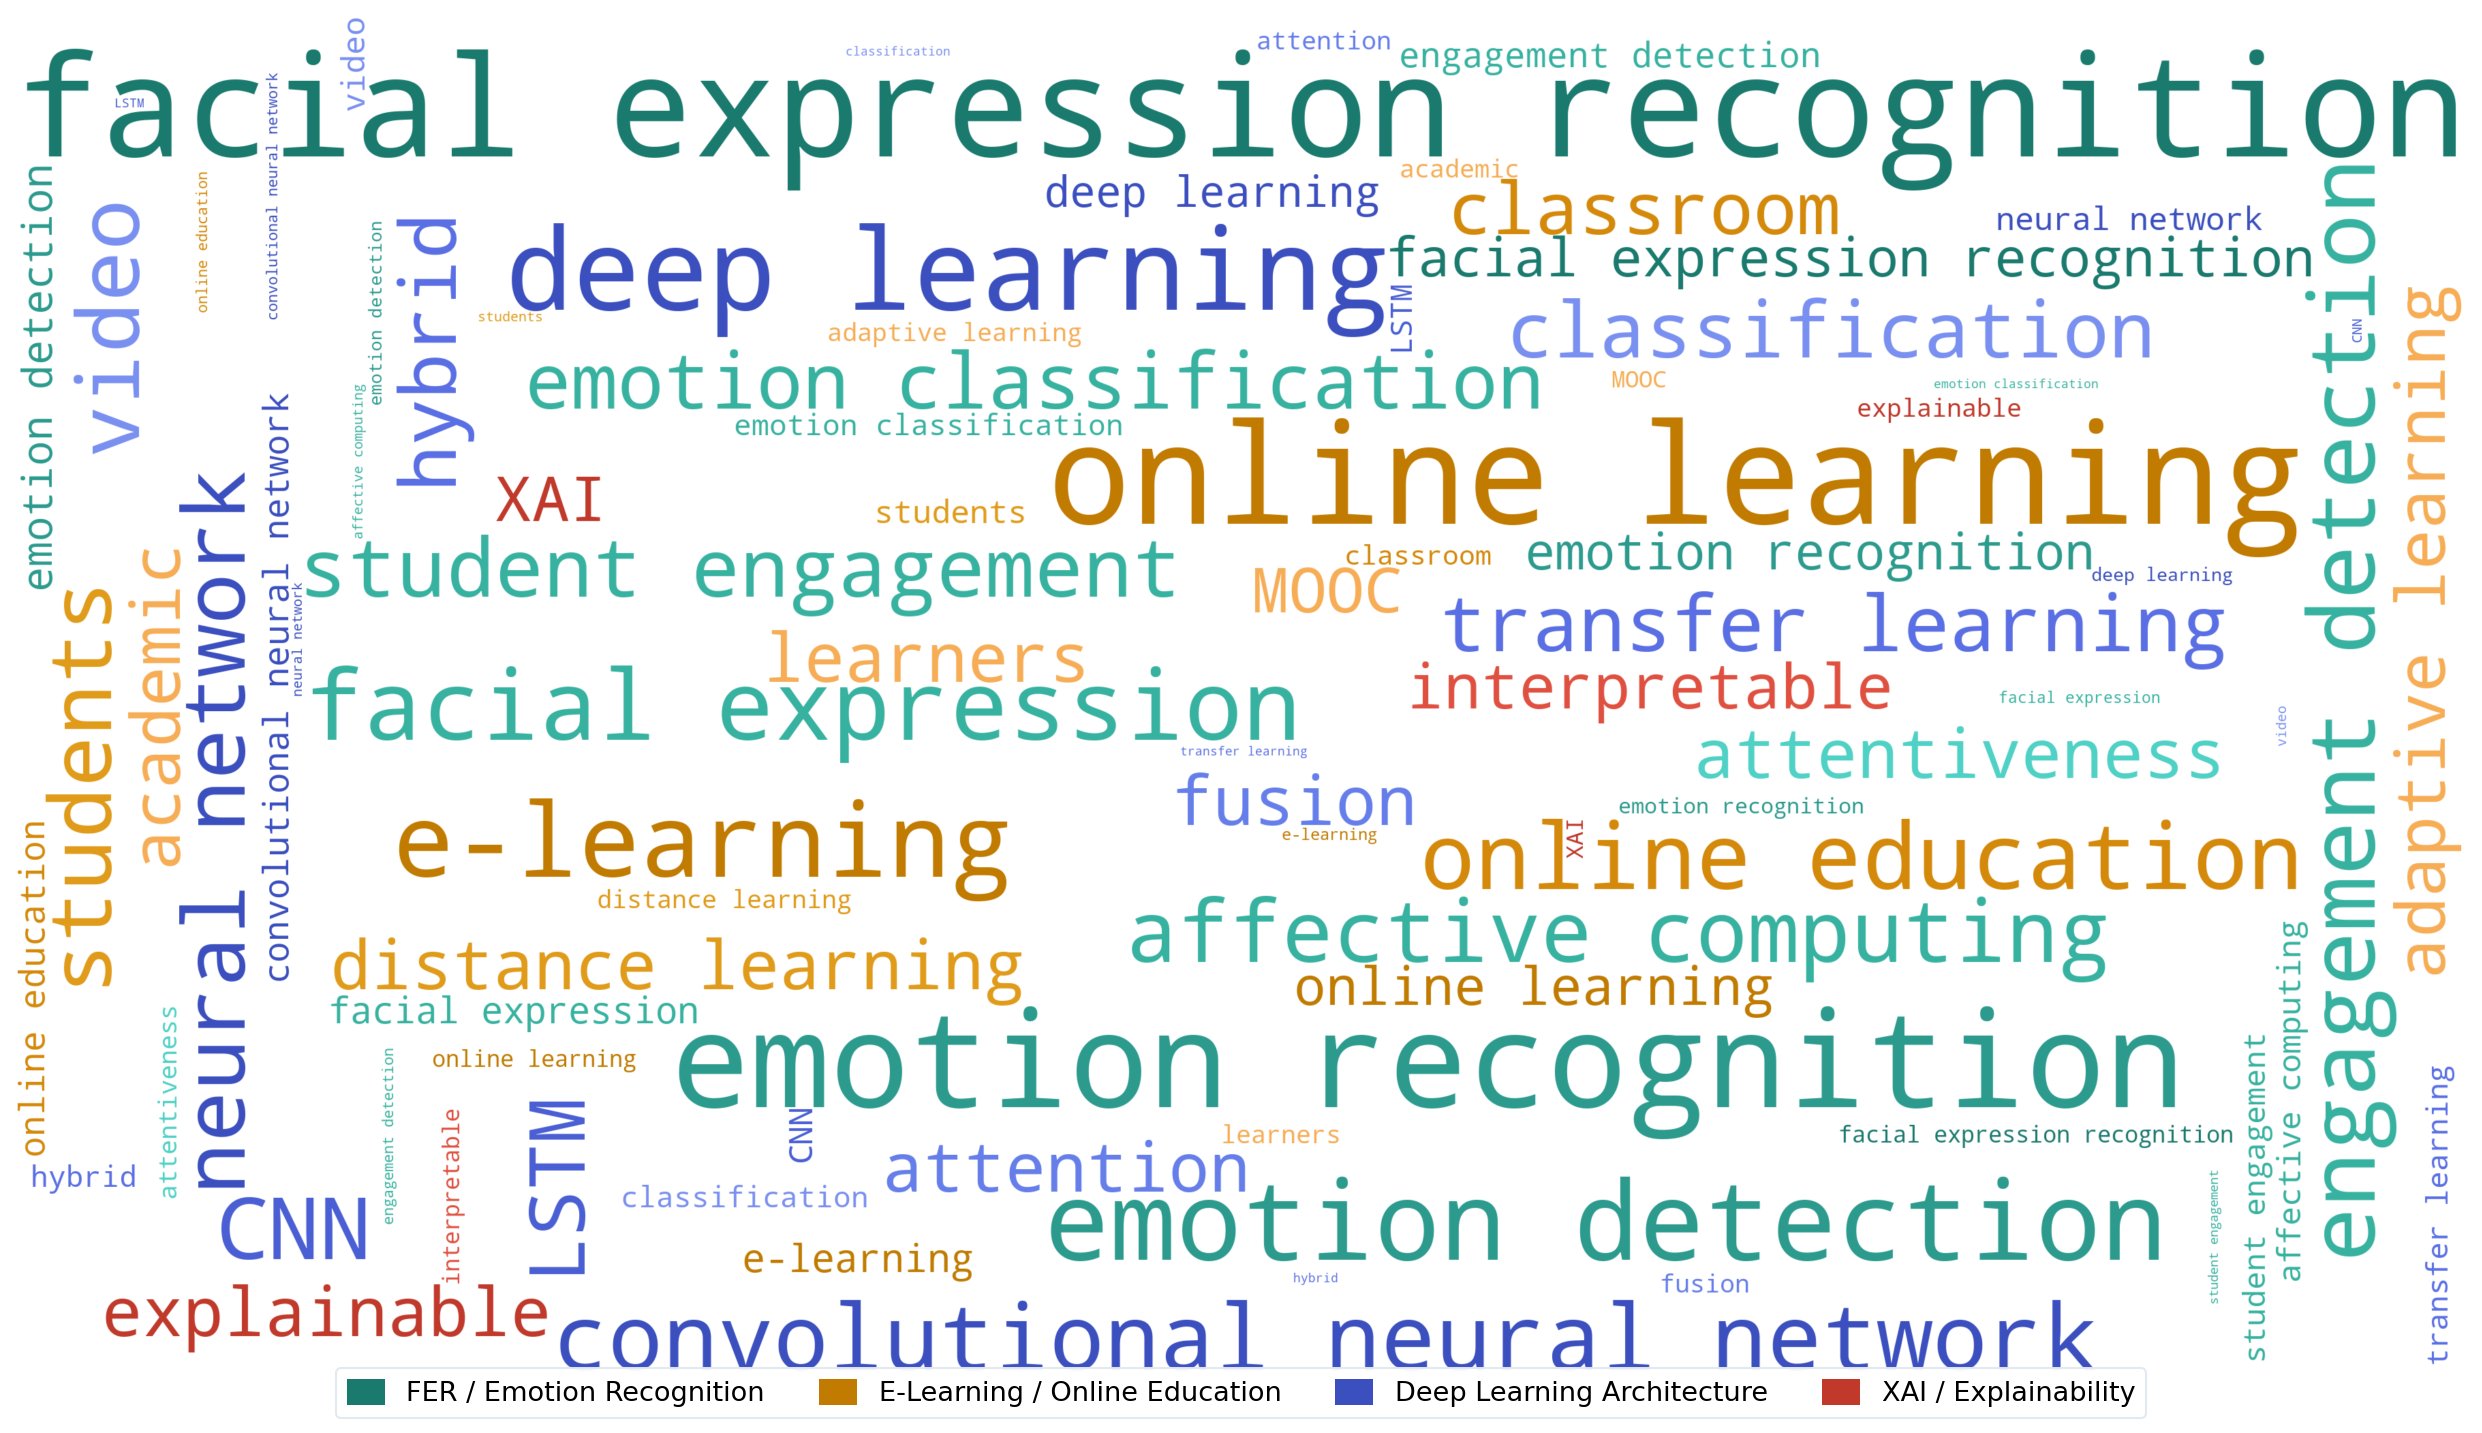

In [ ]:
"""
FIG-WC2 | Word Cloud — Paper Titles  (dense / no-whitespace version)
"""

from __future__ import annotations

import logging
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ── Logging ────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level  = logging.INFO,
    format = "%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt= "%H:%M:%S",
)
log = logging.getLogger(__name__)

# ── Output path ────────────────────────────────────────────────────────────────
FIGURES_PATH: str = os.environ.get("FIGURES_PATH", "figures")
Path(FIGURES_PATH).mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Theme data  — frequencies scaled up (×6) to force dense packing
#     The RATIO between values is what controls relative size; the absolute
#     magnitude pushes WordCloud to fill every pixel of free space.
# ══════════════════════════════════════════════════════════════════════════════

SCALE = 6          # raise to pack tighter; ratios stay identical

@dataclass(frozen=True)
class Term:
    text  : str
    freq  : int
    color : str
    theme : str


_TEAL   = ("#1A7A6E", "#2C9B8E", "#38B2A0", "#4FD1C5")
_GOLD   = ("#A06500", "#C07B00", "#D4890A", "#E09B1A", "#F6AD55")
_INDIGO = ("#2A3DAF", "#3B4FBF", "#4A5FD4", "#5A6FE4", "#667EEA", "#7A90F0")
_CORAL  = ("#A93226", "#C0392B", "#E05040")

THEME_DATA: list[Term] = [
    # ── FER / Emotion ──────────────────────────────────────────────────
    Term("facial expression recognition", 38*SCALE, _TEAL[0], "FER / Emotion Recognition"),
    Term("emotion recognition",           32*SCALE, _TEAL[1], "FER / Emotion Recognition"),
    Term("emotion detection",             17*SCALE, _TEAL[1], "FER / Emotion Recognition"),
    Term("facial expression",             12*SCALE, _TEAL[2], "FER / Emotion Recognition"),
    Term("affective computing",            8*SCALE, _TEAL[2], "FER / Emotion Recognition"),
    Term("engagement detection",          10*SCALE, _TEAL[2], "FER / Emotion Recognition"),
    Term("emotion classification",         6*SCALE, _TEAL[2], "FER / Emotion Recognition"),
    Term("student engagement",             7*SCALE, _TEAL[2], "FER / Emotion Recognition"),
    Term("attentiveness",                  4*SCALE, _TEAL[3], "FER / Emotion Recognition"),

    # ── E-Learning / Education ─────────────────────────────────────────
    Term("online learning",   37*SCALE, _GOLD[1], "E-Learning / Online Education"),
    Term("e-learning",        14*SCALE, _GOLD[1], "E-Learning / Online Education"),
    Term("online education",  10*SCALE, _GOLD[2], "E-Learning / Online Education"),
    Term("classroom",          5*SCALE, _GOLD[2], "E-Learning / Online Education"),
    Term("distance learning",  4*SCALE, _GOLD[3], "E-Learning / Online Education"),
    Term("students",           8*SCALE, _GOLD[3], "E-Learning / Online Education"),
    Term("learners",           4*SCALE, _GOLD[4], "E-Learning / Online Education"),
    Term("academic",           4*SCALE, _GOLD[4], "E-Learning / Online Education"),
    Term("adaptive learning",  4*SCALE, _GOLD[4], "E-Learning / Online Education"),
    Term("MOOC",               3*SCALE, _GOLD[4], "E-Learning / Online Education"),

    # ── Deep Learning ──────────────────────────────────────────────────
    Term("deep learning",                19*SCALE, _INDIGO[1], "Deep Learning Architecture"),
    Term("convolutional neural network", 10*SCALE, _INDIGO[1], "Deep Learning Architecture"),
    Term("CNN",                           8*SCALE, _INDIGO[2], "Deep Learning Architecture"),
    Term("LSTM",                          6*SCALE, _INDIGO[2], "Deep Learning Architecture"),
    Term("transfer learning",             6*SCALE, _INDIGO[3], "Deep Learning Architecture"),
    Term("hybrid",                        6*SCALE, _INDIGO[3], "Deep Learning Architecture"),
    Term("fusion",                        4*SCALE, _INDIGO[4], "Deep Learning Architecture"),
    Term("attention",                     4*SCALE, _INDIGO[4], "Deep Learning Architecture"),
    Term("video",                         8*SCALE, _INDIGO[5], "Deep Learning Architecture"),
    Term("neural network",                8*SCALE, _INDIGO[1], "Deep Learning Architecture"),
    Term("classification",                6*SCALE, _INDIGO[5], "Deep Learning Architecture"),

    # ── XAI ────────────────────────────────────────────────────────────
    Term("explainable",   4*SCALE, _CORAL[1], "XAI / Explainability"),
    Term("XAI",           3*SCALE, _CORAL[1], "XAI / Explainability"),
    Term("interpretable", 3*SCALE, _CORAL[2], "XAI / Explainability"),
]

# ══════════════════════════════════════════════════════════════════════════════
# 2.  Build lookup tables
# ══════════════════════════════════════════════════════════════════════════════

def _build_lookups(
    data: list[Term],
) -> tuple[dict[str, int], dict[str, str], dict[str, str]]:
    freq_dict, color_map, display_map = {}, {}, {}
    for term in data:
        key               = term.text.replace(" ", "~")
        freq_dict[key]    = term.freq
        color_map[key]    = term.color
        display_map[key]  = term.text
    return freq_dict, color_map, display_map

# ══════════════════════════════════════════════════════════════════════════════
# 3.  WordCloud config  — tuned for zero whitespace
# ══════════════════════════════════════════════════════════════════════════════

_WC_DENSE: dict = dict(
    width             = 3600,
    height            = 2000,

    background_color  = "white",

    # ── Font range ──────────────────────────────────────────────────────
    max_font_size     = 220,
    min_font_size     = 18,       # ↓ smaller floor → more words can fit

    # ── Packing behaviour ───────────────────────────────────────────────
    prefer_horizontal = 0.75,     # allow more verticals to fill corners
    relative_scaling  = 0.35,     # ↓ compress size ratios → smaller words fit
    margin            = 2,        # ↓ tighter gutters between words
    max_words         = 300,      # ↑ lets WC attempt many repeat fills
    collocations      = False,
    repeat            = True,     # ← KEY: repeats terms until canvas full
    include_numbers   = False,

    random_state      = 42,
    regexp            = r"[^\s]+",
)

# ══════════════════════════════════════════════════════════════════════════════
# 4.  Build helpers
# ══════════════════════════════════════════════════════════════════════════════

def build_color_func(
    color_map  : dict[str, str],
    fallback   : str = "#718096",
) -> Callable:
    def _fn(word, font_size, position, orientation,
            random_state=None, **kwargs) -> str:
        return color_map.get(word.replace(" ", "~"), fallback)
    return _fn


def build_wordcloud(
    freq_dict  : dict[str, int],
    color_map  : dict[str, str],
    display_map: dict[str, str],
    wc_kwargs  : dict | None = None,
) -> WordCloud:
    cfg = {**_WC_DENSE, **(wc_kwargs or {})}
    log.info("Generating dense word cloud  (%d terms, repeat=True) …", len(freq_dict))

    wc = WordCloud(**cfg)
    wc.generate_from_frequencies(freq_dict)
    wc.recolor(color_func=build_color_func(color_map))

    # Restore spaces in layout_ for clean rendering
    wc.layout_ = [
        (
            (display_map.get(word, word.replace("~", " ")), freq),
            font_size, position, orientation, color,
        )
        for (word, freq), font_size, position, orientation, color
        in wc.layout_
    ]

    placed = len(wc.layout_)
    log.info("Placed %d tokens (includes repeats).", placed)
    return wc


# ══════════════════════════════════════════════════════════════════════════════
# 5.  Figure
# ══════════════════════════════════════════════════════════════════════════════

def _build_legend(data: list[Term]) -> list[mpatches.Patch]:
    seen: dict[str, str] = {}
    for t in data:
        seen.setdefault(t.theme, t.color)
    return [
        mpatches.Patch(facecolor=c, label=lbl, linewidth=0)
        for lbl, c in seen.items()
    ]


def plot_wordcloud(
    wc      : WordCloud,
    data    : list[Term],
    figsize : tuple[float, float] = (18, 10),
    out_path: str | Path | None   = None,
    dpi     : int                 = 300,
) -> plt.Figure:

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")



    patches = _build_legend(data)
    ax.legend(
        handles        = patches,
        loc            = "lower center",
        bbox_to_anchor = (0.5, -0.04),
        ncol           = len(patches),
        fontsize       = 13,
        frameon        = True,
        framealpha     = 0.95,
        edgecolor      = "#E2E8F0",
        handlelength   = 1.4,
        handleheight   = 1.1,
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1.0])

    if out_path is not None:
        p = Path(out_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=dpi, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        log.info("Saved → %s  (dpi=%d)", p, dpi)

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# 6.  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main() -> None:
    freq_dict, color_map, display_map = _build_lookups(THEME_DATA)
    wc  = build_wordcloud(freq_dict, color_map, display_map)
    out = Path(FIGURES_PATH) / "WC2_Paper_Titles.png"
    fig = plot_wordcloud(wc, THEME_DATA, out_path=out, dpi=300)
    plt.show()
    


if __name__ == "__main__":
    main()

## CELL 14 — Stacked Bar Chart: Annual Publications 2018–2026 by Architecture Family (Figure F4).

In [12]:
# Quick audit before F4
print(df['Year'].value_counts().sort_index())
print()
print(df['Architecture_Family'].value_counts())
print()
print(pd.crosstab(df['Year'], df['Architecture_Family']))

Year
2018     1
2020     3
2021     5
2022     7
2023    10
2024    14
2025    11
2026     5
Name: count, dtype: Int64

Architecture_Family
CNN/Hybrid     47
Transformer     5
Other/NA        2
RNN/LSTM        2
Name: count, dtype: int64

Architecture_Family  CNN/Hybrid  Other/NA  RNN/LSTM  Transformer
Year                                                            
2018                          0         0         1            0
2020                          3         0         0            0
2021                          3         1         1            0
2022                          6         0         0            1
2023                          9         0         0            1
2024                         13         1         0            0
2025                          8         0         0            3
2026                          5         0         0            0


## CELL 14A — [AUDIT] Architecture Classification Check

In [13]:
# [AUDIT] Check which papers landed in RNN/LSTM vs CNN/Hybrid
# to verify classifier accuracy before drawing F4

print("=== RNN/LSTM papers ===")
rnn_mask = df['Architecture_Family'] == 'RNN/LSTM'
for _, row in df[rnn_mask].iterrows():
    print(f"\n  {row['Study ID']}")
    print(f"  Raw: {str(row['Primary DL Architecture'])[:120]}")

print("\n=== Other/NA papers ===")
other_mask = df['Architecture_Family'] == 'Other/NA'
for _, row in df[other_mask].iterrows():
    print(f"\n  {row['Study ID']}")
    print(f"  Raw: {str(row['Primary DL Architecture'])[:120]}")

print("\n=== Transformer papers ===")
trans_mask = df['Architecture_Family'] == 'Transformer'
for _, row in df[trans_mask].iterrows():
    print(f"\n  {row['Study ID']}")
    print(f"  Raw: {str(row['Primary DL Architecture'])[:120]}")

print("\n=== Sample CNN/Hybrid — check for misclassified RNN-primary papers ===")
cnn_mask = df['Architecture_Family'] == 'CNN/Hybrid'
for _, row in df[cnn_mask].iterrows():
    raw = str(row['Primary DL Architecture']).lower()
    if any(k in raw for k in ['lstm', 'rnn', 'gru', 'bilstm']):
        print(f"\n  {row['Study ID']}")
        print(f"  Raw: {str(row['Primary DL Architecture'])[:120]}")

=== RNN/LSTM papers ===

  Kratzwald 2018
  Raw: RNN / LSTM / BiLSTM.

  Awais 2021
  Raw: RNN / LSTM

=== Other/NA papers ===

  Hayashi 2024
  Raw: Not applicable.

No deep learning model was developed.

Study focused on multimodal synchronization indicators.

  Nandi 2021
  Raw: N/A (Traditional ML / Linear Model)

=== Transformer papers ===

  Kumar 2022
  Raw: CNN / RNN / LSTM / Bi-LSTM / GRU / CNN-LSTM / CNN-GRU / Transformer / ViT / Hybrid -> Other: ANN / MLP (Multilayer Perce

  Long 2022
  Raw: CNN (Dense-connectivity / DenseNet variant)

  Zang 2025
  Raw: RNN / Bi-LSTM / Hybrid (BiLSTM-CRF + Transformer-based WoBert)

  Wang 2025
  Raw: ViT / Hybrid (MobileViT variant)


  Liu 2025
  Raw: Transformer / ViT / Hybrid

=== Sample CNN/Hybrid — check for misclassified RNN-primary papers ===

  Bashir 2025
  Raw: CNN-LSTM Hybrid

  Asaju 2022
  Raw: CNN-BiLSTM / Hybrid

  Jagadeesh 2022
  Raw: Hybrid CNN-RNN.

  Lin 2020
  Raw: Hybrid CNN-LSTM framework.

  Mai 2022
  Raw: CNN-LST

## CELL 14B — [CLEAN] Fix Architecture Misclassifications

In [14]:
# [CLEAN] Fix 2 specific misclassifications

# Long 2022: DenseNet = CNN/Hybrid, not Transformer
df.loc[df['Study ID'] == 'Long 2022', 'Architecture_Family'] = 'CNN/Hybrid'

# Zang 2025: BiLSTM-CRF primary, Transformer supplementary = RNN/LSTM
df.loc[df['Study ID'] == 'Zang 2025', 'Architecture_Family'] = 'RNN/LSTM'

# Verify
print("Updated architecture distribution:")
print(df['Architecture_Family'].value_counts())
print()
print("Updated crosstab Year × Architecture:")
print(pd.crosstab(df['Year'], df['Architecture_Family']))

Updated architecture distribution:
Architecture_Family
CNN/Hybrid     48
Transformer     3
RNN/LSTM        3
Other/NA        2
Name: count, dtype: int64

Updated crosstab Year × Architecture:
Architecture_Family  CNN/Hybrid  Other/NA  RNN/LSTM  Transformer
Year                                                            
2018                          0         0         1            0
2020                          3         0         0            0
2021                          3         1         1            0
2022                          7         0         0            0
2023                          9         0         0            1
2024                         13         1         0            0
2025                          8         0         1            2
2026                          5         0         0            0


## CELL 14 — [FIG-F4] Stacked Bar: Annual Publications 2018–2026

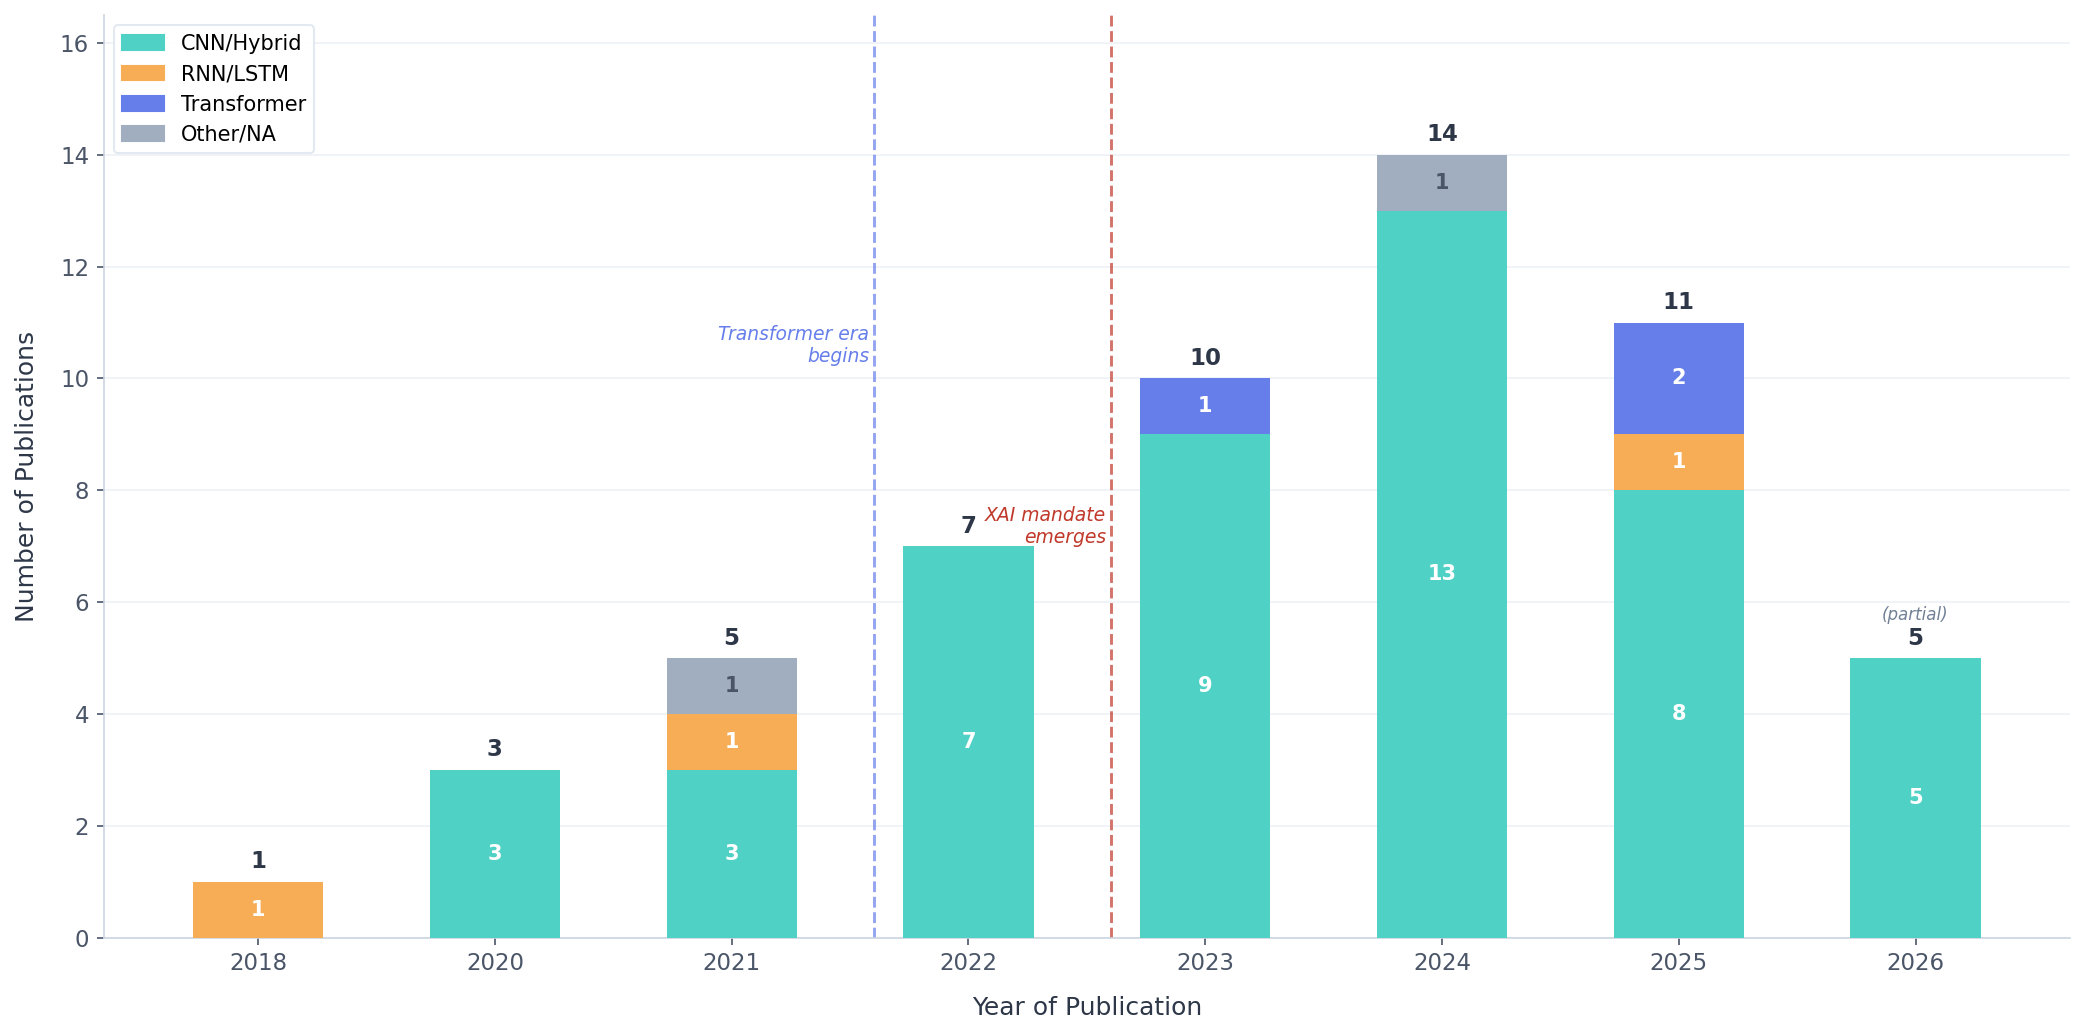

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F4_Annual_Publications.png


In [15]:
# [FIG-F4] Stacked Bar — Annual Publications 2018–2026 by Architecture Family

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Data ───────────────────────────────────────────────────────────────
ct = pd.crosstab(df['Year'], df['Architecture_Family'])

# Ensure all families present and in correct order
families = ['CNN/Hybrid', 'RNN/LSTM', 'Transformer', 'Other/NA']
for f in families:
    if f not in ct.columns:
        ct[f] = 0
ct = ct[families]

years   = ct.index.tolist()
x       = np.arange(len(years))
bar_w   = 0.55

colors = {
    'CNN/Hybrid'  : '#4FD1C5',
    'RNN/LSTM'    : '#F6AD55',
    'Transformer' : '#667EEA',
    'Other/NA'    : '#A0AEC0',
}

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

bottoms = np.zeros(len(years))
bars_by_family = {}
for family in families:
    vals = ct[family].values.astype(float)
    bars = ax.bar(x, vals, bar_w,
                  bottom=bottoms,
                  color=colors[family],
                  label=family,
                  zorder=3)
    bars_by_family[family] = (bars, vals, bottoms.copy())
    bottoms += vals

# ── Value labels inside bars ───────────────────────────────────────────
for family, (bars, vals, bots) in bars_by_family.items():
    for bar, val, bot in zip(bars, vals, bots):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2,
                    str(int(val)),
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if family != 'Other/NA' else '#4A5568',
                    zorder=5)

# ── Total labels on top of each bar ───────────────────────────────────
totals = ct.sum(axis=1).values
for i, total in enumerate(totals):
    ax.text(x[i], total + 0.15, str(int(total)),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#2D3748')

# ── Annotation lines ───────────────────────────────────────────────────
# Transformer era begins — 2022 (first Transformer paper in data)
ax.axvline(x=years.index(2022) - 0.4, color='#667EEA',
           linestyle='--', linewidth=1.4, alpha=0.7, zorder=2)
ax.text(years.index(2022) - 0.42, ax.get_ylim()[1] * 0.72,
        'Transformer era\nbegins',
        ha='right', va='center',
        fontsize=9, color='#667EEA',
        style='italic')

# XAI mandate emerges — 2023
ax.axvline(x=years.index(2023) - 0.4, color='#C0392B',
           linestyle='--', linewidth=1.4, alpha=0.7, zorder=2)
ax.text(years.index(2023) - 0.42, ax.get_ylim()[1] * 0.50,
        'XAI mandate\nemerges',
        ha='right', va='center',
        fontsize=9, color='#C0392B',
        style='italic')

# 2026 partial year note
ax.text(years.index(2026), totals[-1] + 0.6,
        '(partial)',
        ha='center', va='bottom',
        fontsize=8, color='#718096', style='italic')

# ── Axes formatting ────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], fontsize=12)
ax.set_ylabel('Number of Publications', fontsize=12, color='#2D3748', labelpad=10)
ax.set_xlabel('Year of Publication', fontsize=12, color='#2D3748', labelpad=10)
ax.set_ylim(0, max(totals) + 2.5)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.tick_params(axis='both', colors='#4A5568', labelsize=11)
ax.spines['left'].set_color('#CBD5E0')
ax.spines['bottom'].set_color('#CBD5E0')
ax.grid(axis='y', color='#EDF2F7', linewidth=0.8, zorder=0)

# ── Legend ─────────────────────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=colors[f], label=f) for f in families]
ax.legend(
    handles        = legend_patches,
    loc            = 'upper left',
    fontsize       = 10,
    frameon        = True,
    framealpha     = 0.95,
    edgecolor      = '#E2E8F0',
    ncol           = 1,
)

plt.tight_layout()

# ── Save ───────────────────────────────────────────────────────────────
out_path = os.path.join(FIGURES_PATH, 'F4_Annual_Publications.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 15A — [AUDIT] Country & Venue Data

In [16]:
# [AUDIT] Country and Venue before F5

print("=== Country / Geographic Context (all unique values) ===")
for i, row in df.iterrows():
    print(f"  {row['Study ID']:<20} {str(row['Country / Geographic Context'])[:80]}")

print("\n=== Source / Venue (all unique values) ===")
for i, row in df.iterrows():
    print(f"  {row['Study ID']:<20} {str(row['Source / Venue'])[:80]}")

=== Country / Geographic Context (all unique values) ===
  Hayashi 2024         Japan
  Liu 2021             China.
  Kumar 2022           India / Saudi Arabia (Author affiliations)

  Kratzwald 2018       Switzerland, 
Japan.
  Sethi 2022           India (Data collected from Shoolini University)
  Radharani 2026       India (Authors affiliated with Vignan’s Foundation for Science, Technology and R
  Al-Asadi 2024        Iran (authors' affiliation); dataset collected internationally (DEAP dataset)
  Kumar 2025           India (Central University of Tamil Nadu)

  Arsirii 2023         Ukraine (Based on author affiliations)
  Evangeline 2024      India
  Bandyopadhyay 2024   India (authors' institutions located in West Bengal, India)
  Boopalan 2025        India (Multiple institutions: Vel Tech, MM Engineering College, GMR Institute, e
  ElKabtane 2026       Morocco (Authors affiliated with Cadi Ayyad University and Sultan Moulay Slimane
  Aly 2025             Egypt (Author affiliation: 

## CELL 15B — [CLEAN] Country & Venue Classification

In [17]:
# [CLEAN] Map countries and classify venue tiers

# ── Country mapping ────────────────────────────────────────────────────
country_map = {
    'Hayashi 2024'           : 'Japan',
    'Liu 2021'               : 'China',
    'Kumar 2022'             : 'India',
    'Kratzwald 2018'         : 'Switzerland',
    'Sethi 2022'             : 'India',
    'Radharani 2026'         : 'India',
    'Al-Asadi 2024'          : 'Iran',
    'Kumar 2025'             : 'India',
    'Arsirii 2023'           : 'Ukraine',
    'Evangeline 2024'        : 'India',
    'Bandyopadhyay 2024'     : 'India',
    'Boopalan 2025'          : 'India',
    'ElKabtane 2026'         : 'Morocco',
    'Aly 2025'               : 'Egypt',
    'Bashir 2025'            : 'Nigeria',
    'Bi 2022'                : 'China',
    'Lofandri 2024'          : 'Indonesia',
    'Long 2022'              : 'Vietnam',
    'Manu 2026'              : 'Indonesia',
    'IEEEComputerSociety 2021': 'USA',
    'Long 2021'              : 'Vietnam',
    'Wang 2024'              : 'Malaysia',
    'Benisha 2023'           : 'India',
    'Zang 2025'              : 'China',
    'Asaju 2022'             : 'South Africa',
    'Ashwin 2020'            : 'India',
    'Chen 2022'              : 'China',
    'Banerjee 2026'          : 'USA',
    'Bala 2023'              : 'India',
    'Mohana 2025'            : 'India',
    'Gupta 2023'             : 'India',
    'Wang 2025'              : 'China',
    'Liu 2025'               : 'China',
    'IEEE 2025'              : 'Malaysia',
    'Awais 2021'             : 'UK',
    'Long 2023'              : 'Vietnam',
    'Maddu 2024'             : 'India',
    'Abdellaoui 2024'        : 'Morocco',
    'Nandi 2021'             : 'Spain',
    'IEEE 2023'              : 'Canada',
    'Zhang 2024'             : 'China',
    'Moise 2024'             : 'Romania',
    'Jagadeesh 2022'         : 'India',
    'Lin 2020'               : 'Taiwan',
    'Kabir 2024'             : 'Canada',
    'Mai 2022'               : 'China',
    'Bao 2024'               : 'China',
    'IEEE 2024'              : 'China',
    'Li 2025'                : 'China',
    'Feng 2020'              : 'China',
    'Almogren 2026'          : 'Saudi Arabia',
    'Aly 2023'               : 'Egypt',
    'Lawpanom 2024'          : 'Thailand',
}

df['Country_mapped'] = df['Study ID'].map(country_map).fillna('Unknown')

# ── Venue tier classification (Scimago Q1/Q2/Q3/Q4/Conference) ─────────
venue_tier_map = {
    # Q1
    'Hayashi 2024'           : 'Q1',
    'Chen 2022'              : 'Q1',
    'Awais 2021'             : 'Q1',
    'Liu 2025'               : 'Q1',
    'Bao 2024'               : 'Q1',
    'Almogren 2026'          : 'Q1',
    'Aly 2025'               : 'Q1',   # Scientific Reports
    'Nandi 2021'             : 'Q1',   # Sensors
    'Ashwin 2020'            : 'Q1',   # Education and Information Technologies
    'Zang 2025'              : 'Q1',   # Digital Health
    'Jagadeesh 2022'         : 'Q1',   # Multimedia Systems Springer
    'Gupta 2023'             : 'Q1',   # Multimedia Tools and Applications
    'Bi 2022'                : 'Q1',   # ACM TOMM
    'Mohana 2025'            : 'Q1',   # Signal Image Video Processing
    'ElKabtane 2026'         : 'Q1',   # Journal of Franklin Institute
    'Al-Asadi 2024'          : 'Q1',   # IJMLC Springer
    'Maddu 2024'             : 'Q2',
    'Banerjee 2026'          : 'Q2',   # Machine Learning with Applications
    'Feng 2020'              : 'Q2',   # IJERPH
    'Wang 2025'              : 'Q2',   # Applied Sciences
    'Aly 2023'               : 'Q2',   # IEEE Access
    'Zhang 2024'             : 'Q2',   # KM&EL
    'Moise 2024'             : 'Q2',   # IJCIS
    'Wang 2024'              : 'Q3',
    'Long 2021'              : 'Q3',   # JACIII
    'Boopalan 2025'          : 'Q3',   # Journal of Computer Science
    'Kumar 2025'             : 'Q3',   # Informatica
    'Benisha 2023'           : 'Q3',   # Arab Journal IT
    'Bala 2023'              : 'Q3',   # Microsystem Technologies
    'Li 2025'                : 'Q3',   # IT and Control
    'Radharani 2026'         : 'Q3',
    'Bandyopadhyay 2024'     : 'Q3',
    'Evangeline 2024'        : 'Q3',
    'Liu 2021'               : 'Q3',   # Infrared Physics & Technology
    'Kumar 2022'             : 'Q3',   # CMC
    'Long 2022'              : 'Q4',   # IJMECS
    'Long 2023'              : 'Q4',   # IJFLIS
    'Sethi 2022'             : 'Q4',   # Materials Today Proceedings
    'Arsirii 2023'           : 'Q4',   # Herald of Advanced IT
    'Lofandri 2024'          : 'Q4',   # iJIM
    'Abdellaoui 2024'        : 'Q4',   # Baghdad Science Journal
    'Manu 2026'              : 'Q4',   # Journal of Educators Online
    'Boopalan 2025'          : 'Q4',
    # Conferences
    'IEEEComputerSociety 2021': 'Conference',
    'Asaju 2022'             : 'Conference',
    'IEEE 2025'              : 'Conference',
    'IEEE 2023'              : 'Conference',
    'IEEE 2024'              : 'Conference',
    'Kabir 2024'             : 'Conference',
    'Mai 2022'               : 'Conference',
    'Bashir 2025'            : 'Conference',
    'Kratzwald 2018'         : 'Conference',
}

df['Venue_Tier'] = df['Study ID'].map(venue_tier_map).fillna('Unclassified')

print("Country distribution:")
print(df['Country_mapped'].value_counts())
print("\nVenue tier distribution:")
print(df['Venue_Tier'].value_counts())

Country distribution:
Country_mapped
India           15
China           12
Vietnam          3
Egypt            3
Ukraine          2
Morocco          2
Indonesia        2
USA              2
Malaysia         2
Canada           2
Spain            1
Saudi Arabia     1
Taiwan           1
Romania          1
Japan            1
UK               1
South Africa     1
Nigeria          1
Iran             1
Switzerland      1
Thailand         1
Name: count, dtype: int64

Venue tier distribution:
Venue_Tier
Q1              18
Q3              11
Conference       9
Q4               9
Q2               7
Unclassified     2
Name: count, dtype: int64


## CELL 15 — [FIG-F5A] Choropleth Map

In [19]:
# [FIG-F5A] Choropleth Map — Geographic Distribution
# Fix: download naturalearth shapefile directly

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import requests, zipfile, io, os

# ── Download naturalearth shapefile ───────────────────────────────────
shp_dir = os.path.join(FIGURES_PATH, 'ne_shapefile')
shp_path = os.path.join(shp_dir, 'ne_110m_admin_0_countries.shp')

if not os.path.exists(shp_path):
    print("Downloading Natural Earth shapefile...")
    url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
    r = requests.get(url, timeout=30)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(shp_dir)
    print("✅ Downloaded")

world = gpd.read_file(shp_path)

# ── Country counts ─────────────────────────────────────────────────────
country_counts = df['Country_mapped'].value_counts().to_dict()

name_fix = {
    'USA'         : 'United States of America',
    'UK'          : 'United Kingdom',
    'South Africa': 'South Africa',
    'Saudi Arabia': 'Saudi Arabia',
    'Iran'        : 'Iran',
    'Taiwan'      : 'Taiwan',
}
country_counts_fixed = {}
for k, v in country_counts.items():
    country_counts_fixed[name_fix.get(k, k)] = v

# Check which column has country names
print("World columns:", world.columns.tolist())
print("Sample names:", world['NAME'].head(10).tolist())

✅ Downloaded
World columns: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'AD

## CELL 15A — [FIG-F5A] Choropleth Map

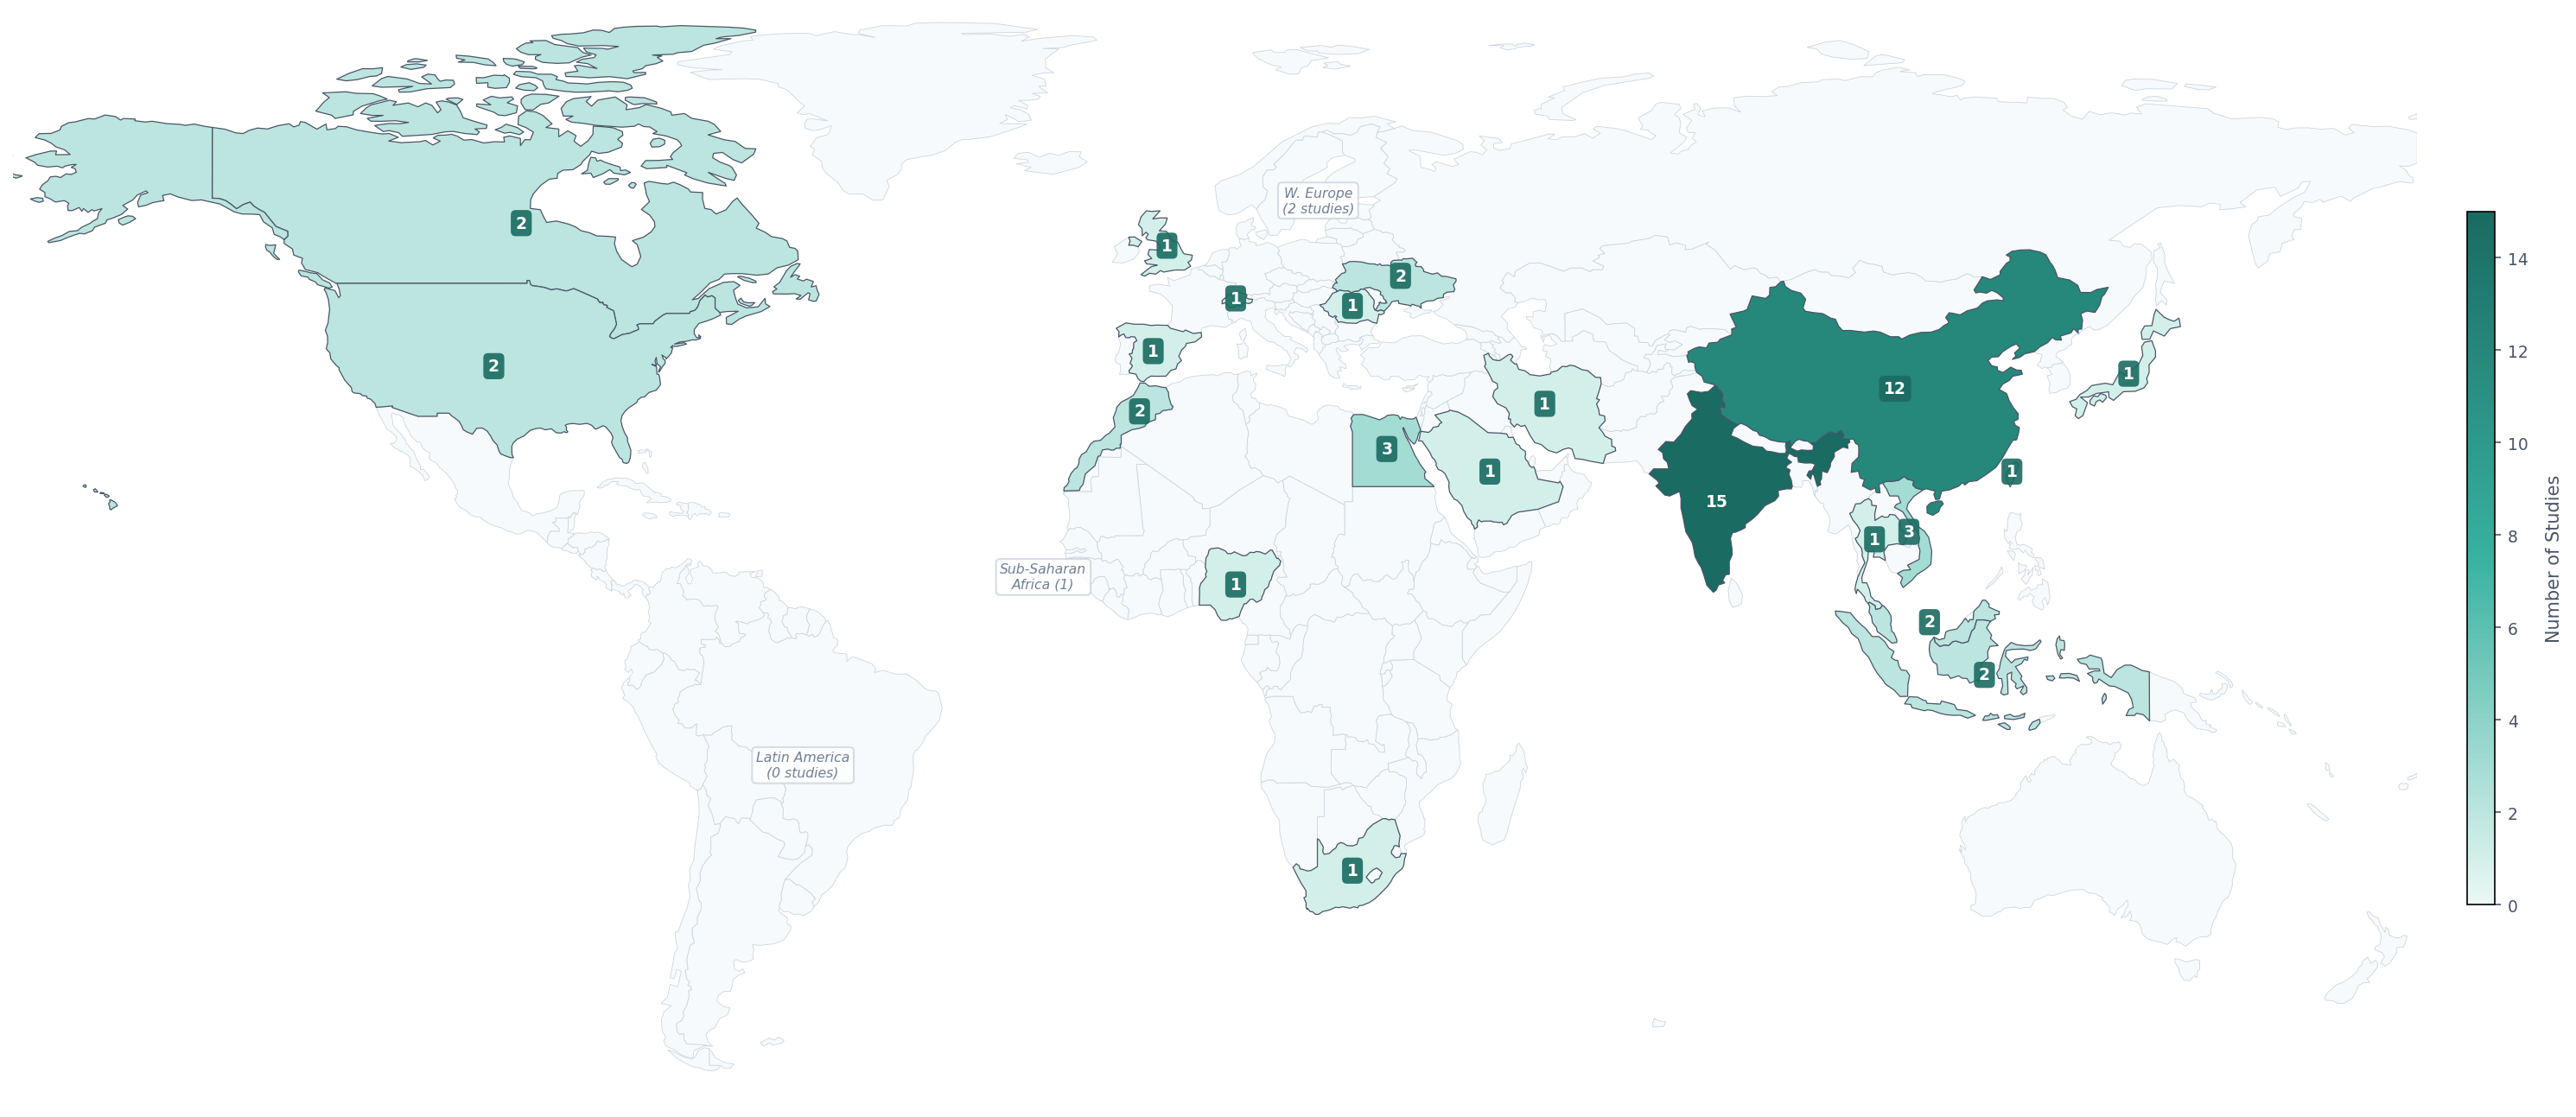

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F5A_Choropleth_Map.png


In [20]:
# [FIG-F5A] Choropleth Map — Geographic Distribution (standalone figure)

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# ── Map study counts onto world ────────────────────────────────────────
world['study_count'] = world['NAME'].map(country_counts_fixed).fillna(0)

map_cmap = LinearSegmentedColormap.from_list(
    'slr_map', ['#EBF8F5', '#38B2A0', '#1A6B62'], N=256
)

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 11), facecolor='white')
ax.set_facecolor('#F0F7FF')  # light blue ocean

# No-study countries
world[world['study_count'] == 0].plot(
    ax=ax, color='#F7FAFC', edgecolor='#CBD5E0', linewidth=0.4
)

# Countries with studies
world[world['study_count'] > 0].plot(
    ax=ax,
    column='study_count',
    cmap=map_cmap,
    edgecolor='#4A5568',
    linewidth=0.6,
    legend=False,
    vmin=0,
    vmax=world['study_count'].max(),
)

# ── Country count labels ───────────────────────────────────────────────
label_coords = {
    'India'                      : (78,   20),
    'China'                      : (104,  35),
    'Vietnam'                    : (106,  16),
    'Egypt'                      : (30,   27),
    'Ukraine'                    : (32,   50),
    'Morocco'                    : (-6,   32),
    'Indonesia'                  : (117,  -3),
    'Canada'                     : (-96,  57),
    'United States of America'   : (-100, 38),
    'Malaysia'                   : (109,   4),
    'Spain'                      : (-4,   40),
    'Saudi Arabia'               : (45,   24),
    'Taiwan'                     : (121,  24),
    'Romania'                    : (25,   46),
    'Japan'                      : (138,  37),
    'United Kingdom'             : (-2,   54),
    'South Africa'               : (25,  -29),
    'Nigeria'                    : (8,     9),
    'Iran'                       : (53,   33),
    'Switzerland'                : (8,    47),
    'Thailand'                   : (101,  15),
}

for country, (lx, ly) in label_coords.items():
    count = country_counts_fixed.get(country, 0)
    if count == 0:
        continue
    ax.annotate(
        str(count),
        xy=(lx, ly),
        fontsize=9,
        fontweight='bold',
        color='white',
        ha='center', va='center',
        zorder=5,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#1A6B62',
            edgecolor='none',
            alpha=0.90,
        )
    )

# ── Colorbar ───────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=map_cmap,
    norm=plt.Normalize(vmin=0, vmax=world['study_count'].max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax,
                    orientation='vertical',
                    fraction=0.018, pad=0.02,
                    shrink=0.5, aspect=25)
cbar.set_label('Number of Studies', fontsize=10, color='#4A5568', labelpad=10)
cbar.ax.tick_params(labelsize=9, colors='#4A5568')

# ── Regional absence annotations ──────────────────────────────────────
absence_labels = [
    (-55,  -15, 'Latin America\n(0 studies)'),
    (-20,   10, 'Sub-Saharan\nAfrica (1)'),
    (20,    60, 'W. Europe\n(2 studies)'),
]
for lx, ly, txt in absence_labels:
    ax.text(lx, ly, txt,
            fontsize=7.5, color='#718096',
            ha='center', va='center',
            style='italic',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='#CBD5E0',
                      alpha=0.8))

ax.set_xlim(-170, 180)
ax.set_ylim(-60, 85)
ax.axis('off')

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F5A_Choropleth_Map.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 15B — [FIG-F5B] Venue Quality Tier Chart

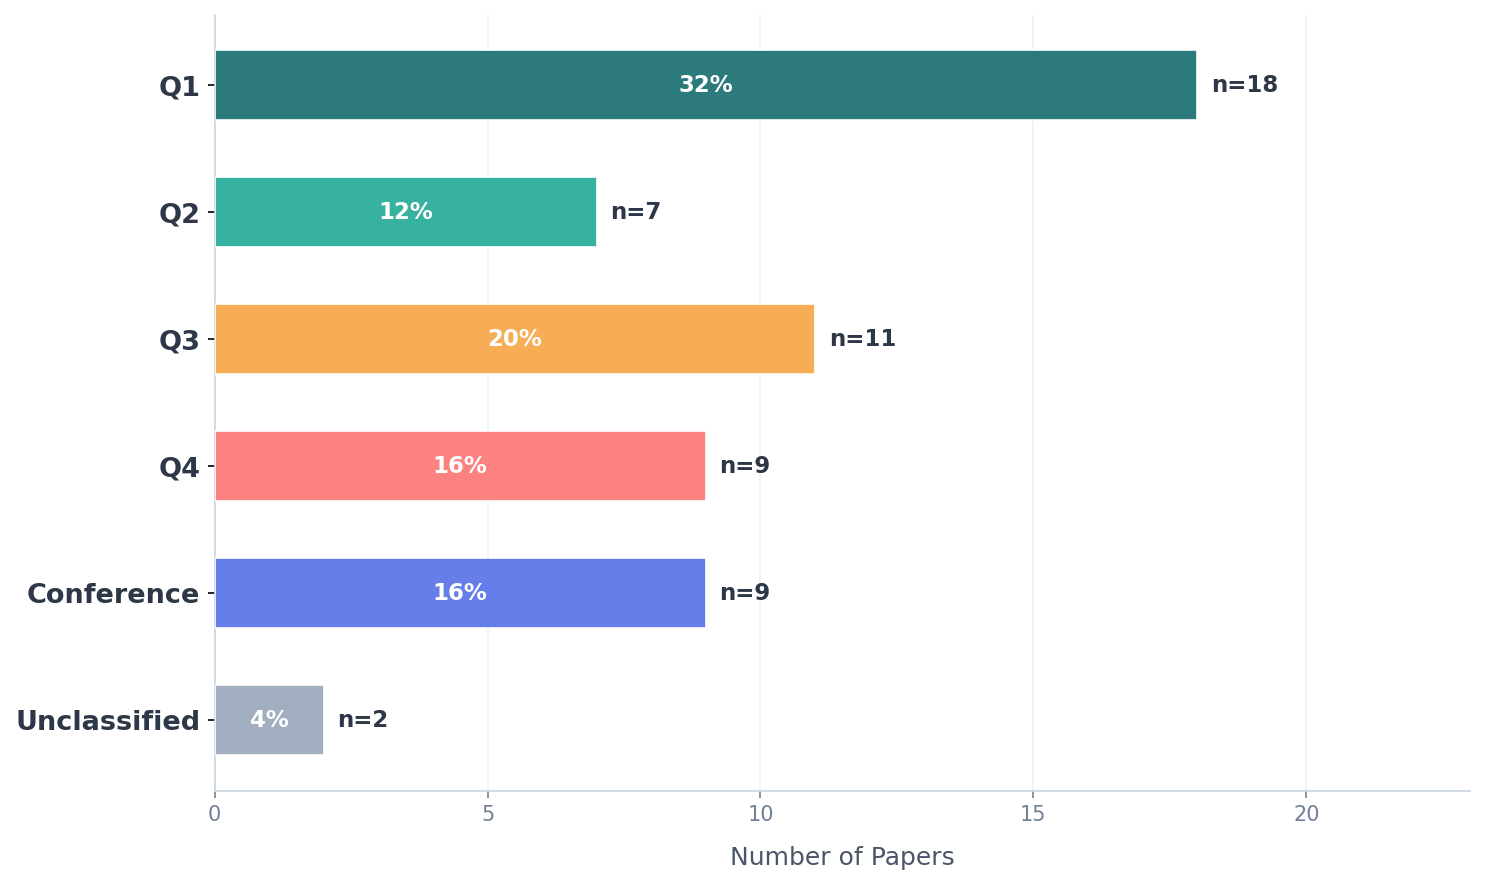

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F5B_Venue_Quality_Tier.png


In [22]:
# [FIG-F5B] Venue Quality Tier — standalone figure

import matplotlib.pyplot as plt
import numpy as np

tier_order  = ['Q1', 'Q2', 'Q3', 'Q4', 'Conference', 'Unclassified']
tier_counts = df['Venue_Tier'].value_counts()
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
tier_colors = ['#2C7A7B', '#38B2A0', '#F6AD55', '#FC8181', '#667EEA', '#A0AEC0']
total       = sum(tier_vals)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

y_pos = np.arange(len(tier_order))
bars  = ax.barh(y_pos, tier_vals,
                color=tier_colors,
                height=0.55,
                edgecolor='white',
                linewidth=0.8,
                zorder=3)

# Percentage inside bars
for bar, val in zip(bars, tier_vals):
    if val >= 2:
        pct = val / total * 100
        ax.text(bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{pct:.0f}%',
                va='center', ha='center',
                fontsize=11, fontweight='bold', color='white')

# Count labels outside bars
for bar, val in zip(bars, tier_vals):
    ax.text(bar.get_width() + 0.25,
            bar.get_y() + bar.get_height() / 2,
            f'n={val}',
            va='center', ha='left',
            fontsize=11, fontweight='bold', color='#2D3748')



ax.set_yticks(y_pos)
ax.set_yticklabels(tier_order, fontsize=13, color='#2D3748', fontweight='bold')
ax.set_xlabel('Number of Papers', fontsize=12, color='#4A5568', labelpad=10)
ax.set_xlim(0, max(tier_vals) + 5)
ax.tick_params(axis='x', colors='#718096', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E0')
ax.spines['bottom'].set_color('#CBD5E0')
ax.grid(axis='x', color='#EDF2F7', linewidth=0.8, zorder=0)
ax.invert_yaxis()

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F5B_Venue_Quality_Tier.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 16A — [AUDIT] Research Objectives & Task Types

In [23]:
# [AUDIT] Research objectives and task types before F6

print("=== Task Type unique values ===")
for i, row in df.iterrows():
    print(f"  {row['Study ID']:<25} {str(row['Task Type'])[:80]}")

=== Task Type unique values ===
  Hayashi 2024              Collaborative Learning Process Detection
  Liu 2021                  Not Reported
  Kumar 2022                Sentiment classification / Speech Emotion Recognition (SER)
  Kratzwald 2018            Emotion Classification
Emotion Regression
Affective Computing
  Sethi 2022                Engagement detection / FER (facial expression)
  Radharani 2026            Engagement detection / FER (facial expression)
  Al-Asadi 2024             EEG-based Emotion Recognition
  Kumar 2025                Multimodal affect / Emotion recognition
  Arsirii 2023              FER (facial expression recognition)
  Evangeline 2024           FER (facial expression) 
  Bandyopadhyay 2024        Facial Expression Recognition (FER) + Emotion-Based Recommendation
  Boopalan 2025             FER (facial expression recognition)     
  ElKabtane 2026            FER (facial expression) / Engagement detection
  Aly 2025                  FER (Facial Expressi

## CELL 16 — [FIG-F6] Chord Diagram: Research Objective × Architecture

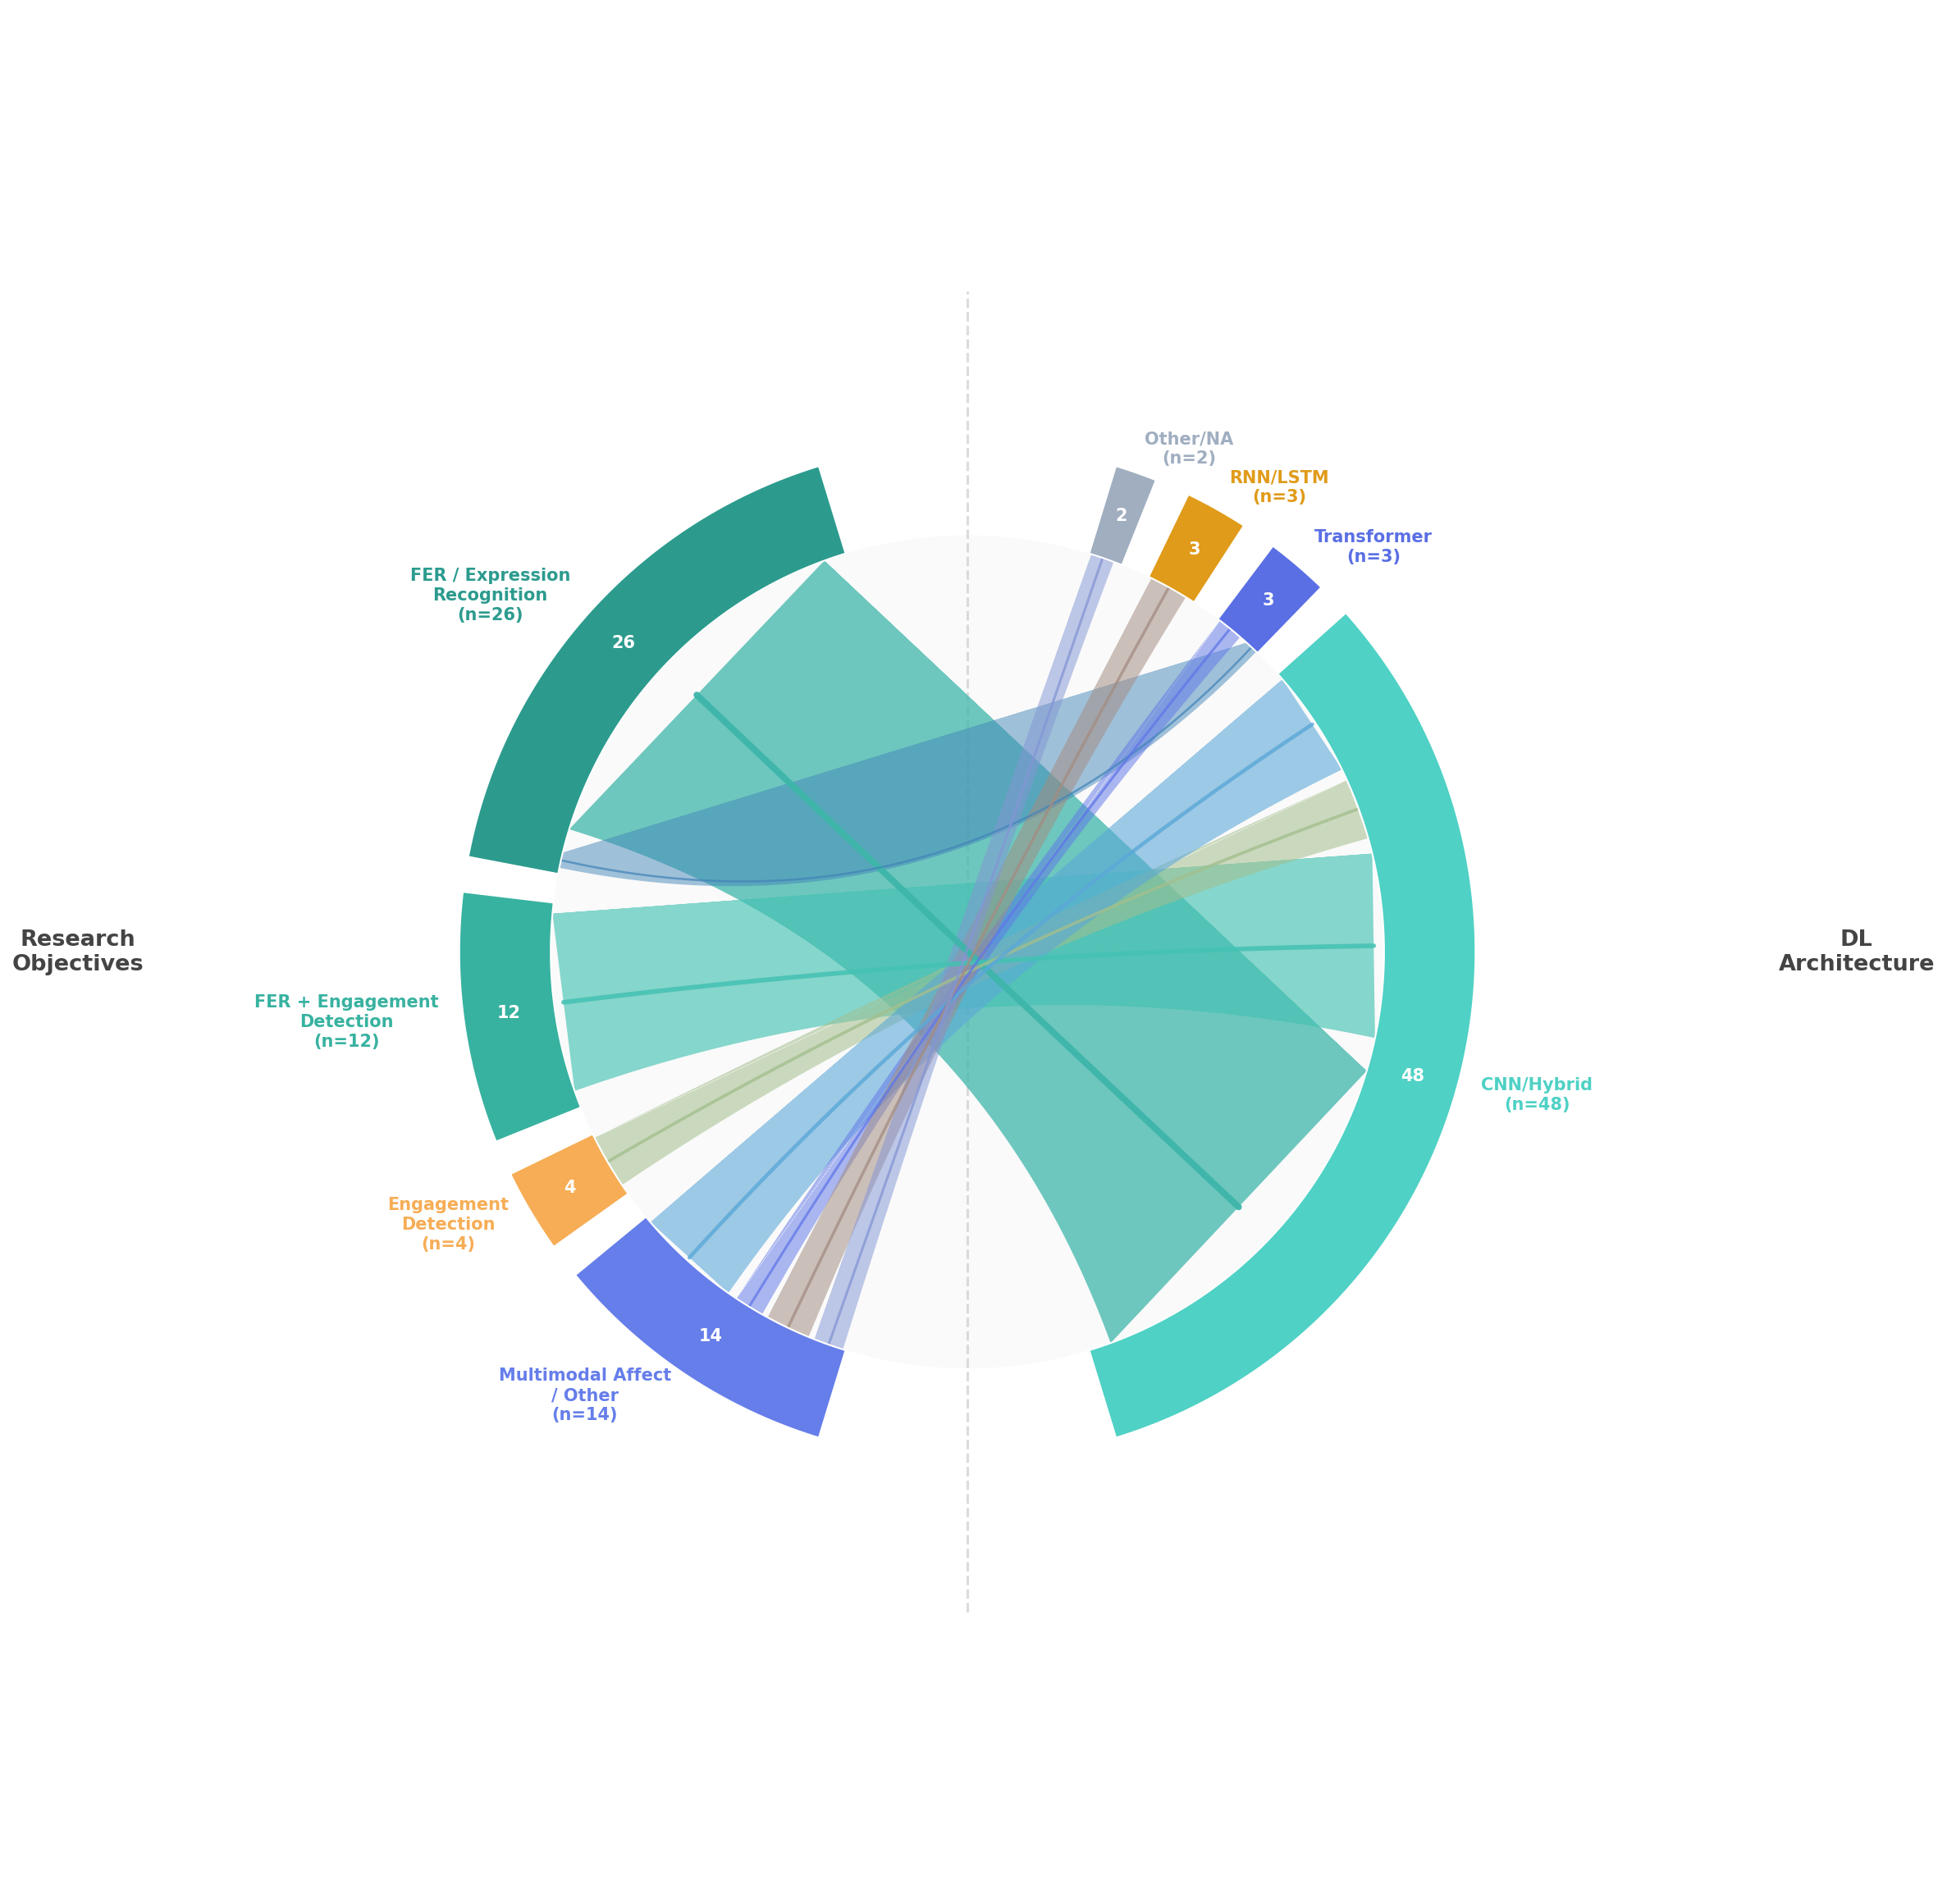

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F6_Chord_Diagram.png


In [28]:
# [FIG-F6] Chord Diagram — FINAL
# No border, no legend, fixed label overlapping

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import os

# ── Data ───────────────────────────────────────────────────────────────
TASKS = ['FER / Expression\nRecognition',
         'FER + Engagement\nDetection',
         'Engagement\nDetection',
         'Multimodal Affect\n/ Other']

ARCHS = ['CNN/Hybrid', 'Transformer', 'RNN/LSTM', 'Other/NA']

TASKS_clean = ['FER / Expression Recognition',
               'FER + Engagement Detection',
               'Engagement Detection',
               'Multimodal Affect / Other']

matrix_df = pd.crosstab(df['Task_clean'], df['Architecture_Family'])
for t in TASKS_clean:
    if t not in matrix_df.index: matrix_df.loc[t] = 0
for a in ARCHS:
    if a not in matrix_df.columns: matrix_df[a] = 0
matrix_df = matrix_df.loc[TASKS_clean, ARCHS]
matrix = matrix_df.values.astype(int)

task_totals = matrix.sum(axis=1)
arch_totals = matrix.sum(axis=0)

# ── Colors ─────────────────────────────────────────────────────────────
TASK_COLORS = ['#2C9B8E', '#38B2A0', '#F6AD55', '#667EEA']
ARCH_COLORS = ['#4FD1C5', '#5A6FE4', '#E09B1A', '#A0AEC0']

R_OUT = 1.00
R_IN  = 0.82
GAP   = 4.0

def build_arcs(counts, start_deg, end_deg):
    total  = counts.sum()
    span   = end_deg - start_deg
    usable = span - GAP * len(counts)
    arcs, cur = [], start_deg
    for c in counts:
        length = (c / total) * usable
        s = cur + GAP / 2
        e = s + length
        arcs.append(((s + e) / 2, s, e))
        cur = e + GAP / 2
    return arcs

task_arcs = build_arcs(task_totals, 105, 255)
arch_arcs = build_arcs(arch_totals, 285, 435)

def arc_poly(ax, s_deg, e_deg, r_in, r_out, color, zorder=4):
    th = np.linspace(np.radians(s_deg), np.radians(e_deg), 200)
    xs = np.concatenate([r_out * np.cos(th), r_in * np.cos(th[::-1])])
    ys = np.concatenate([r_out * np.sin(th), r_in * np.sin(th[::-1])])
    ax.add_patch(patches.Polygon(np.c_[xs, ys], closed=True,
                                  facecolor=color, edgecolor='white',
                                  linewidth=1.0, zorder=zorder))

def bezier_ribbon(ax, a1, a2, b1, b2, ca, cb, weight, max_w):
    if weight == 0:
        return
    ma = np.radians((a1 + a2) / 2)
    mb = np.radians((b1 + b2) / 2)
    da = np.radians((a2 - a1) / 2 * 0.9)
    db = np.radians((b2 - b1) / 2 * 0.9)
    pa1 = np.array([R_IN * np.cos(ma - da), R_IN * np.sin(ma - da)])
    pa2 = np.array([R_IN * np.cos(ma + da), R_IN * np.sin(ma + da)])
    pb1 = np.array([R_IN * np.cos(mb - db), R_IN * np.sin(mb - db)])
    pb2 = np.array([R_IN * np.cos(mb + db), R_IN * np.sin(mb + db)])

    def bez(p0, cp, p1, n=150):
        t = np.linspace(0, 1, n)
        return (np.outer((1-t)**2, p0) +
                np.outer(2*(1-t)*t,  cp) +
                np.outer(t**2,       p1))

    cp    = np.array([0., 0.])
    blend = (np.array(to_rgba(ca)) + np.array(to_rgba(cb))) / 2
    frac  = (weight / max_w) ** 0.6
    blend[3] = 0.45 + 0.3 * frac

    poly_pts = np.vstack([pa1, bez(pa2, cp, pb1),
                           pb2, bez(pb2, cp, pa1)[::-1]])
    ax.add_patch(patches.Polygon(poly_pts, closed=True,
                                  facecolor=blend, edgecolor='none',
                                  zorder=2, alpha=float(blend[3])))
    cl       = bez((pa1 + pa2) / 2, cp, (pb1 + pb2) / 2)
    col_l    = blend.copy()
    col_l[3] = min(0.7 + 0.25 * frac, 1.0)
    ax.plot(cl[:, 0], cl[:, 1], color=col_l,
            linewidth=0.8 + frac * 3.0, zorder=3,
            solid_capstyle='round')

def subdivide(s, e, weights):
    total  = sum(weights)
    if total == 0:
        return [((s + e) / 2, s, e)] * len(weights)
    usable = (e - s) - 0.3 * len(weights)
    subs, cur = [], s
    for w in weights:
        l  = (w / total) * usable
        sm = cur + 0.15
        em = sm + l
        subs.append(((sm + em) / 2, sm, em))
        cur = em + 0.15
    return subs

task_sub = [subdivide(task_arcs[i][1], task_arcs[i][2], matrix[i])
            for i in range(len(TASKS))]
arch_sub = [subdivide(arch_arcs[j][1], arch_arcs[j][2], matrix[:, j])
            for j in range(len(ARCHS))]

# ── Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 16), dpi=150)
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.85, 1.85)
ax.set_ylim(-1.85, 1.85)
fig.patch.set_facecolor('white')

ax.add_patch(plt.Circle((0, 0), R_IN, facecolor='#FAFAFA',
                          edgecolor='none', zorder=0))

# ── Arc segments + labels ──────────────────────────────────────────────
# Task labels pushed further out, no rotation overlap
LABEL_R_TASK = 1.05
LABEL_R_ARCH = 1.05

for i, (mid, s, e) in enumerate(task_arcs):
    arc_poly(ax, s, e, R_IN, R_OUT, TASK_COLORS[i])
    # count inside arc
    mr = np.radians(mid)
    ax.text((R_IN + R_OUT) / 2 * np.cos(mr),
            (R_IN + R_OUT) / 2 * np.sin(mr),
            str(task_totals[i]),
            ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', zorder=6)
    # label — always horizontal, pushed outward
    angle = mid % 360
    m     = np.radians(angle)
    lx    = LABEL_R_TASK * np.cos(m)
    ly    = LABEL_R_TASK * np.sin(m)
    ha    = 'right' if lx < 0 else 'left'
    ax.text(lx, ly,
            TASKS[i] + f'\n(n={task_totals[i]})',
            ha=ha, va='center',
            fontsize=10, fontweight='bold',
            color=TASK_COLORS[i],
            multialignment='center',
            linespacing=1.25)

for j, (mid, s, e) in enumerate(arch_arcs):
    arc_poly(ax, s, e, R_IN, R_OUT, ARCH_COLORS[j])
    mr = np.radians(mid)
    ax.text((R_IN + R_OUT) / 2 * np.cos(mr),
            (R_IN + R_OUT) / 2 * np.sin(mr),
            str(arch_totals[j]),
            ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', zorder=6)
    angle = mid % 360
    m     = np.radians(angle)
    lx    = LABEL_R_ARCH * np.cos(m)
    ly    = LABEL_R_ARCH * np.sin(m)
    ha    = 'right' if lx < 0 else 'left'
    ax.text(lx, ly,
            ARCHS[j] + f'\n(n={arch_totals[j]})',
            ha=ha, va='center',
            fontsize=10, fontweight='bold',
            color=ARCH_COLORS[j],
            multialignment='center',
            linespacing=1.25)

# ── Ribbons ────────────────────────────────────────────────────────────
max_w = matrix.max()
for i in range(len(TASKS)):
    for j in range(len(ARCHS)):
        w = matrix[i, j]
        if w == 0:
            continue
        _, a1, a2 = task_sub[i][j]
        _, b1, b2 = arch_sub[j][i]
        bezier_ribbon(ax, a1, a2, b1, b2,
                      TASK_COLORS[i], ARCH_COLORS[j], w, max_w)

# ── Divider + section titles ───────────────────────────────────────────
ax.plot([0, 0], [-1.3, 1.3], color='#bbbbbb',
        lw=1.5, ls='--', zorder=1, alpha=0.5)
ax.text(-1.75, 0.0, 'Research\nObjectives',
        ha='center', va='center', fontsize=13,
        fontweight='bold', color='#444444',
        multialignment='center')
ax.text(1.75, 0.0, 'DL\nArchitecture',
        ha='center', va='center', fontsize=13,
        fontweight='bold', color='#444444',
        multialignment='center')

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F6_Chord_Diagram.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 17A — [AUDIT] Dataset & Accuracy Data

In [29]:
# [AUDIT] Dataset names and accuracy before F7

print("=== Dataset Name + Architecture + Accuracy ===")
for _, row in df.iterrows():
    print(f"  {row['Study ID']:<25} "
          f"| {row['Architecture_Family']:<12} "
          f"| Dataset: {str(row['Dataset Name(s)'])[:50]:<50} "
          f"| Acc: {str(row['Accuracy (%)'])[:20]}")

=== Dataset Name + Architecture + Accuracy ===
  Hayashi 2024              | Other/NA     | Dataset: No external dataset used.

Custom experimental mul | Acc: Not applicable.
  Liu 2021                  | CNN/Hybrid   | Dataset: Oulu-CASIA NIR Database
CK+ (Extended Cohn-Kanade  | Acc: Method	Accuracy
LBP-
  Kumar 2022                | Transformer  | Dataset: RAVDESS, TIMIT Corpus, Emo-DB                      | Acc: RAVDESS: 81.02%; TIM
  Kratzwald 2018            | RNN/LSTM     | Dataset: Alm (2008) Literary Tales
Election Tweets Dataset
 | Acc: Not reported as prim
  Sethi 2022                | CNN/Hybrid   | Dataset: Custom (Shoolini University Student Facial Dataset | Acc: Yes (Test Accuracy: 
  Radharani 2026            | CNN/Hybrid   | Dataset: Spontaneous Classroom Expressions Dataset (Custom) | Acc: Yes (Custom dataset:
  Al-Asadi 2024             | CNN/Hybrid   | Dataset: DEAP (Database for Emotion Analysis using Physiolo | Acc: 86.67%
  Kumar 2025                | CNN/Hybrid 

## CELL 17 — [FIG-F7] Performance Heatmap: Dataset × Architecture → Accuracy

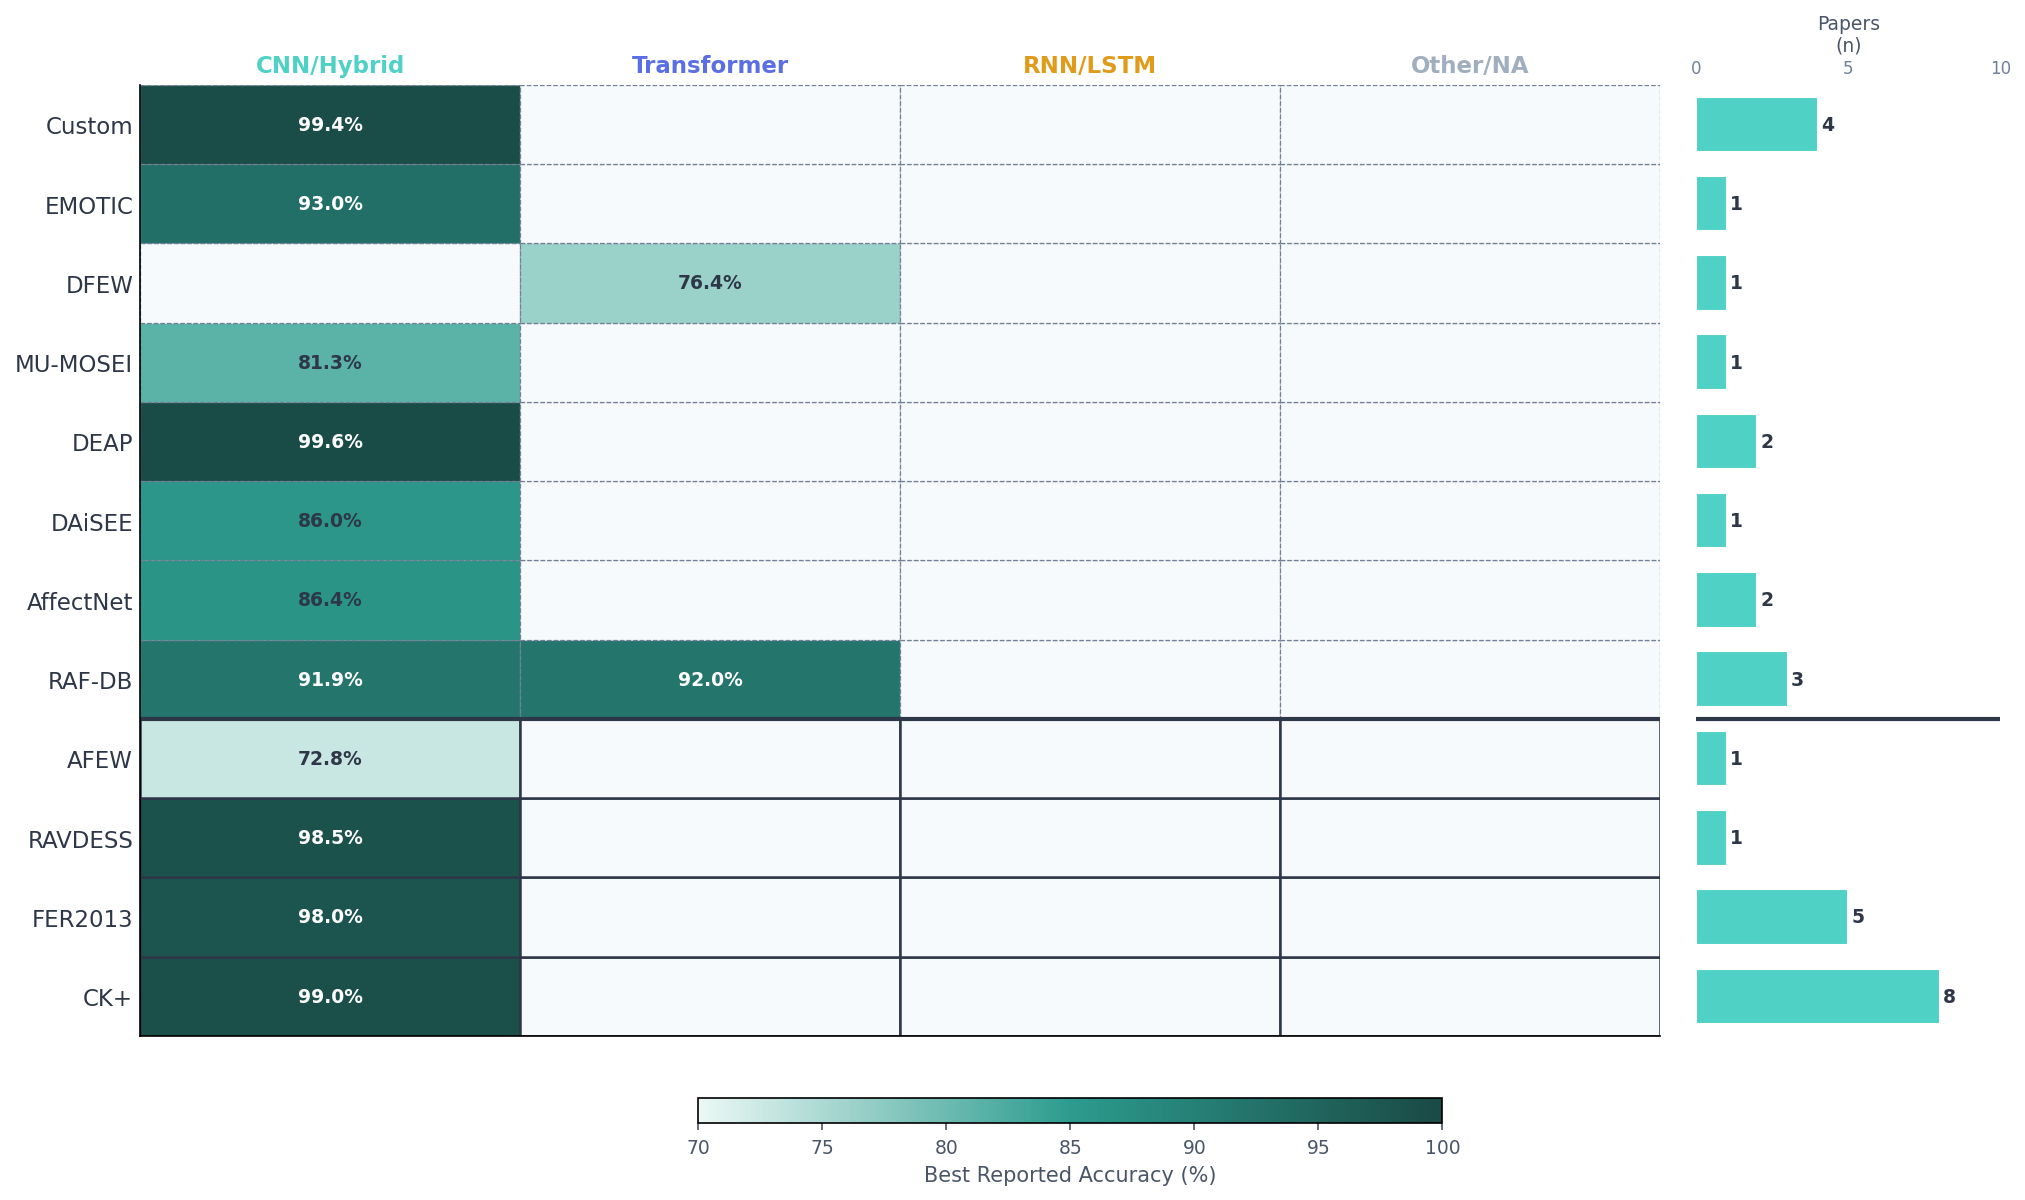

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F7_Performance_Heatmap.png


In [31]:
# [FIG-F7] Performance Heatmap — Dataset × Architecture → Accuracy

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ── Manual extraction of best accuracy per paper ───────────────────────
# Only papers with clearly reported numeric accuracy included
# Dataset mapped to canonical name

paper_data = [
    # study_id, canonical_dataset, architecture, best_accuracy, dataset_type
    # dataset_type: 'Acted' or 'Naturalistic'
    ('Al-Asadi 2024',        'DEAP',         'CNN/Hybrid',  86.67, 'Naturalistic'),
    ('Kumar 2025',           'MU-MOSEI',     'CNN/Hybrid',  81.3,  'Naturalistic'),
    ('Bandyopadhyay 2024',   'FER2013',      'CNN/Hybrid',  75.0,  'Acted'),
    ('Boopalan 2025',        'CK+',          'CNN/Hybrid',  96.72, 'Acted'),
    ('Aly 2025',             'RAF-DB',       'CNN/Hybrid',  91.86, 'Naturalistic'),
    ('Bashir 2025',          'FER2013',      'CNN/Hybrid',  98.0,  'Acted'),
    ('Manu 2026',            'AffectNet',    'CNN/Hybrid',  86.4,  'Naturalistic'),
    ('Benisha 2023',         'CK+',          'CNN/Hybrid',  98.49, 'Acted'),
    ('Asaju 2022',           'DAiSEE',       'CNN/Hybrid',  86.0,  'Naturalistic'),
    ('Banerjee 2026',        'AffectNet',    'CNN/Hybrid',  74.77, 'Naturalistic'),
    ('Bala 2023',            'FER2013',      'CNN/Hybrid',  94.44, 'Acted'),
    ('Mohana 2025',          'CK+',          'CNN/Hybrid',  98.98, 'Acted'),
    ('Gupta 2023',           'FER2013',      'CNN/Hybrid',  92.58, 'Acted'),
    ('Wang 2025',            'RAF-DB',       'Transformer', 92.0,  'Naturalistic'),
    ('IEEE 2025',            'EMOTIC',       'CNN/Hybrid',  93.0,  'Naturalistic'),
    ('Zhang 2024',           'Custom',       'CNN/Hybrid',  85.6,  'Naturalistic'),
    ('Moise 2024',           'DEAP',         'CNN/Hybrid',  99.64, 'Naturalistic'),
    ('Jagadeesh 2022',       'Custom',       'CNN/Hybrid',  92.3,  'Naturalistic'),
    ('Mai 2022',             'AFEW',         'CNN/Hybrid',  72.76, 'Naturalistic'),
    ('Almogren 2026',        'RAVDESS',      'CNN/Hybrid',  98.5,  'Acted'),
    ('Aly 2023',             'RAF-DB',       'CNN/Hybrid',  87.62, 'Naturalistic'),
    ('Lawpanom 2024',        'FER2013',      'CNN/Hybrid',  75.15, 'Acted'),
    ('Long 2022',            'CK+',          'CNN/Hybrid',  97.0,  'Acted'),
    ('Long 2021',            'CK+',          'CNN/Hybrid',  96.5,  'Acted'),
    ('Long 2023',            'CK+',          'CNN/Hybrid',  97.2,  'Acted'),
    ('Maddu 2024',           'CK+',          'CNN/Hybrid',  95.0,  'Acted'),
    ('Li 2025',              'CK+',          'CNN/Hybrid',  90.0,  'Acted'),
    ('Liu 2025',             'DFEW',         'Transformer', 76.43, 'Naturalistic'),
    ('IEEEComputerSociety 2021', 'Custom',   'CNN/Hybrid',  99.37, 'Naturalistic'),
    ('Feng 2020',            'Custom',       'CNN/Hybrid',  88.62, 'Naturalistic'),
]

perf_df = pd.DataFrame(paper_data,
    columns=['study_id', 'Dataset', 'Architecture', 'Accuracy', 'DatasetType'])

# ── Canonical dataset order ────────────────────────────────────────────
# Acted first (solid border), Naturalistic second (dashed border)
DATASETS = ['CK+', 'FER2013', 'RAVDESS', 'AFEW',       # Acted
            'RAF-DB', 'AffectNet', 'DAiSEE', 'DEAP',
            'MU-MOSEI', 'DFEW', 'EMOTIC', 'Custom']    # Naturalistic
ACTED     = {'CK+', 'FER2013', 'RAVDESS', 'AFEW'}

ARCH_ORDER = ['CNN/Hybrid', 'Transformer', 'RNN/LSTM', 'Other/NA']
ARCH_COLORS_MAP = {
    'CNN/Hybrid'  : '#4FD1C5',
    'Transformer' : '#5A6FE4',
    'RNN/LSTM'    : '#E09B1A',
    'Other/NA'    : '#A0AEC0',
}

# Build heatmap matrix — best accuracy per (dataset, arch)
heat = pd.DataFrame(index=DATASETS, columns=ARCH_ORDER, dtype=float)
heat[:] = np.nan
count_mat = pd.DataFrame(index=DATASETS, columns=ARCH_ORDER, dtype=float)
count_mat[:] = np.nan

for _, row in perf_df.iterrows():
    d, a, acc = row['Dataset'], row['Architecture'], row['Accuracy']
    if d in heat.index and a in heat.columns:
        if np.isnan(heat.loc[d, a]) or acc > heat.loc[d, a]:
            heat.loc[d, a] = acc
        count_mat.loc[d, a] = (count_mat.loc[d, a] or 0) + 1 \
            if not np.isnan(count_mat.loc[d, a]) else 1

# Paper count per dataset
dataset_paper_count = perf_df.groupby('Dataset').size().reindex(DATASETS, fill_value=0)

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2,
    figsize=(16, 9),
    gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.04},
    facecolor='white')

ax   = axes[0]
ax_n = axes[1]
ax.set_facecolor('white')
ax_n.set_facecolor('white')

heat_vals = heat[ARCH_ORDER].values.astype(float)

# Custom colormap: white → teal
from matplotlib.colors import LinearSegmentedColormap
hm_cmap = LinearSegmentedColormap.from_list(
    'hm', ['#EBF8F5', '#2C9B8E', '#1A4A45'], N=256)

# Draw cells manually for full control
nrows, ncols = len(DATASETS), len(ARCH_ORDER)
vmin, vmax   = 70, 100

for r, dataset in enumerate(DATASETS):
    for c, arch in enumerate(ARCH_ORDER):
        val = heat_vals[r, c]
        if np.isnan(val):
            color = '#F7FAFC'
            txt   = '—'
        else:
            norm  = (val - vmin) / (vmax - vmin)
            color = hm_cmap(norm)
            txt   = f'{val:.1f}%'

        # Cell rectangle
        is_acted = dataset in ACTED
        edge_col = '#2D3748' if is_acted else '#718096'
        edge_lw  = 1.2       if is_acted else 0.6
        ls       = '-'       if is_acted else '--'

        rect = plt.Rectangle([c, r], 1, 1,
                              facecolor=color,
                              edgecolor=edge_col,
                              linewidth=edge_lw,
                              linestyle=ls)
        ax.add_patch(rect)

        if not np.isnan(val):
            txt_color = 'white' if (val - vmin)/(vmax-vmin) > 0.55 else '#2D3748'
            ax.text(c + 0.5, r + 0.5, txt,
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color=txt_color)

# ── Axes formatting ────────────────────────────────────────────────────
ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)
ax.set_xticks(np.arange(ncols) + 0.5)
ax.set_xticklabels(ARCH_ORDER, fontsize=11, fontweight='bold', color='#2D3748')
ax.set_yticks(np.arange(nrows) + 0.5)
ax.set_yticklabels(DATASETS, fontsize=11, color='#2D3748')
ax.tick_params(length=0)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Color x-tick labels by architecture
for tick, arch in zip(ax.get_xticklabels(), ARCH_ORDER):
    tick.set_color(ARCH_COLORS_MAP[arch])

# Divider line between Acted and Naturalistic
divider_y = len(ACTED)
ax.axhline(divider_y, color='#2D3748', linewidth=2.0, linestyle='-')
ax.text(ncols + 0.1, divider_y + (nrows - divider_y)/2,
        'Naturalistic /\nSpontaneous',
        ha='left', va='center', fontsize=9,
        color='#718096', style='italic',
        rotation=90)
ax.text(ncols + 0.1, divider_y/2,
        'Acted /\nLab',
        ha='left', va='center', fontsize=9,
        color='#2D3748', style='italic',
        rotation=90)

# ── Right panel: paper count per dataset ──────────────────────────────
ax_n.set_facecolor('white')
counts = [dataset_paper_count.get(d, 0) for d in DATASETS]
y_pos  = np.arange(nrows) + 0.5

bars = ax_n.barh(y_pos, counts,
                 height=0.7,
                 color='#4FD1C5',
                 edgecolor='white')
for bar, val in zip(bars, counts):
    if val > 0:
        ax_n.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                  str(int(val)),
                  va='center', ha='left', fontsize=9,
                  color='#2D3748', fontweight='bold')

ax_n.set_xlim(0, max(counts) + 2)
ax_n.set_ylim(0, nrows)
ax_n.set_yticks([])
ax_n.set_xticks([0, 5, 10])
ax_n.set_xlabel('Papers\n(n)', fontsize=9, color='#4A5568')
ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_ticks_position('top')
ax_n.tick_params(labelsize=8, colors='#718096', length=0)
ax_n.spines['top'].set_visible(False)
ax_n.spines['right'].set_visible(False)
ax_n.spines['left'].set_visible(False)
ax_n.spines['bottom'].set_visible(False)
ax_n.axhline(divider_y, color='#2D3748', linewidth=2.0)

# ── Colorbar ───────────────────────────────────────────────────────────
import matplotlib.cm as cm
sm = plt.cm.ScalarMappable(cmap=hm_cmap,
                            norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes,
                    orientation='horizontal',
                    fraction=0.025, pad=0.06,
                    shrink=0.4, aspect=30)
cbar.set_label('Best Reported Accuracy (%)', fontsize=10, color='#4A5568')
cbar.ax.tick_params(labelsize=9, colors='#4A5568')

# ── Legend: border style ───────────────────────────────────────────────
solid_patch = mpatches.Patch(facecolor='white', edgecolor='#2D3748',
                              linewidth=1.5, label='Acted / Lab dataset')
dash_patch  = mpatches.Patch(facecolor='white', edgecolor='#718096',
                              linewidth=1.0,
                              linestyle='--',
                              label='Naturalistic / Spontaneous dataset')


plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F7_Performance_Heatmap.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 18A — [AUDIT] Reproducibility Scores

In [32]:
# [AUDIT] Reproducibility scores before F8A

score_map = {'Yes': 2, 'Partial': 1, 'No': 0, 'Not Reported': 0}

df['Repro_score'] = df['Reproducibility_clean'].map(score_map)

print("Reproducibility distribution by Architecture:")
print(pd.crosstab(df['Architecture_Family'], df['Reproducibility_clean']))
print()
print("Individual paper scores (ordered by architecture):")
for arch in ['CNN/Hybrid', 'RNN/LSTM', 'Transformer', 'Other/NA']:
    mask = df['Architecture_Family'] == arch
    subset = df[mask][['Study ID', 'Reproducibility_clean', 'Repro_score']]
    print(f"\n── {arch} ({mask.sum()} papers) ──")
    for _, row in subset.iterrows():
        print(f"  {row['Study ID']:<25} {row['Reproducibility_clean']:<15} score={row['Repro_score']}")

Reproducibility distribution by Architecture:
Reproducibility_clean  No  Partial  Yes
Architecture_Family                    
CNN/Hybrid              3       43    2
Other/NA                0        1    1
RNN/LSTM                0        3    0
Transformer             0        1    2

Individual paper scores (ordered by architecture):

── CNN/Hybrid (48 papers) ──
  Liu 2021                  Partial         score=1
  Sethi 2022                Partial         score=1
  Radharani 2026            Partial         score=1
  Al-Asadi 2024             Partial         score=1
  Kumar 2025                Partial         score=1
  Arsirii 2023              Partial         score=1
  Evangeline 2024           Partial         score=1
  Bandyopadhyay 2024        Partial         score=1
  Boopalan 2025             Partial         score=1
  ElKabtane 2026            Partial         score=1
  Aly 2025                  Partial         score=1
  Arsirii 2023              Partial         score=1
  Bashir

## CELL 18 — [FIG-F8A] Reproducibility Crisis Bar Chart

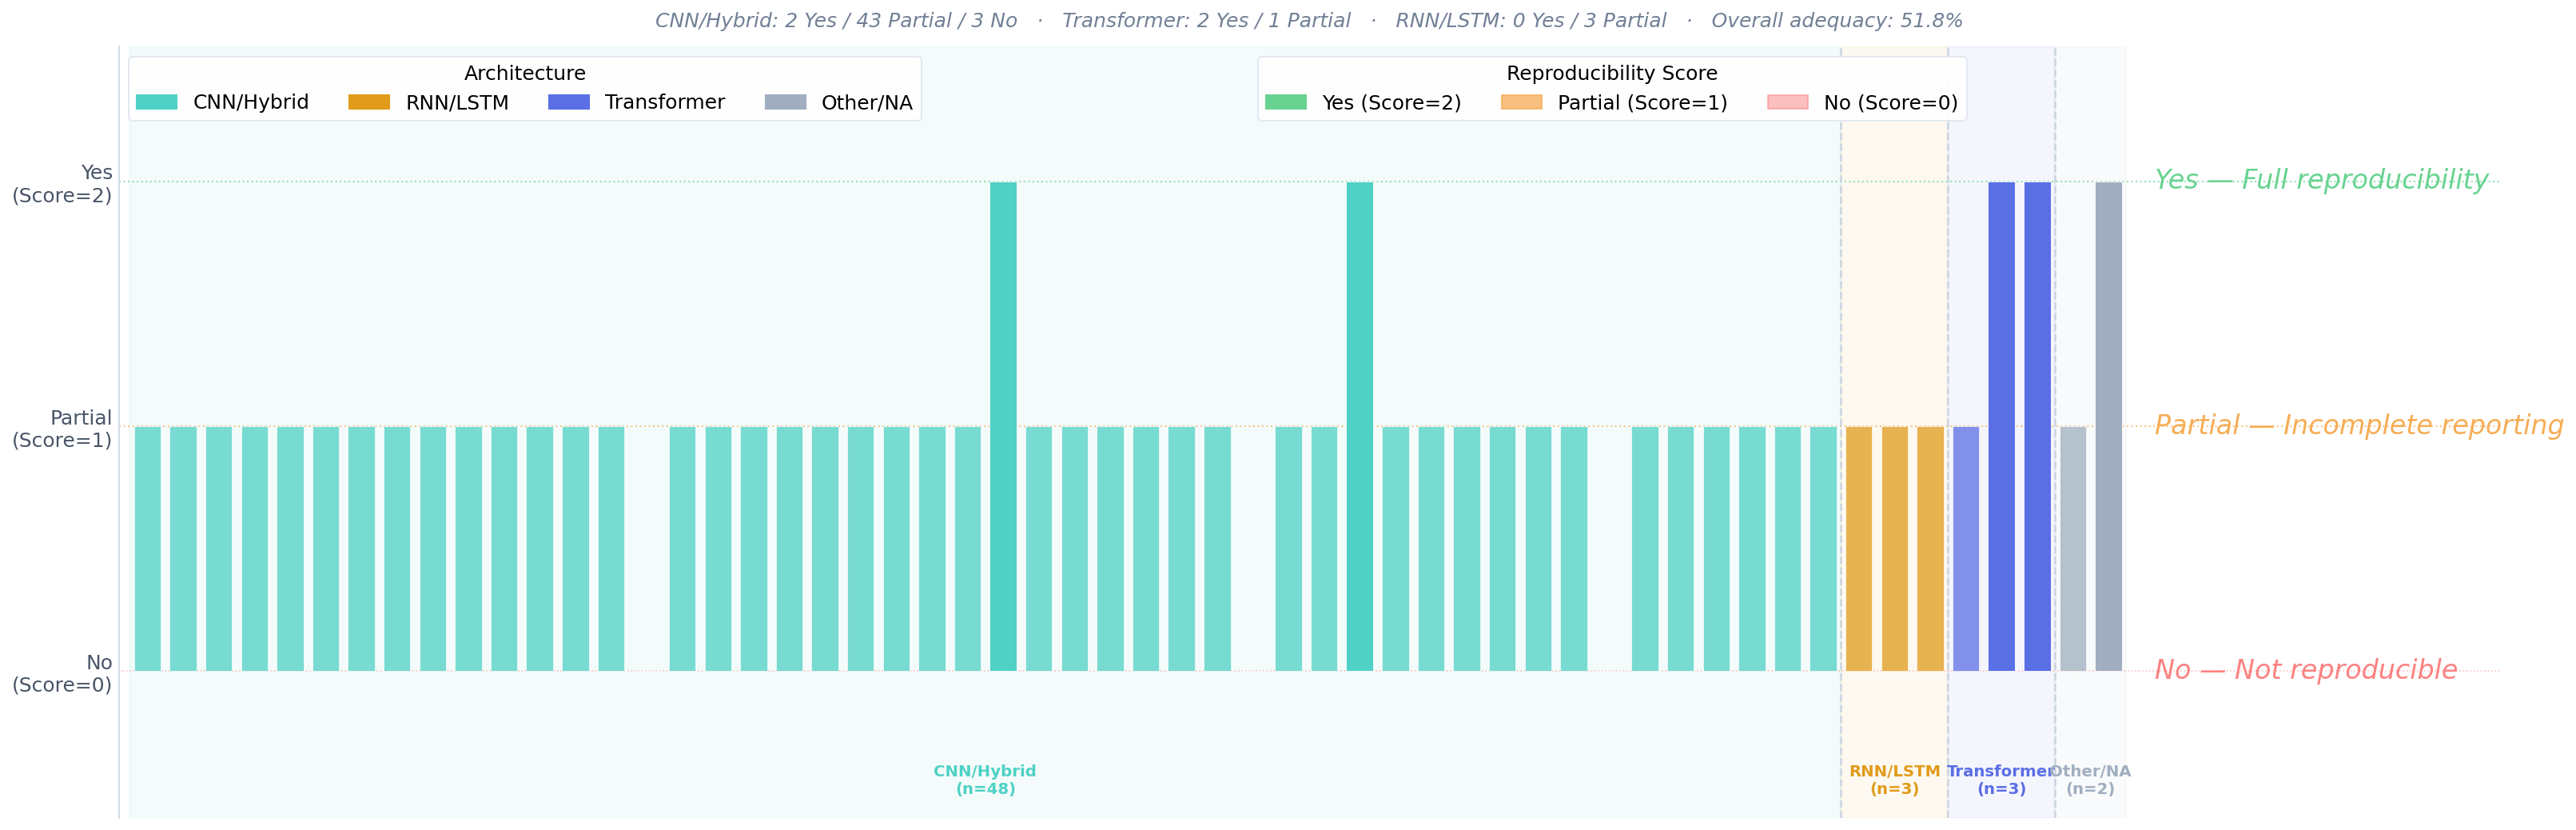

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F8A_Reproducibility_Bar.png


In [38]:
# [FIG-F8A] Reproducibility Crisis Bar Chart
# 56 individual papers on X-axis ordered by architecture family
# Y-axis = reproducibility score (2/1/0), colored by architecture

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Order papers by architecture family ────────────────────────────────
arch_order  = ['CNN/Hybrid', 'RNN/LSTM', 'Transformer', 'Other/NA']
df_sorted   = pd.concat([
    df[df['Architecture_Family'] == a] for a in arch_order
]).reset_index(drop=True)

scores      = df_sorted['Repro_score'].values
arch_labels = df_sorted['Architecture_Family'].values
study_ids   = df_sorted['Study ID'].values
repro_clean = df_sorted['Reproducibility_clean'].values

ARCH_COLORS = {
    'CNN/Hybrid'  : '#4FD1C5',
    'RNN/LSTM'    : '#E09B1A',
    'Transformer' : '#5A6FE4',
    'Other/NA'    : '#A0AEC0',
}
SCORE_ALPHA = {2: 1.0, 1: 0.75, 0: 0.5}

bar_colors = [ARCH_COLORS[a] for a in arch_labels]
bar_alphas = [SCORE_ALPHA[s] for s in scores]

# ── Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 7), facecolor='white')
ax.set_facecolor('white')

x = np.arange(len(df_sorted))

for i, (score, color, alpha) in enumerate(zip(scores, bar_colors, bar_alphas)):
    ax.bar(i, score, width=0.75,
           color=color, alpha=alpha,
           edgecolor='white', linewidth=0.4,
           zorder=3)

# ── Architecture family separators & labels ────────────────────────────
boundaries = []
for arch in arch_order:
    idxs = [i for i, a in enumerate(arch_labels) if a == arch]
    if idxs:
        boundaries.append((min(idxs), max(idxs), arch))

for start, end, arch in boundaries:
    # Shaded background
    ax.axvspan(start - 0.5, end + 0.5,
               alpha=0.06, color=ARCH_COLORS[arch], zorder=0)
    # Family label below x-axis
    mid = (start + end) / 2
    ax.text(mid, -0.38,
            f'{arch}\n(n={end - start + 1})',
            ha='center', va='top',
            fontsize=9.5, fontweight='bold',
            color=ARCH_COLORS[arch])
    # Vertical separator
    if start > 0:
        ax.axvline(start - 0.5, color='#CBD5E0',
                   linewidth=1.2, linestyle='--', zorder=2)

# ── Horizontal reference lines ─────────────────────────────────────────
ax.axhline(2, color='#68D391', linewidth=1.0,
           linestyle=':', alpha=0.7, zorder=1)
ax.axhline(1, color='#F6AD55', linewidth=1.0,
           linestyle=':', alpha=0.7, zorder=1)
ax.axhline(0, color='#FC8181', linewidth=0.8,
           linestyle=':', alpha=0.5, zorder=1)

# ── Y-axis ─────────────────────────────────────────────────────────────
ax.set_ylim(-0.6, 2.55)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['No\n(Score=0)', 'Partial\n(Score=1)', 'Yes\n(Score=2)'],
                   fontsize=12, color='#2D3748')

# Score level labels on right
for score_val, label, color in [
    (2, 'Yes — Full reproducibility', '#68D391'),
    (1, 'Partial — Incomplete reporting', '#F6AD55'),
    (0, 'No — Not reproducible', '#FC8181'),
]:
    ax.text(len(df_sorted) + 0.3, score_val, label,
            va='center', ha='left',
            fontsize=16, color=color, style='italic')

# ── X-axis ─────────────────────────────────────────────────────────────
ax.set_xlim(-0.8, len(df_sorted) + 10)
ax.set_xticks([])
ax.set_xlabel('')

# ── Spines ─────────────────────────────────────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#CBD5E0')
ax.tick_params(axis='y', colors='#4A5568', length=0)

# ── Key statistics annotation ──────────────────────────────────────────
stats_txt = (
    'CNN/Hybrid: 2 Yes / 43 Partial / 3 No   '
    '·   Transformer: 2 Yes / 1 Partial   '
    '·   RNN/LSTM: 0 Yes / 3 Partial   '
    '·   Overall adequacy: 51.8%'
)
ax.text(0.5, 1.02, stats_txt,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=12, color='#718096',
        style='italic')

# ── Legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=ARCH_COLORS[a], label=a)
    for a in arch_order
]
score_patches = [
    mpatches.Patch(color='#68D391', label='Yes (Score=2)'),
    mpatches.Patch(color='#F6AD55', label='Partial (Score=1)', alpha=0.75),
    mpatches.Patch(color='#FC8181', label='No (Score=0)', alpha=0.5),
]
leg1 = ax.legend(handles=legend_patches,
                 loc='upper left', bbox_to_anchor=(0.0, 1.0),
                 fontsize=12, title='Architecture',
                 title_fontsize=12,
                 frameon=True, framealpha=0.95,
                 edgecolor='#E2E8F0', ncol=4)
ax.add_artist(leg1)
ax.legend(handles=score_patches,
          loc='upper right', bbox_to_anchor=(0.78, 1.0),
          fontsize=12, title='Reproducibility Score',
          title_fontsize=12,
          frameon=True, framealpha=0.95,
          edgecolor='#E2E8F0', ncol=3)

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F8A_Reproducibility_Bar.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 19 — [FIG-F8B] Radar Chart: Current vs Ideal State


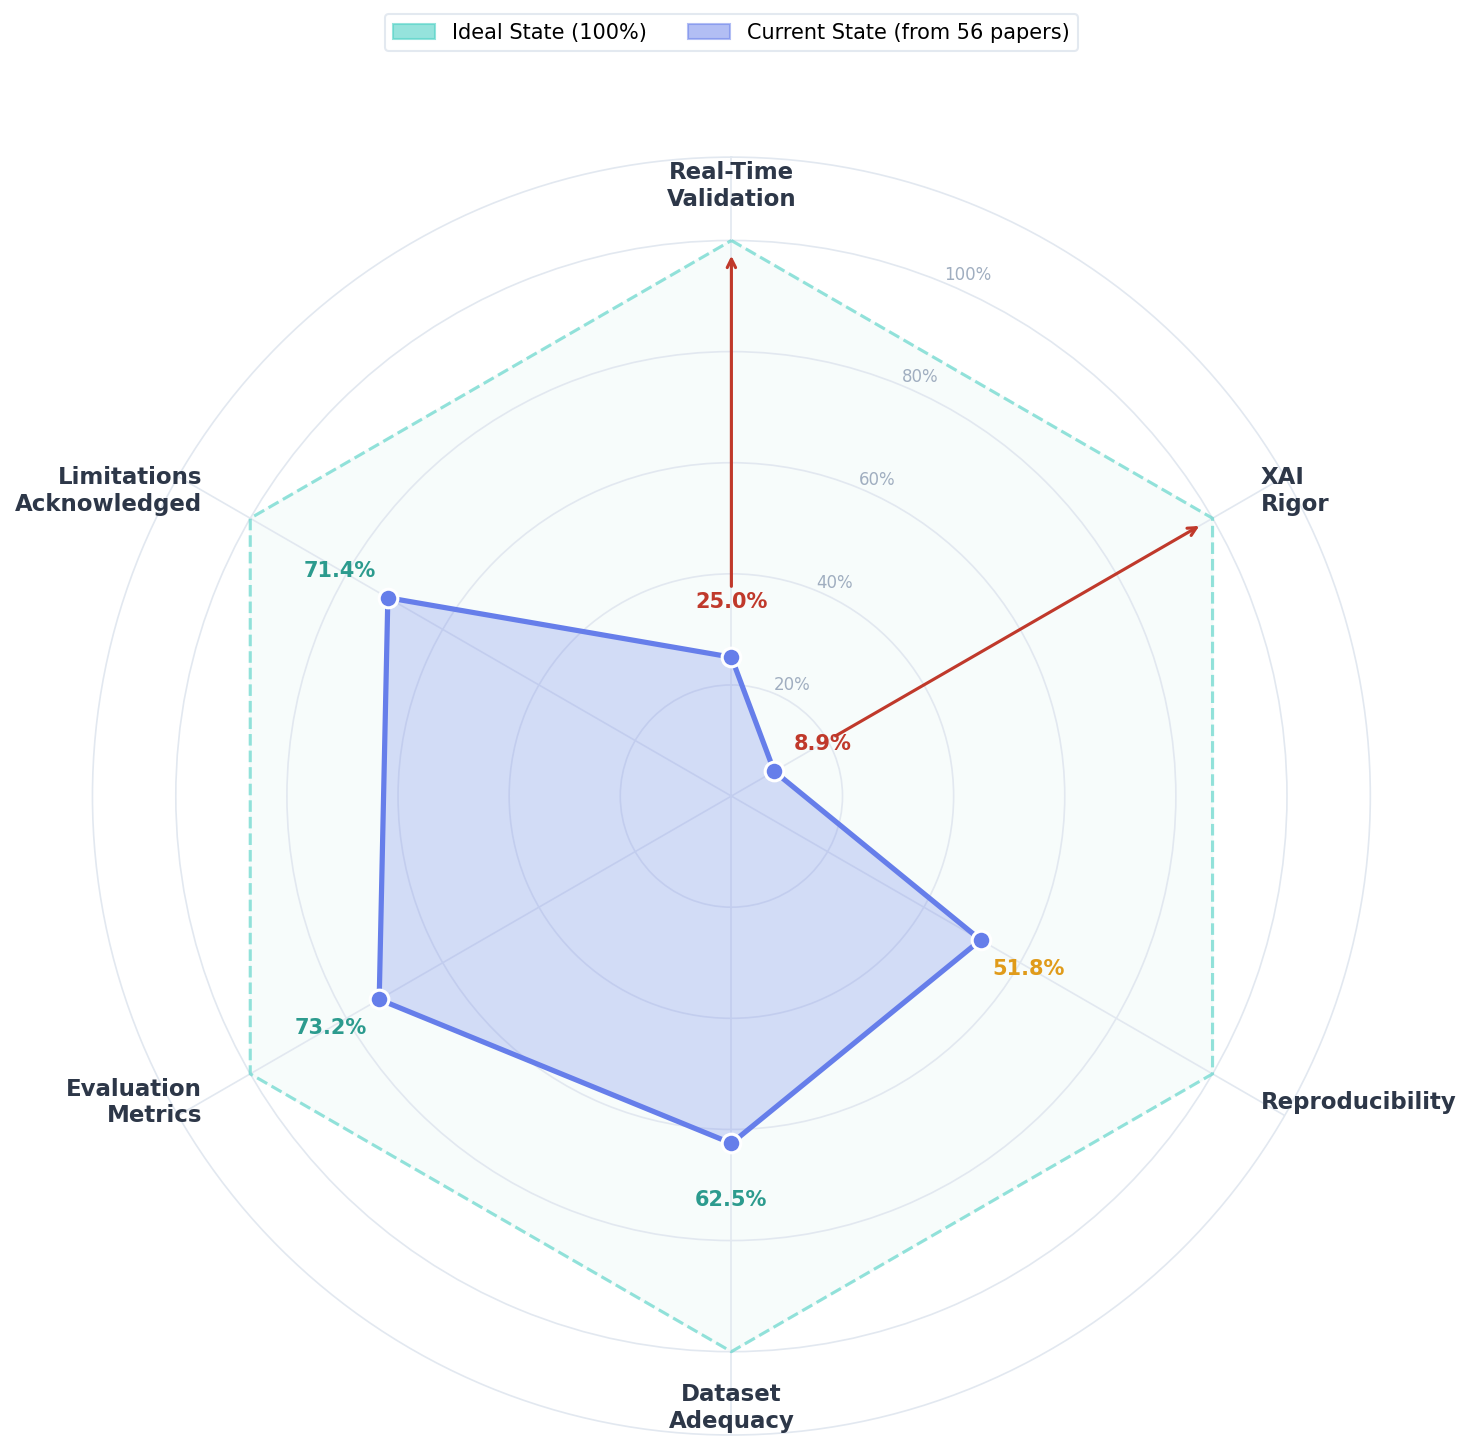

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F8B_Radar_Chart.png


In [40]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Verified values from your cleaned data ─────────────────────────────
categories = [
    'Real-Time\nValidation',
    'XAI\nRigor',
    'Reproducibility',
    'Dataset\nAdequacy',
    'Evaluation\nMetrics',
    'Limitations\nAcknowledged',
]

current_vals = [25.0, 8.9, 51.8, 62.5, 73.2, 71.4]
ideal_vals   = [100.0] * 6

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

current_vals_plot = current_vals + current_vals[:1]
ideal_vals_plot   = ideal_vals   + ideal_vals[:1]

# ── Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw=dict(polar=True),
                       facecolor='white')
ax.set_facecolor('white')

# ── Grid styling ───────────────────────────────────────────────────────
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Added a little extra space so outer labels do not overlap the figure
ax.set_ylim(0, 115)

ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'],
                   fontsize=8, color='#A0AEC0')
ax.yaxis.set_tick_params(pad=6)
ax.grid(color='#E2E8F0', linewidth=0.8, linestyle='-')
ax.spines['polar'].set_color('#E2E8F0')

# ── Ideal polygon ──────────────────────────────────────────────────────
ax.fill(angles, ideal_vals_plot,
        color='#EBF8F5', alpha=0.4, zorder=1)
ax.plot(angles, ideal_vals_plot,
        color='#4FD1C5', linewidth=1.5,
        linestyle='--', alpha=0.6, zorder=2)

# ── Current polygon ────────────────────────────────────────────────────
ax.fill(angles, current_vals_plot,
        color='#667EEA', alpha=0.25, zorder=3)
ax.plot(angles, current_vals_plot,
        color='#667EEA', linewidth=2.5,
        linestyle='-', zorder=4)

# ── Data point markers ─────────────────────────────────────────────────
ax.scatter(angles[:-1], current_vals,
           s=80, color='#667EEA',
           zorder=5, edgecolors='white', linewidth=1.5)

# ── Value labels on current polygon ───────────────────────────────────
offset = 8
for angle, val, cat in zip(angles[:-1], current_vals, categories):
    # Determine color by severity
    if val < 30:
        c = '#C0392B'
    elif val < 60:
        c = '#E09B1A'
    else:
        c = '#2C9B8E'

    ax.annotate(f'{val}%',
                xy=(angle, val),
                xytext=(angle, val + 10),
                fontsize=10, fontweight='bold',
                color=c, ha='center', va='center',
                zorder=6)

# ── Category labels ────────────────────────────────────────────────────
# Remove default labels and place custom labels farther out
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

label_radius = 110
for angle, label in zip(angles[:-1], categories):
    # Align labels based on side of the chart
    if 0 < angle < np.pi:
        ha = 'left'
    elif np.pi < angle < 2 * np.pi:
        ha = 'right'
    else:
        ha = 'center'

    ax.text(angle, label_radius, label,
            fontsize=11, fontweight='bold',
            color='#2D3748',
            ha=ha, va='center',
            clip_on=False)

# ── Gap annotation arrows ──────────────────────────────────────────────
# Annotate the two most critical gaps
for angle, cur, cat in zip(angles[:-1], current_vals, categories):
    gap = 100 - cur
    if gap >= 70:  # Critical gaps only
        ax.annotate('',
                    xy=(angle, 98),
                    xytext=(angle, cur + 12),
                    arrowprops=dict(
                        arrowstyle='->', color='#C0392B',
                        lw=1.5))

# ── Legend ─────────────────────────────────────────────────────────────
# Moved to the middle
ideal_patch   = mpatches.Patch(color='#4FD1C5', alpha=0.6,
                               label='Ideal State (100%)')
current_patch = mpatches.Patch(color='#667EEA', alpha=0.5,
                               label='Current State (from 56 papers)')
ax.legend(handles=[ideal_patch, current_patch],
          loc='upper center',
          bbox_to_anchor=(0.5, 1.12),
          ncol=2,
          fontsize=10,
          frameon=True, framealpha=0.95,
          edgecolor='#E2E8F0')

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F8B_Radar_Chart.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 20 — [FIG-F9A] Sankey: Real-Time Validation Gap


In [44]:
# [FIG-F9A] Sankey — Real-Time Validation Gap — FIXED
# Recreates Latency_clean inline before use

import plotly.graph_objects as go
import plotly.io as pio

# ── Fix: recreate Latency_clean ────────────────────────────────────────
def recode_latency(raw):
    if pd.isna(raw):
        return 'No'
    s = str(raw).lower().strip().split('\n')[0]
    if s.startswith('yes'):
        return 'Yes'
    return 'No'

df['Latency_clean'] = df['Inference Speed / Latency Reported?'].apply(recode_latency)

# ── Modality classification ────────────────────────────────────────────
def classify_modality(raw):
    if pd.isna(raw):
        return 'Audio / EEG / Text'
    s = str(raw).lower()
    if any(k in s for k in ['eeg', 'physiological', 'audio', 'speech',
                             'text', 'gaze', 'eye']):
        return 'Audio / EEG / Text'
    if any(k in s for k in ['multimodal', 'fusion']):
        return 'Multimodal'
    if 'video' in s:
        return 'Video'
    if any(k in s for k in ['image', 'static', 'photo']):
        return 'Static Image'
    return 'Audio / EEG / Text'

df['Modality_clean'] = df['Modality/ies in Dataset'].apply(classify_modality)

print("Modality distribution:")
print(df['Modality_clean'].value_counts())
print("\nLatency among Claimed:")
print(df[df['RealTime_clean']=='Claimed']['Latency_clean'].value_counts())

# ── Node definitions ───────────────────────────────────────────────────
node_labels = [
    'Static Image',        # 0
    'Video',               # 1
    'Multimodal',          # 2
    'Audio / EEG / Text',  # 3
    'CNN/Hybrid',          # 4
    'RNN/LSTM',            # 5
    'Transformer',         # 6
    'Other/NA',            # 7
    'Claimed',             # 8
    'Not Claimed',         # 9
    'Not Evaluated',       # 10
    'Latency Reported',    # 11
    'No Latency Reported', # 12
    'N/A',                 # 13
]

node_colors = [
    '#718096', '#4A5568', '#2D3748', '#A0AEC0',  # Modality
    '#4FD1C5', '#E09B1A', '#5A6FE4', '#A0AEC0',  # Architecture
    '#F6AD55', '#68D391', '#CBD5E0',              # Real-Time
    '#68D391', '#FC8181', '#CBD5E0',              # Latency
]

# ── Build flows ────────────────────────────────────────────────────────
sources, targets, values, link_colors = [], [], [], []

arch_link_colors = {
    'CNN/Hybrid'  : 'rgba(79,209,197,0.4)',
    'RNN/LSTM'    : 'rgba(224,155,26,0.4)',
    'Transformer' : 'rgba(90,111,228,0.4)',
    'Other/NA'    : 'rgba(160,174,192,0.4)',
}

# Col 0 → Col 1: Modality → Architecture
flows = {}
for _, row in df.iterrows():
    mod  = row['Modality_clean']
    arch = row['Architecture_Family']
    s = node_labels.index(mod)  if mod  in node_labels else 3
    t = node_labels.index(arch) if arch in node_labels else 7
    flows[(s, t)] = flows.get((s, t), 0) + 1
for (s, t), v in flows.items():
    sources.append(s); targets.append(t); values.append(v)
    link_colors.append('rgba(160,174,192,0.3)')

# Col 1 → Col 2: Architecture → Real-Time Status
flows = {}
for _, row in df.iterrows():
    arch = row['Architecture_Family']
    rt   = row['RealTime_clean']
    s = node_labels.index(arch) if arch in node_labels else 7
    t = node_labels.index(rt)   if rt   in node_labels else 10
    flows[(s, t)] = flows.get((s, t), 0) + 1
for (s, t), v in flows.items():
    sources.append(s); targets.append(t); values.append(v)
    arch_name = node_labels[s]
    link_colors.append(arch_link_colors.get(arch_name, 'rgba(160,174,192,0.35)'))

# Col 2 → Col 3: Real-Time Status → Latency Evidence
flows = {}
for _, row in df.iterrows():
    rt  = row['RealTime_clean']
    lat = row['Latency_clean']
    s   = node_labels.index(rt) if rt in node_labels else 10
    if rt == 'Claimed':
        t = 11 if lat == 'Yes' else 12
    else:
        t = 13
    flows[(s, t)] = flows.get((s, t), 0) + 1
for (s, t), v in flows.items():
    sources.append(s); targets.append(t); values.append(v)
    if t == 11:
        link_colors.append('rgba(104,211,145,0.55)')
    elif t == 12:
        link_colors.append('rgba(252,129,129,0.55)')
    else:
        link_colors.append('rgba(160,174,192,0.3)')

# ── Node positions ─────────────────────────────────────────────────────
node_x = [
    0.01, 0.01, 0.01, 0.01,
    0.33, 0.33, 0.33, 0.33,
    0.66, 0.66, 0.66,
    0.99, 0.99, 0.99,
]
node_y = [
    0.12, 0.32, 0.57, 0.82,
    0.10, 0.35, 0.58, 0.80,
    0.20, 0.55, 0.82,
    0.15, 0.52, 0.85,
]

# ── Figure ─────────────────────────────────────────────────────────────
fig_s = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad       = 20,
        thickness = 22,
        line      = dict(color='white', width=0.5),
        label     = node_labels,
        color     = node_colors,
        x         = node_x,
        y         = node_y,
    ),
    link=dict(
        source = sources,
        target = targets,
        value  = values,
        color  = link_colors,
    )
))

fig_s.update_layout(
    margin = dict(l=20, r=120, t=70, b=20),  # increase right margin
    width  = 1500,
    height = 700,
)

# Rewrite annotations with adjusted x for last column
fig_s.update_annotations([])  # clear existing

for x_pos, label, anchor in [
    (0.01,  'Modality',         'left'),
    (0.32,  'Architecture',     'center'),
    (0.64,  'Real-Time Claim',  'center'),
    (0.97,  'Latency Evidence', 'right'),
]:
    fig_s.add_annotation(
        x=x_pos, y=1.07,
        xref='paper', yref='paper',
        text=f'<b>{label}</b>',
        showarrow=False,
        font=dict(size=13, color='#2D3748'),
        xanchor=anchor,
    )

out_path = os.path.join(FIGURES_PATH, 'F9A_RealTime_Sankey.png')
pio.write_image(fig_s, out_path, width=1500, height=700, scale=4)
fig_s.show()
print(f"✅ Saved → {out_path}")

Modality distribution:
Modality_clean
Video                 22
Static Image          19
Audio / EEG / Text    14
Multimodal             1
Name: count, dtype: int64

Latency among Claimed:
Latency_clean
No     30
Yes    10
Name: count, dtype: int64


python(7292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F9A_RealTime_Sankey.png


## CELL 21 — [FIG-F9B] Sankey: QA Methodology → XAI Evaluation Adequacy


In [46]:
print("Methodology clean distribution:")
print(df['Appropriate Methodology_clean'].value_counts())

print("\nXAI Implemented distribution:")
print(df['XAI_impl'].value_counts())

print("\nXAI Adequacy distribution:")
print(df['XAI_adequacy'].value_counts())

print("\nCross-tab: Methodology × XAI Implemented:")
print(pd.crosstab(df['Appropriate Methodology_clean'], df['XAI_impl']))

print("\nCross-tab: XAI Implemented × XAI Adequacy:")
print(pd.crosstab(df['XAI_impl'], df['XAI_adequacy']))

print("\nCross-tab: Methodology × XAI Adequacy:")
print(pd.crosstab(df['Appropriate Methodology_clean'], df['XAI_adequacy']))

Methodology clean distribution:
Appropriate Methodology_clean
Yes        50
Partial     5
No          1
Name: count, dtype: int64

XAI Implemented distribution:
XAI_impl
Not Implemented    40
XAI Implemented    16
Name: count, dtype: int64

XAI Adequacy distribution:
XAI_adequacy
Not Evaluated    48
Partial           6
Adequate          2
Name: count, dtype: int64

Cross-tab: Methodology × XAI Implemented:
XAI_impl                       Not Implemented  XAI Implemented
Appropriate Methodology_clean                                  
No                                           1                0
Partial                                      5                0
Yes                                         34               16

Cross-tab: XAI Implemented × XAI Adequacy:
XAI_adequacy     Adequate  Not Evaluated  Partial
XAI_impl                                         
Not Implemented         0             40        0
XAI Implemented         2              8        6

Cross-tab: Methodology × 

In [48]:
# [FIG-F9B] Sankey — FIXED node positions, no overlap, no clipping

import plotly.graph_objects as go
import plotly.io as pio

node_labels = [
    'Methodology: Yes (n=50)',      # 0
    'Methodology: Partial (n=5)',   # 1
    'Methodology: No (n=1)',        # 2
    'XAI Implemented (n=16)',       # 3
    'XAI Not Implemented (n=40)',   # 4
    'Adequate (n=2)',               # 5
    'Partial Evaluation (n=6)',     # 6
    'Not Evaluated (n=48)',         # 7
]

node_colors = [
    '#68D391', '#F6AD55', '#FC8181',
    '#4FD1C5', '#A0AEC0',
    '#68D391', '#F6AD55', '#FC8181',
]

sources     = [0, 0, 1, 2,   3, 3, 3, 4]
targets     = [3, 4, 4, 4,   5, 6, 7, 7]
values      = [16, 34, 5, 1, 2, 6, 8, 40]
link_colors = [
    'rgba(104,211,145,0.45)',
    'rgba(104,211,145,0.20)',
    'rgba(246,173,85,0.35)',
    'rgba(252,129,129,0.35)',
    'rgba(104,211,145,0.6)',
    'rgba(246,173,85,0.5)',
    'rgba(252,129,129,0.4)',
    'rgba(252,129,129,0.45)',
]

# ── Fixed node positions — spread right column vertically ──────────────
node_x = [
    0.01, 0.01, 0.01,
    0.45, 0.45,
    0.95, 0.95, 0.95,
]
node_y = [
    0.10,   # Methodology Yes — top
    0.80,   # Methodology Partial
    0.92,   # Methodology No
    0.08,   # XAI Implemented
    0.62,   # XAI Not Implemented
    0.04,   # Adequate — very top, small node
    0.22,   # Partial Evaluation — below Adequate with gap
    0.62,   # Not Evaluated — large, bottom half
]

fig_xai = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad       = 40,        # more padding separates right-col nodes
        thickness = 24,
        line      = dict(color='white', width=0.5),
        label     = node_labels,
        color     = node_colors,
        x         = node_x,
        y         = node_y,
    ),
    link=dict(
        source = sources,
        target = targets,
        value  = values,
        color  = link_colors,
    )
))

fig_xai.update_layout(
    font         = dict(family='DejaVu Sans', size=13, color='#2D3748'),
    paper_bgcolor= 'white',
    plot_bgcolor = 'white',
    margin       = dict(l=20, r=200, t=70, b=50),  # large right margin
    width        = 1500,
    height       = 720,
)

for x_pos, label, anchor in [
    (0.01, 'Methodology Quality',     'left'),
    (0.45, 'XAI Implementation',      'center'),
    (0.95, 'XAI Evaluation Adequacy', 'center'),
]:
    fig_xai.add_annotation(
        x=x_pos, y=1.07,
        xref='paper', yref='paper',
        text=f'<b>{label}</b>',
        showarrow=False,
        font=dict(size=13, color='#2D3748'),
        xanchor=anchor,
    )

fig_xai.add_annotation(
    x=0.94, y=-0.06,
    xref='paper', yref='paper',
    text='<i>42/50 papers with sound methodology score Not Evaluated on XAI — structural deficit</i>',
    showarrow=False,
    font=dict(size=11, color='#C0392B'),
    xanchor='right',
    align='right',
)

out_path = os.path.join(FIGURES_PATH, 'F9B_XAI_Sankey.png')
pio.write_image(fig_xai, out_path, width=1500, height=720, scale=4)
fig_xai.show()
print(f"✅ Saved → {out_path}")

python(7711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F9B_XAI_Sankey.png


## CELL 22A — [AUDIT] Fairness & Bias Columns

In [49]:
# [AUDIT] Fairness and bias columns before F+1

cols = [
    'Demographic Bias Assessed?',
    'Cross-Cultural Validity Discussed?',
    'Fairness Metrics Reported?',
    'Bias Mitigation Methods',
]

for col in cols:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(df[col].value_counts(dropna=False).head(10))


=== Demographic Bias Assessed? ===
Demographic Bias Assessed?
No           46
No.           8
Partial       1
Partially     1
Name: count, dtype: int64

=== Cross-Cultural Validity Discussed? ===
Cross-Cultural Validity Discussed?
No                                                                                                                                                                                                42
No.                                                                                                                                                                                                5
Not reported.                                                                                                                                                                                      2
No (Though notes speech relies heavily on culture/language as a general challenge)                                                                                               

## CELL 22 — [FIG-F+1] Fairness & Bias Assessment Landscape

Yes:     [0, 2, 0, 0]
Partial: [2, 3, 1, 0]
No:      [54, 51, 55, 56]


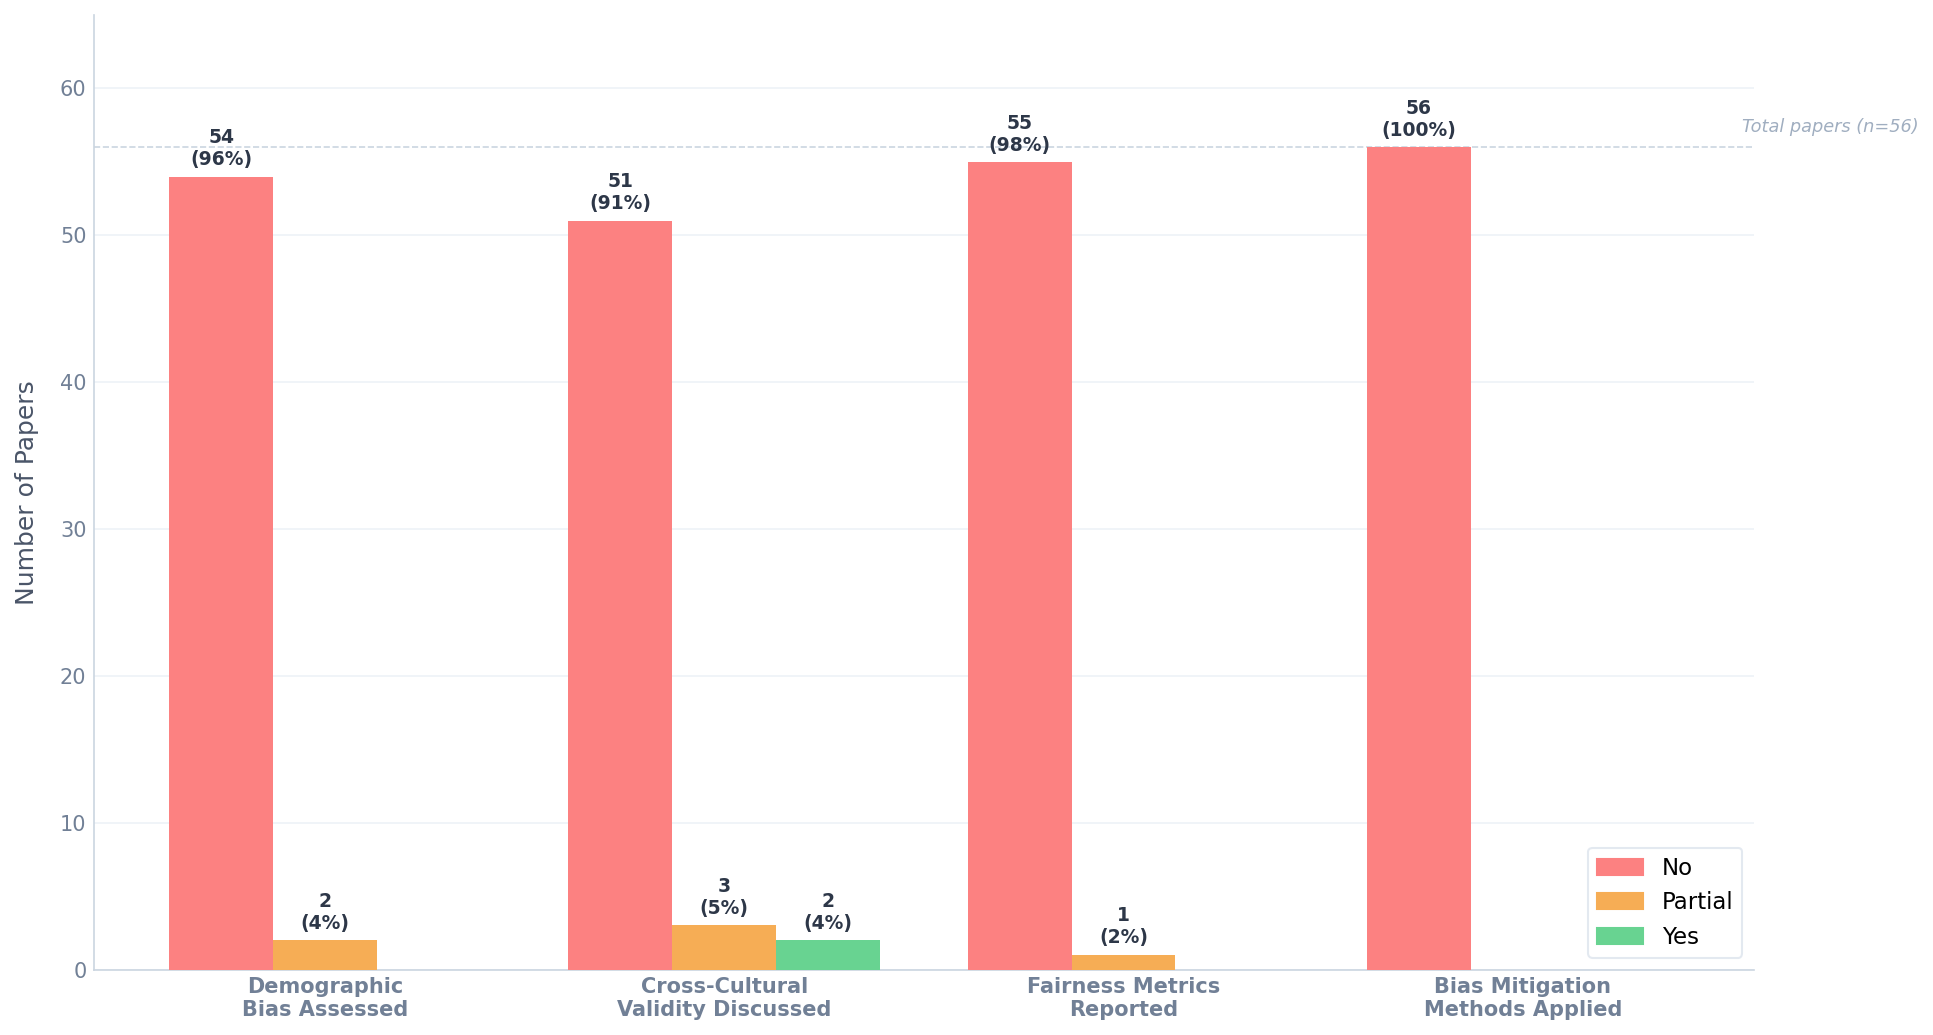

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/Fp1_Fairness_Bias.png


In [53]:
# [FIG-F+1] Fairness & Bias Assessment Grouped Bar Chart

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Clean each column into Yes / Partial / No ──────────────────────────
def clean_bias_col(raw):
    if pd.isna(raw):
        return 'No'
    s = str(raw).lower().strip()
    if s.startswith('yes'):
        return 'Yes'
    if any(k in s for k in ['partial', 'partially', 'limited']):
        return 'Partial'
    return 'No'

df['BiasAssessed_clean']      = df['Demographic Bias Assessed?'].apply(clean_bias_col)
df['CrossCultural_clean']     = df['Cross-Cultural Validity Discussed?'].apply(clean_bias_col)
df['FairnessMetrics_clean']   = df['Fairness Metrics Reported?'].apply(clean_bias_col)
df['BiasMitigation_clean']    = df['Bias Mitigation Methods'].apply(clean_bias_col)

# ── Count per dimension ────────────────────────────────────────────────
dimensions = [
    'Demographic\nBias Assessed',
    'Cross-Cultural\nValidity Discussed',
    'Fairness Metrics\nReported',
    'Bias Mitigation\nMethods Applied',
]
cols_clean = [
    'BiasAssessed_clean',
    'CrossCultural_clean',
    'FairnessMetrics_clean',
    'BiasMitigation_clean',
]

yes_counts     = [df[c].eq('Yes').sum()     for c in cols_clean]
partial_counts = [df[c].eq('Partial').sum() for c in cols_clean]
no_counts      = [df[c].eq('No').sum()      for c in cols_clean]

print("Yes:    ", yes_counts)
print("Partial:", partial_counts)
print("No:     ", no_counts)

n      = len(df)
total  = n  # 56

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_facecolor('white')

x       = np.arange(len(dimensions))
bar_w   = 0.26

bars_no      = ax.bar(x - bar_w, no_counts,      bar_w,
                      color='#FC8181', label='No',      zorder=3)
bars_partial = ax.bar(x,          partial_counts, bar_w,
                      color='#F6AD55', label='Partial', zorder=3)
bars_yes     = ax.bar(x + bar_w, yes_counts,     bar_w,
                      color='#68D391', label='Yes',     zorder=3)

# ── Value + percentage labels on bars ─────────────────────────────────
def label_bars(bars, counts):
    for bar, val in zip(bars, counts):
        if val == 0:
            continue
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val}\n({pct:.0f}%)',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='#2D3748')

label_bars(bars_no,      no_counts)
label_bars(bars_partial, partial_counts)
label_bars(bars_yes,     yes_counts)

# ── Reference line at n=56 ────────────────────────────────────────────
ax.axhline(56, color='#CBD5E0', linewidth=0.8,
           linestyle='--', zorder=1)
ax.text(len(dimensions) - 0.45, 57,
        'Total papers (n=56)',
        fontsize=8.5, color='#A0AEC0', style='italic')

# ── Axes ───────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(dimensions, fontsize=12,
                   color='#2D3748', fontweight='bold')
ax.set_ylabel('Number of Papers', fontsize=12,
              color='#4A5568', labelpad=10)
ax.set_ylim(0, 65)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.tick_params(axis='both', colors='#718096',
               labelsize=10, length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E0')
ax.spines['bottom'].set_color('#CBD5E0')
ax.grid(axis='y', color='#EDF2F7',
        linewidth=0.8, zorder=0)

# ── Key finding annotation ─────────────────────────────────────────────

# ── Legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color='#FC8181', label='No'),
    mpatches.Patch(color='#F6AD55', label='Partial'),
    mpatches.Patch(color='#68D391', label='Yes'),
]
ax.legend(handles=legend_patches,
          loc='lower right',
          fontsize=11,
          frameon=True, framealpha=0.95,
          edgecolor='#E2E8F0')

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'Fp1_Fairness_Bias.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 23A — [AUDIT] Compute Total QA Score per Paper

In [54]:
# [AUDIT] Compute total QA score per paper before F+4

score_map = {'Yes': 2, 'Partial': 1, 'No': 0, 'Not Reported': 0}

qa_dims = [
    'Clear Research Objective',
    'Appropriate Methodology',
    'Reproducibility',
    'Dataset Adequately Described',
    'Appropriate Evaluation Metrics',
    'Comparison to Baselines / SOTA',
    'XAI Sufficiently Evaluated',
    'Limitations Explicitly Acknowledged',
]

for dim in qa_dims:
    clean_col = dim + '_clean'
    df[dim + '_score'] = df[clean_col].map(score_map).fillna(0)

df['Total_QA_Score'] = df[[d + '_score' for d in qa_dims]].sum(axis=1)

print("Total QA Score distribution:")
print(df['Total_QA_Score'].value_counts().sort_index())
print(f"\nMin: {df['Total_QA_Score'].min()}")
print(f"Max: {df['Total_QA_Score'].max()}")
print(f"Mean: {df['Total_QA_Score'].mean():.2f}")
print()
print("Score by year:")
print(df.groupby('Year')['Total_QA_Score'].mean().round(2))
print()
print("Score by architecture:")
print(df.groupby('Architecture_Family')['Total_QA_Score'].mean().round(2))

Total QA Score distribution:
Total_QA_Score
2      1
4      1
6      2
8      1
9      4
10    13
11    18
12     6
13     5
14     5
Name: count, dtype: int64

Min: 2
Max: 14
Mean: 10.66

Score by year:
Year
2018    13.00
2020    10.67
2021    12.40
2022    10.71
2023    10.20
2024     9.43
2025    11.18
2026    11.60
Name: Total_QA_Score, dtype: float64

Score by architecture:
Architecture_Family
CNN/Hybrid     10.44
Other/NA       12.50
RNN/LSTM       12.00
Transformer    11.67
Name: Total_QA_Score, dtype: float64


## CELL 23 — [FIG-F+4] Evidence Quality Bubble Chart

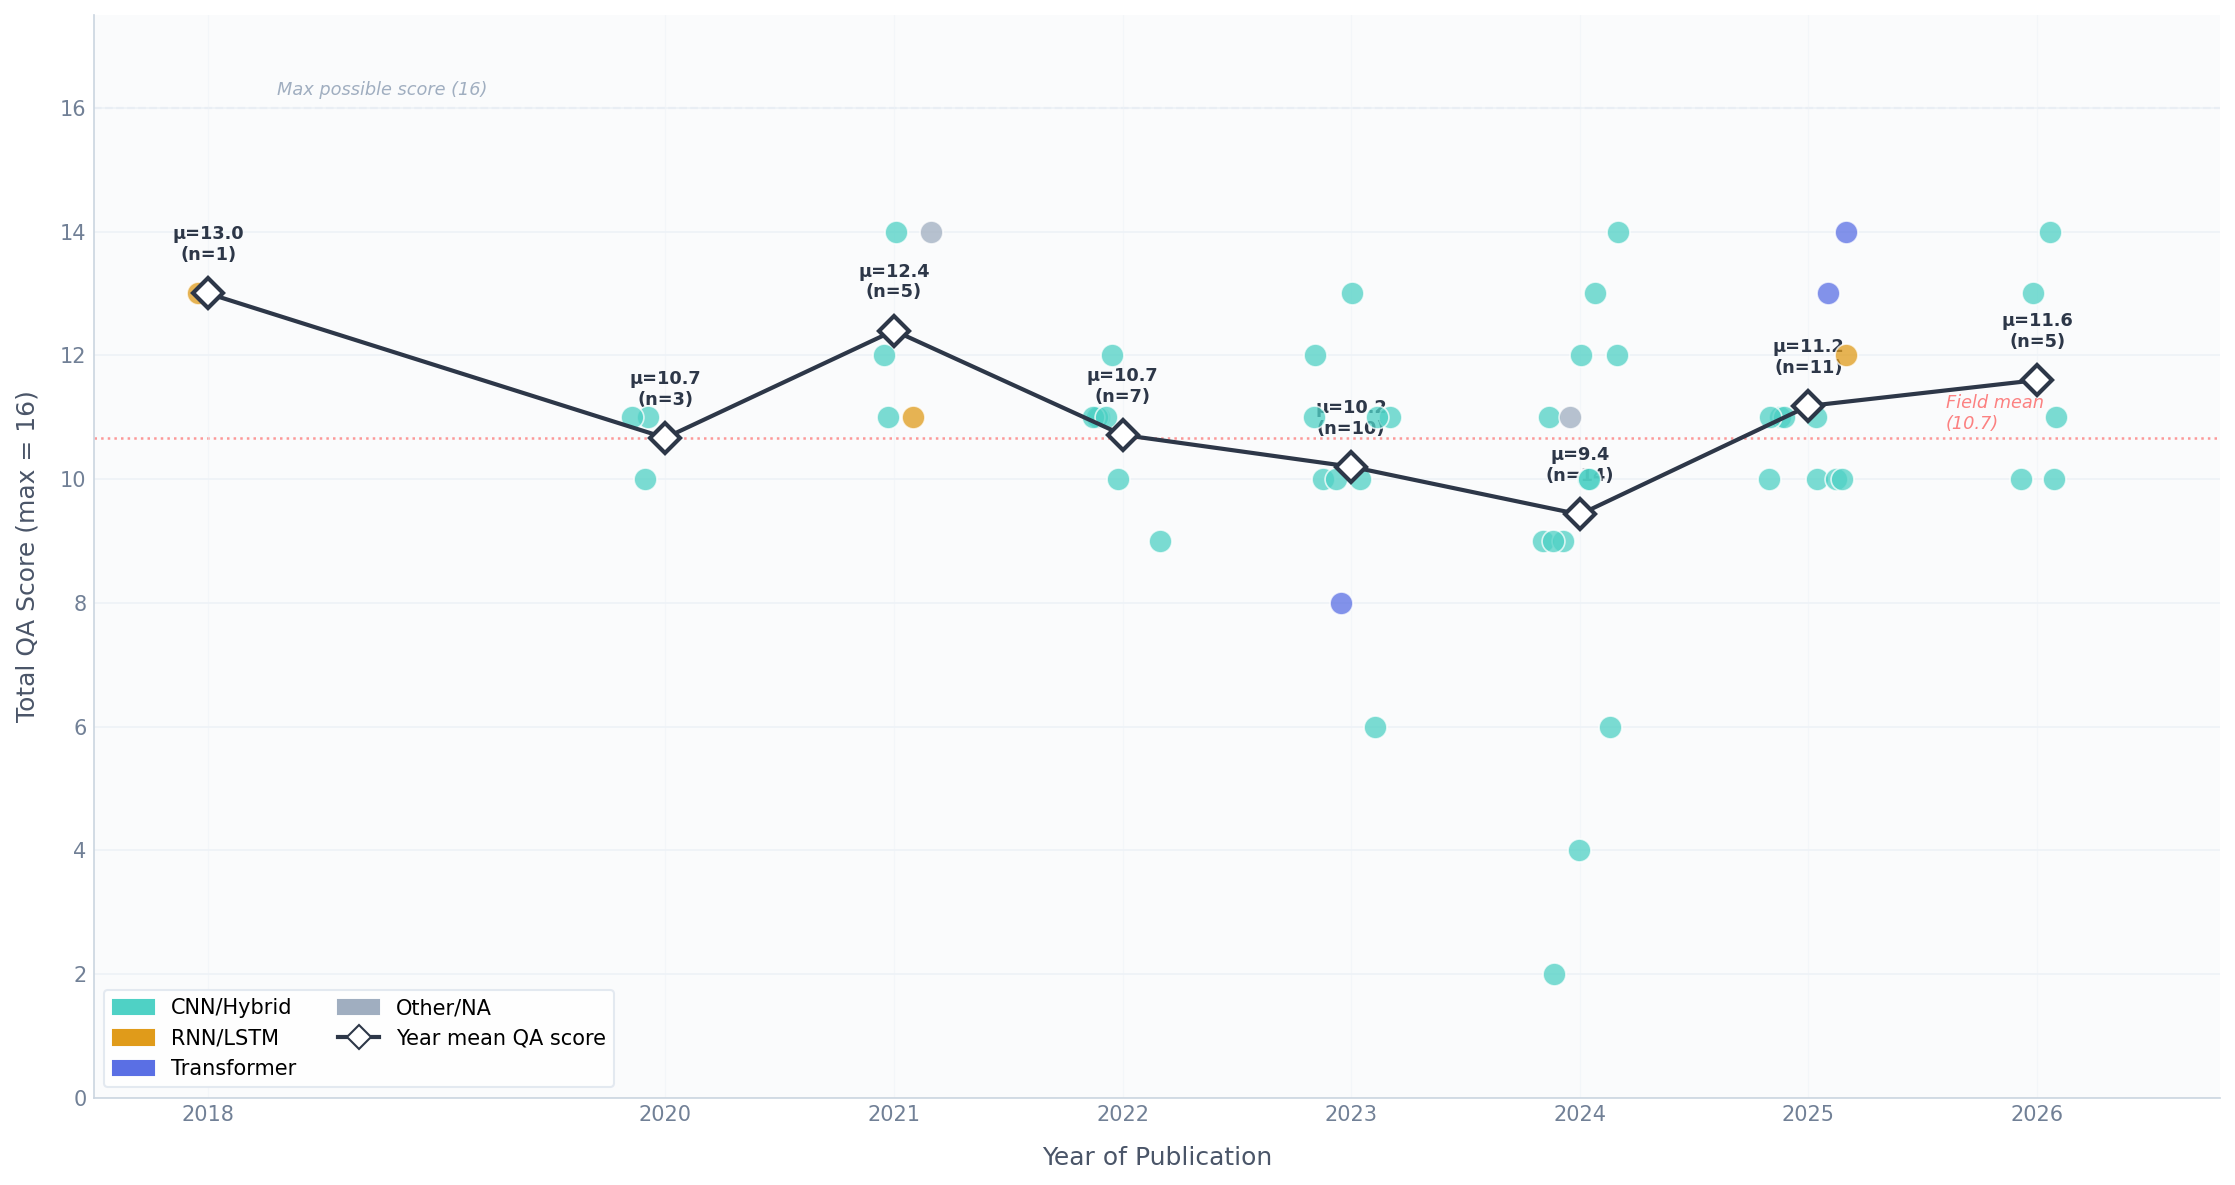

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/Fp4_Evidence_Quality_Bubble.png


In [56]:
# [FIG-F+4] Evidence Quality Bubble Chart
# X = Year, Y = Total QA Score, Bubble size = n papers that year
# Color = Architecture family dominant that year

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Per-paper data ─────────────────────────────────────────────────────
ARCH_COLORS = {
    'CNN/Hybrid'  : '#4FD1C5',
    'RNN/LSTM'    : '#E09B1A',
    'Transformer' : '#5A6FE4',
    'Other/NA'    : '#A0AEC0',
}

# ── Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 8), facecolor='white')
ax.set_facecolor('#FAFBFC')

# ── Plot individual paper bubbles ──────────────────────────────────────
for arch in ['CNN/Hybrid', 'RNN/LSTM', 'Transformer', 'Other/NA']:
    mask   = df['Architecture_Family'] == arch
    subset = df[mask]
    # Add jitter on x to avoid overlap
    np.random.seed(42)
    jitter = np.random.uniform(-0.18, 0.18, size=mask.sum())
    ax.scatter(
        subset['Year'].astype(float) + jitter,
        subset['Total_QA_Score'],
        s        = 120,
        color    = ARCH_COLORS[arch],
        alpha    = 0.75,
        edgecolors = 'white',
        linewidth  = 0.8,
        label    = arch,
        zorder   = 4,
    )

# ── Year mean trend line ───────────────────────────────────────────────
year_means = df.groupby('Year')['Total_QA_Score'].mean()
year_counts = df.groupby('Year').size()
years_sorted = sorted(year_means.index)
means_sorted = [year_means[y] for y in years_sorted]

ax.plot(years_sorted, means_sorted,
        color='#2D3748', linewidth=2.0,
        linestyle='-', marker='D',
        markersize=10, markerfacecolor='white',
        markeredgecolor='#2D3748', markeredgewidth=2,
        zorder=5, label='Year mean QA score')

# Mean value labels
for y, m, n in zip(years_sorted, means_sorted, [year_counts[yr] for yr in years_sorted]):
    ax.annotate(
        f'μ={m:.1f}\n(n={n})',
        xy=(y, m),
        xytext=(0, 14),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=8.5, color='#2D3748',
        fontweight='bold',
    )

# ── Max score reference line ───────────────────────────────────────────
ax.axhline(16, color='#CBD5E0', linewidth=1.0,
           linestyle='--', zorder=1, alpha=0.7)
ax.text(2018.3, 16.2, 'Max possible score (16)',
        fontsize=8.5, color='#A0AEC0', style='italic')

# ── Field mean reference line ──────────────────────────────────────────
field_mean = df['Total_QA_Score'].mean()
ax.axhline(field_mean, color='#FC8181', linewidth=1.2,
           linestyle=':', zorder=1, alpha=0.8)
ax.text(2025.6, field_mean + 0.15,
        f'Field mean\n({field_mean:.1f})',
        fontsize=8.5, color='#FC8181',
        style='italic', ha='left')

# ── 2024 peak volume annotation ────────────────────────────────────────

# ── Axes ───────────────────────────────────────────────────────────────
ax.set_xlim(2017.5, 2026.8)
ax.set_ylim(0, 17.5)
ax.set_xticks(years_sorted)
ax.set_xticklabels([str(y) for y in years_sorted],
                   fontsize=12, color='#2D3748')
ax.set_ylabel('Total QA Score (max = 16)',
              fontsize=12, color='#4A5568', labelpad=10)
ax.set_xlabel('Year of Publication',
              fontsize=12, color='#4A5568', labelpad=10)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.tick_params(axis='both', colors='#718096',
               labelsize=10, length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E0')
ax.spines['bottom'].set_color('#CBD5E0')
ax.grid(axis='y', color='#EDF2F7',
        linewidth=0.8, zorder=0)
ax.grid(axis='x', color='#EDF2F7',
        linewidth=0.5, zorder=0, alpha=0.5)

# ── Legend ─────────────────────────────────────────────────────────────
arch_patches = [
    mpatches.Patch(color=ARCH_COLORS[a], label=a)
    for a in ['CNN/Hybrid', 'RNN/LSTM', 'Transformer', 'Other/NA']
]
mean_line = plt.Line2D([0], [0], color='#2D3748',
                        linewidth=2, marker='D',
                        markersize=8, markerfacecolor='white',
                        markeredgecolor='#2D3748',
                        label='Year mean QA score')
ax.legend(
    handles  = arch_patches + [mean_line],
    fontsize = 10,
    frameon  = True, framealpha=0.95,
    edgecolor= '#E2E8F0',
    loc      = 'lower left',
    ncol     = 2,
)

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'Fp4_Evidence_Quality_Bubble.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")

## CELL 24 — [FIG-F1] 5-Layer Conceptual Framework Hero

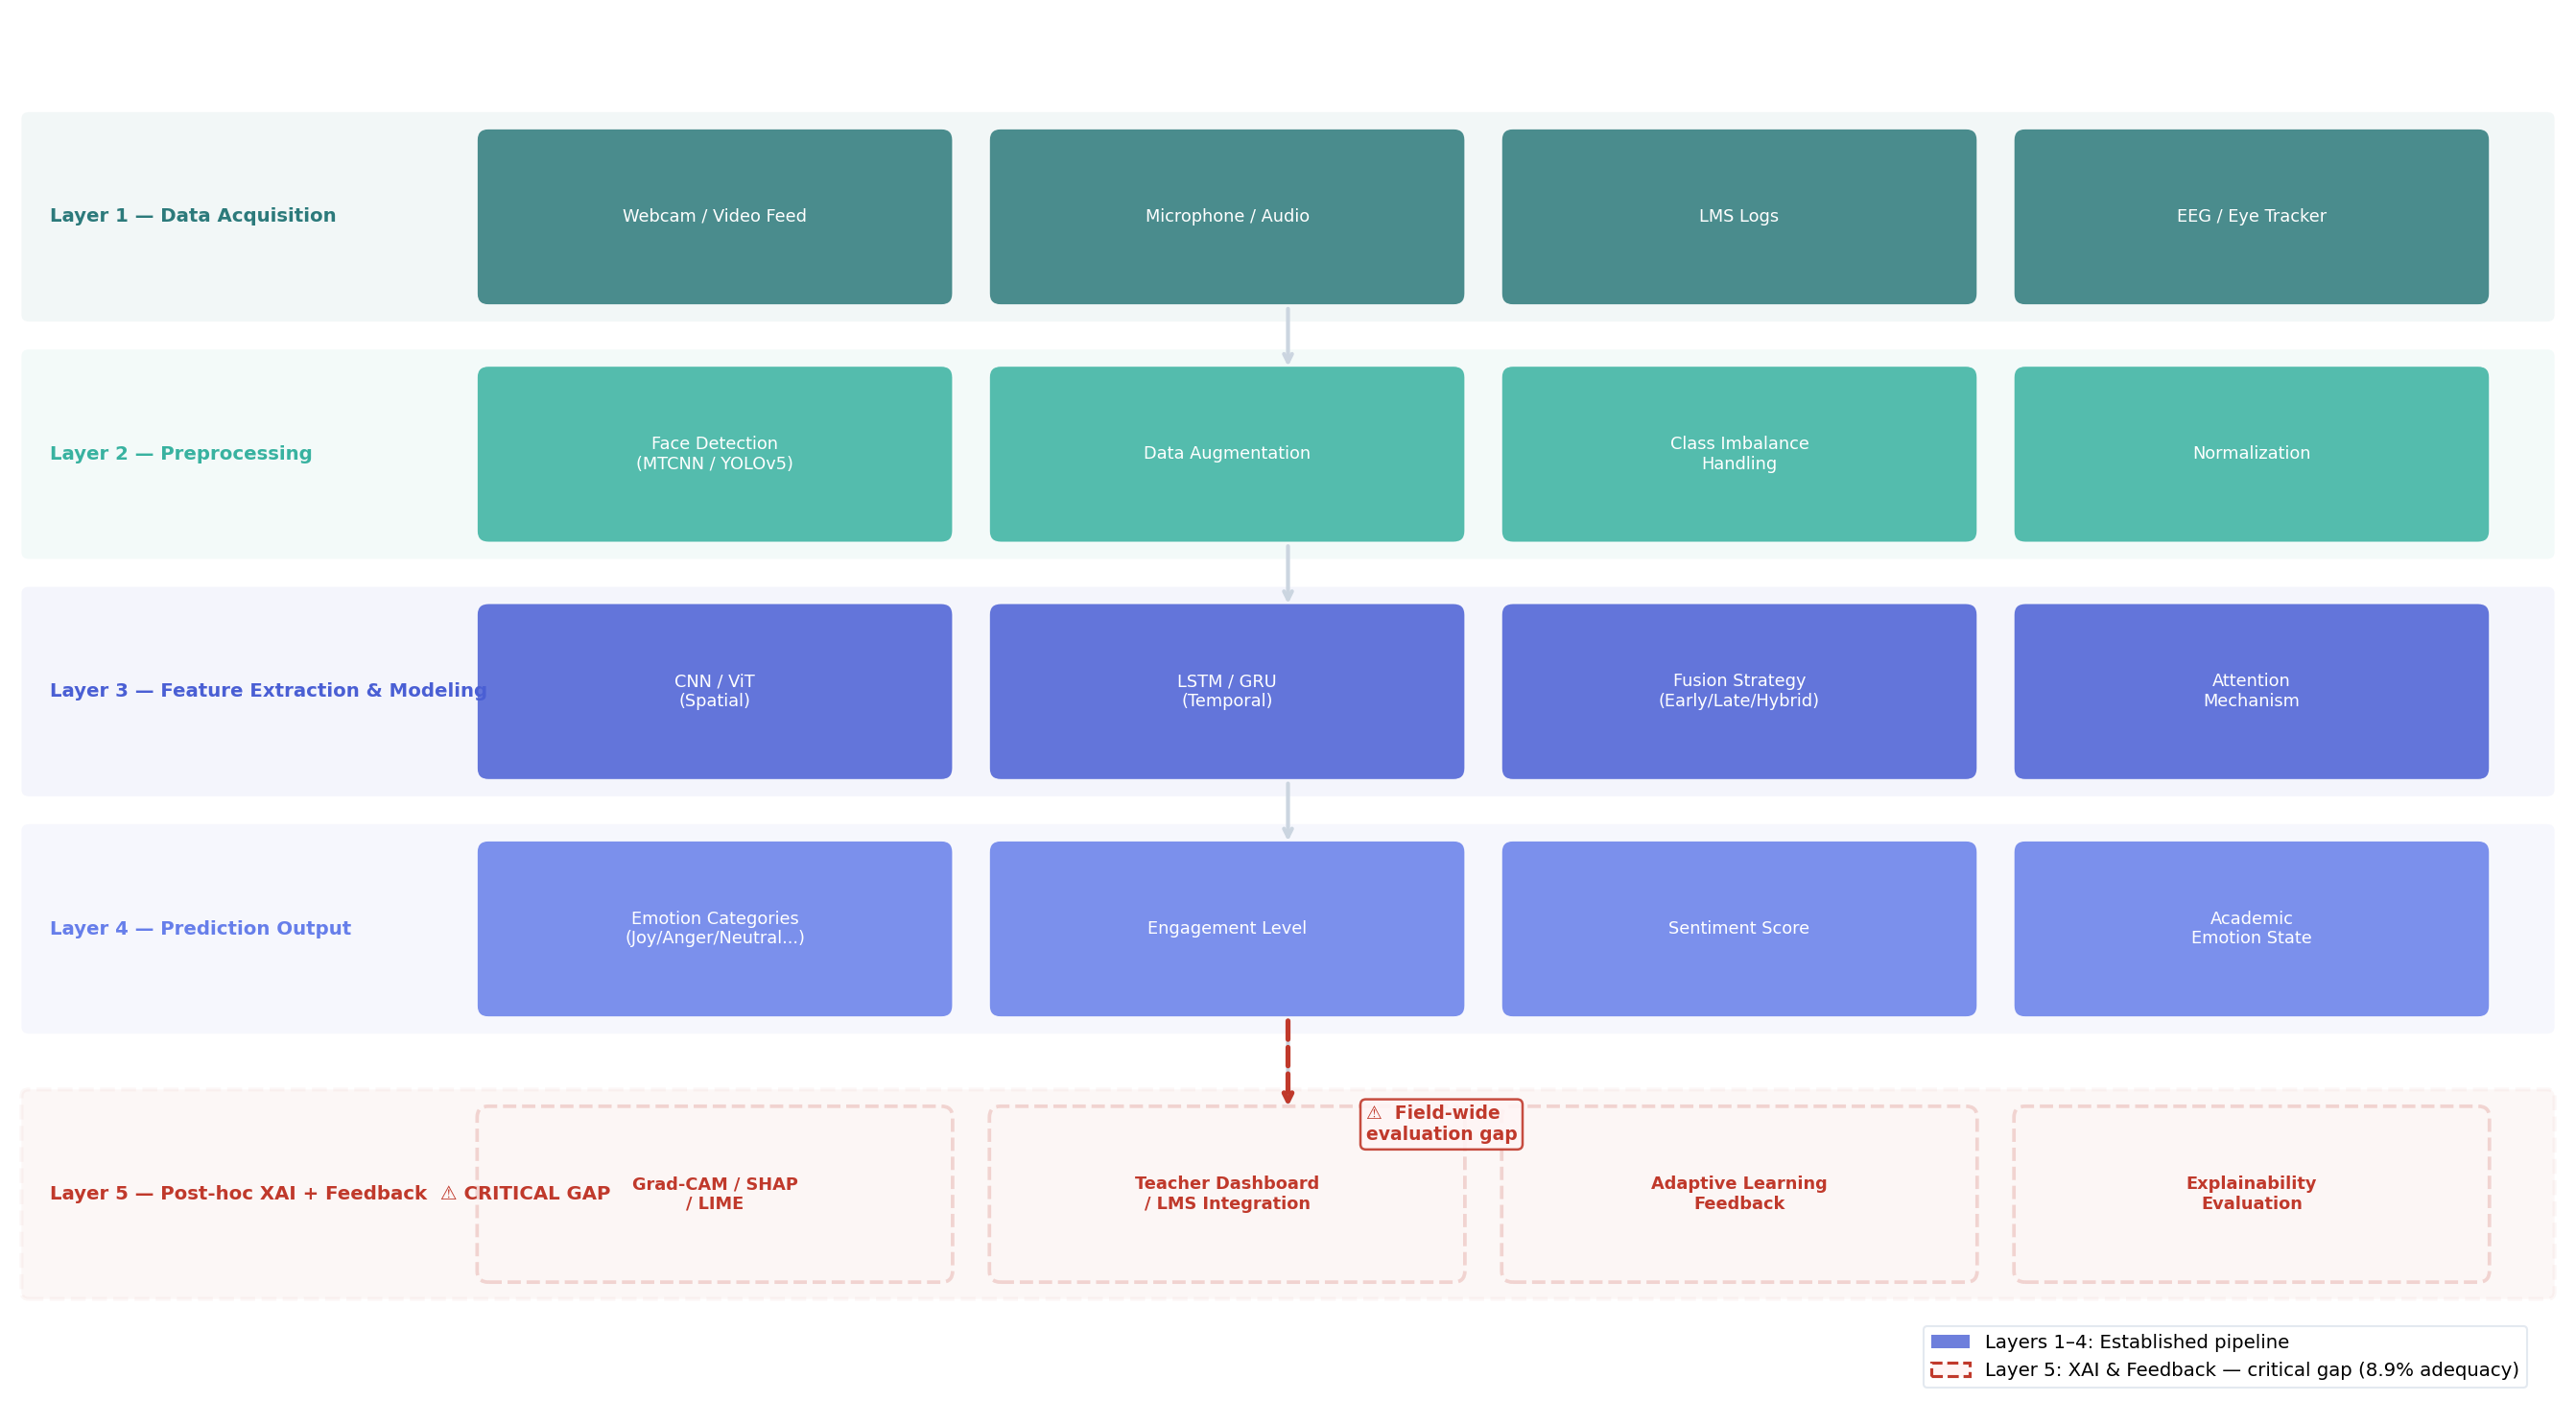

✅ Saved → /Volumes/Sarbajit/Personal/Amir Sohel Sir/code/figures_final/F1_Conceptual_Framework.png


In [57]:
# [FIG-F1] 5-Layer Conceptual Framework Hero
# Illustrative — no data, pure design
# Layer 5 visually distinct to signal XAI gap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(18, 10), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)

# ── Layer definitions ──────────────────────────────────────────────────
layers = [
    {
        'y'      : 8.0,
        'color'  : '#2C7A7B',
        'label'  : 'Layer 1 — Data Acquisition',
        'items'  : ['Webcam / Video Feed', 'Microphone / Audio', 'LMS Logs', 'EEG / Eye Tracker'],
        'dashed' : False,
        'gap'    : False,
    },
    {
        'y'      : 6.3,
        'color'  : '#38B2A0',
        'label'  : 'Layer 2 — Preprocessing',
        'items'  : ['Face Detection\n(MTCNN / YOLOv5)', 'Data Augmentation', 'Class Imbalance\nHandling', 'Normalization'],
        'dashed' : False,
        'gap'    : False,
    },
    {
        'y'      : 4.6,
        'color'  : '#4A5FD4',
        'label'  : 'Layer 3 — Feature Extraction & Modeling',
        'items'  : ['CNN / ViT\n(Spatial)', 'LSTM / GRU\n(Temporal)', 'Fusion Strategy\n(Early/Late/Hybrid)', 'Attention\nMechanism'],
        'dashed' : False,
        'gap'    : False,
    },
    {
        'y'      : 2.9,
        'color'  : '#667EEA',
        'label'  : 'Layer 4 — Prediction Output',
        'items'  : ['Emotion Categories\n(Joy/Anger/Neutral...)', 'Engagement Level', 'Sentiment Score', 'Academic\nEmotion State'],
        'dashed' : False,
        'gap'    : False,
    },
    {
        'y'      : 1.0,
        'color'  : '#C0392B',
        'label'  : 'Layer 5 — Post-hoc XAI + Feedback  ⚠ CRITICAL GAP',
        'items'  : ['Grad-CAM / SHAP\n/ LIME', 'Teacher Dashboard\n/ LMS Integration', 'Adaptive Learning\nFeedback', 'Explainability\nEvaluation'],
        'dashed' : True,
        'gap'    : True,
    },
]

BOX_H    = 1.10
BOX_W    = 3.20
X_START  = 0.55
X_GAP    = 0.42

# ── Draw each layer ────────────────────────────────────────────────────
for layer in layers:
    y        = layer['y']
    color    = layer['color']
    dashed   = layer['dashed']
    is_gap   = layer['gap']

    # Layer background band
    band_alpha = 0.06 if not is_gap else 0.04
    band = FancyBboxPatch((0.1, y - 0.15), 17.8, BOX_H + 0.3,
                           boxstyle='round,pad=0.05',
                           facecolor=color,
                           edgecolor=color if not dashed else '#C0392B',
                           linewidth=2.0 if dashed else 0,
                           linestyle='--' if dashed else '-',
                           alpha=band_alpha,
                           zorder=1)
    ax.add_patch(band)

    # Layer label on left
    ax.text(0.25, y + BOX_H / 2,
            layer['label'],
            ha='left', va='center',
            fontsize=9.5,
            fontweight='bold',
            color=color,
            rotation=0,
            zorder=4)

    # Item boxes
    for k, item in enumerate(layer['items']):
        x = X_START + 2.8 + k * (BOX_W + X_GAP)

        ls  = '--' if dashed else '-'
        lw  = 1.8  if dashed else 0.5
        ec  = '#C0392B' if dashed else 'white'
        fc  = '#FFF5F5' if dashed else color
        a   = 0.18 if dashed else 0.85

        box = FancyBboxPatch((x, y),
                              BOX_W, BOX_H,
                              boxstyle='round,pad=0.08',
                              facecolor=fc,
                              edgecolor=ec,
                              linewidth=lw,
                              linestyle=ls,
                              alpha=a,
                              zorder=3)
        ax.add_patch(box)

        txt_color = '#C0392B' if dashed else 'white'
        ax.text(x + BOX_W / 2, y + BOX_H / 2,
                item,
                ha='center', va='center',
                fontsize=8.5,
                color=txt_color,
                fontweight='bold' if dashed else 'normal',
                zorder=5,
                multialignment='center')

# ── Vertical arrows between layers ────────────────────────────────────
arrow_x = 9.0
for i in range(len(layers) - 1):
    y_top = layers[i]['y']
    y_bot = layers[i+1]['y'] + BOX_H
    # Normal arrow
    ax.annotate('',
                xy=(arrow_x, y_bot + 0.05),
                xytext=(arrow_x, y_top - 0.08),
                arrowprops=dict(
                    arrowstyle='->', color='#CBD5E0',
                    lw=2.0))

# ── Gap indicator arrow before Layer 5 ────────────────────────────────
ax.annotate('',
            xy=(arrow_x, layers[4]['y'] + BOX_H + 0.05),
            xytext=(arrow_x, layers[3]['y'] - 0.08),
            arrowprops=dict(
                arrowstyle='->', color='#C0392B',
                lw=2.5,
                linestyle='dashed'))

# ── Gap label ─────────────────────────────────────────────────────────
ax.text(9.55, 2.05,
        '⚠  Field-wide\nevaluation gap',
        ha='left', va='center',
        fontsize=9, color='#C0392B',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#FFF5F5',
                  edgecolor='#C0392B',
                  linewidth=1.2,
                  alpha=0.9))

# ── Legend ─────────────────────────────────────────────────────────────
solid_patch = mpatches.Patch(facecolor='#4A5FD4', alpha=0.8,
                              label='Layers 1–4: Established pipeline')
gap_patch   = mpatches.Patch(facecolor='#FFF5F5',
                              edgecolor='#C0392B',
                              linewidth=1.5,
                              linestyle='--',
                              label='Layer 5: XAI & Feedback — critical gap (8.9% adequacy)')
ax.legend(handles=[solid_patch, gap_patch],
          loc='lower right',
          bbox_to_anchor=(0.99, 0.01),
          fontsize=9.5,
          frameon=True, framealpha=0.95,
          edgecolor='#E2E8F0')

plt.tight_layout()

out_path = os.path.join(FIGURES_PATH, 'F1_Conceptual_Framework.png')
fig.savefig(out_path, dpi=1200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"✅ Saved → {out_path}")